# CAE + Mahalobis distance in the 16D latent space.

Convolutional Autoencoder for finding deuterons and separating them from protons in the LArIAT data. 

Uses both planes: collection and induction. 

Found a numerical way to separate p/d.

With short protons in training data included.

In [195]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from pytorch_msssim import ms_ssim

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import zoom
from sklearn.model_selection import KFold

In [196]:
COL = '/Volumes/easystore/proton-deuteron/col&ind/col.pkl'                               # collection plane protons and deuterons
IND = '/Volumes/easystore/proton-deuteron/col&ind/ind.pkl'                               # induction plane matching clusters

P_COL = '/Volumes/easystore/proton-deuteron/col&ind/pickyprotonscol.pkl'
P_IND = '/Volumes/easystore/proton-deuteron/col&ind/pickyprotonsind.pkl'

masses = pd.read_csv('/Volumes/easystore/proton-deuteron/csv/picky+match.csv')           # BEAMLINE INFO. e.g. mass, if no. of particles = 1

col = pd.read_pickle(COL) 
ind = pd.read_pickle(IND)

p_col = pd.read_pickle(P_COL)
p_ind = pd.read_pickle(P_IND)

col = col[col['particle_type'] == 'deuteron']
ind = ind[ind['particle_type'] == 'deuteron']

col = pd.concat([col, p_col], ignore_index=True)
ind = pd.concat([ind, p_ind], ignore_index=True)

col = pd.merge(
    col,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

ind = pd.merge(
    ind,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

print(ind.shape, col.shape)

(12915, 38) (12915, 38)


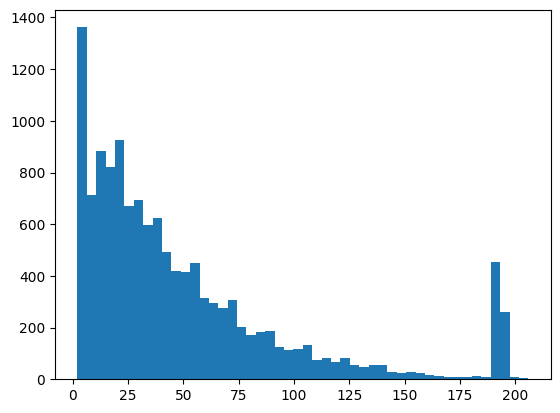

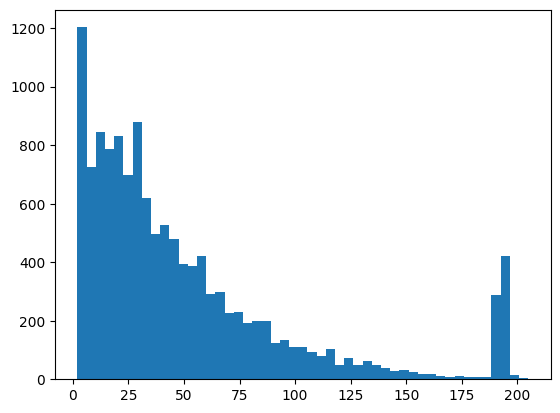

In [197]:
plt.hist(ind['height'], bins='auto'); plt.show()
plt.hist(col['height'], bins='auto'); plt.show()

In [198]:
maxes = col['column_maxes'].values                                                  # max ADC for each wire hit

normalised = []                               

for i, signal in enumerate(maxes):                                                  # normalise 0-1 per cluster using max
    
    minimum = 0
    maximum = np.max(signal)

    if maximum > minimum:
        normalised_signal = (signal - minimum) / (maximum - minimum)
    else:
        normalised_signal = np.zeros_like(signal, dtype=float)
        print(f'Error: Max not greater than min in signal {i}.')

    normalised.append(normalised_signal)

adcdiff = [np.diff(signal) for signal in normalised]                                # difference between consecutive hits
maxdiff = [np.max(diff) for diff in adcdiff]; col['maxdiff'] = maxdiff              # max ADC difference

In [199]:
maxes = ind['column_maxes'].values                                                  # for induction plane

normalised = []

for i, signal in enumerate(maxes):
    
    minimum = 0
    maximum = np.max(signal)

    if maximum > minimum:
        normalised_signal = (signal - minimum) / (maximum - minimum)
    else:
        normalised_signal = np.zeros_like(signal, dtype=float)
        print(f'Error: Max not greater than min in signal {i}.')

    normalised.append(normalised_signal)

adcdiff = [np.diff(signal) for signal in normalised]
maxdiff = [np.max(diff) for diff in adcdiff]; ind['maxdiff'] = maxdiff

In [200]:
removed_indices_col = col[~(col['maxdiff'] >= 0)].index
removed_indices_ind = ind[~(ind['maxdiff'] >= 0)].index

removed_indices = removed_indices_col.union(removed_indices_ind)

col = col[~col.index.isin(removed_indices)]; print(col.shape)
ind = ind[~ind.index.isin(removed_indices)]; print(ind.shape)

(12637, 39)
(12637, 39)


In [201]:
removed_indices_col = col[~((col['height'] < 25) & (col['width'] < 400))].index            # remove long and wide images
removed_indices_ind = ind[~((ind['height'] < 25) & (ind['width'] < 400))].index


removed_indices = removed_indices_col.union(removed_indices_ind)

col = col[~col.index.isin(removed_indices)]; print(col.shape)
ind = ind[~ind.index.isin(removed_indices)]; print(ind.shape)

(4380, 39)
(4380, 39)


In [202]:
def pad_image(image, target_wh=(1024, 99)):
    """
    Place a 2D image block in the centre of a zero canvas.

    image: 2D np.ndarray, shape (h, w)
    target_wh: (target_width, target_height)
    """
    target_w, target_h = target_wh
    canvas = np.zeros((target_h, target_w), dtype=image.dtype)

    h, w = image.shape
    
    v = int(np.argmax(image[0]))

    a = 512 - v
    
    # Compute top-left corner so image is centred
    y0 = 0
    x0 = a
    y1 = y0 + h
    x1 = x0 + w

    # Place the image block
    canvas[y0:y1, x0:x1] = image

    return canvas

In [203]:
def downsample_image(image, target_shape=(512, 40)):
    '''
    Reduce an image from original to target shape.
    '''
    scale_y = target_shape[1] / image.shape[0]
    scale_x = target_shape[0] / image.shape[1]
    return zoom(image, (scale_y, scale_x), order=1)  # order=1 for bilinear interpolation

In [288]:
images = []

for idx, row in col.iterrows():
    padded = pad_image(
        row['image_intensity'])
    images.append(padded)

ind_images = []

for idx, row in ind.iterrows():
    padded = pad_image(
        row['image_intensity'])
    ind_images.append(padded)


heights = col['height'].values
starts = np.array([np.argmax(img[0,:]) for img in images])
ends = np.array([np.argmax(img[h-1, :]) for img, h in zip(images, heights)])

thetas = np.arctan((starts - ends) / heights)
thetas = np.degrees(thetas)

col['thetas'] = thetas

heights = ind['height'].values
starts = np.array([np.argmax(img[0,:]) for img in images])
ends = np.array([np.argmax(img[h-1, :]) for img, h in zip(images, heights)])

thetas = np.arctan((starts - ends) / heights)
thetas = np.degrees(thetas)

ind['thetas'] = thetas

In [ ]:
from scipy.ndimage import rotate
import numpy as np

def compute_theta_from_raw(img):
    h = img.shape[0]
    x_top = np.argmax(img[0, :])
    x_bot = np.argmax(img[h - 1, :])
    slope = (x_top - x_bot) / float(h)
    return np.degrees(np.arctan(slope))

def rotate_padded(img_padded, theta, target_angle=0.0):
    """
    img_padded: padded canvas (e.g. 99x1024), already centred
    theta: angle of the track measured on the *raw* image
    """
    delta = theta - target_angle
    # rotate about the centre of the padded image
    img_rot = rotate(img_padded, angle=-delta, reshape=False, order=1)
    return img_rot

In [273]:
# making the images for the CAE model

p_c = []
p_i = []

d_c = []
d_i = []

for idx, row in col[col['particle_type'] == 'proton'].iterrows():
    padded = pad_image(
        row['image_intensity'])
    p_c.append(padded)

for idx, row in ind[ind['particle_type'] == 'proton'].iterrows():
    padded = pad_image(
        row['image_intensity'])
    p_i.append(padded)

for idx, row in col[col['particle_type'] == 'deuteron'].iterrows():
    padded = pad_image(
        row['image_intensity'])
    d_c.append(padded)

for idx, row in ind[ind['particle_type'] == 'deuteron'].iterrows():
    padded = pad_image(
        row['image_intensity'])
    d_i.append(padded)

p_c = np.array(p_c)
p_i = np.array(p_i)

d_c = np.array(d_c)
d_i = np.array(d_i)

p_c_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in p_c])
p_i_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in p_i])

d_c_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in d_c])
d_i_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in d_i])

In [270]:
p_i_d.shape, p_c_d.shape, d_i_d.shape, d_c_d.shape

((3366, 64, 64), (3366, 64, 64), (1014, 64, 64), (1014, 64, 64))

In [274]:
protimages = np.stack([p_c, p_i], axis=1)
deutimages = np.stack([d_c, d_i], axis=1)       # deuteron images for plotting

<Axes: >

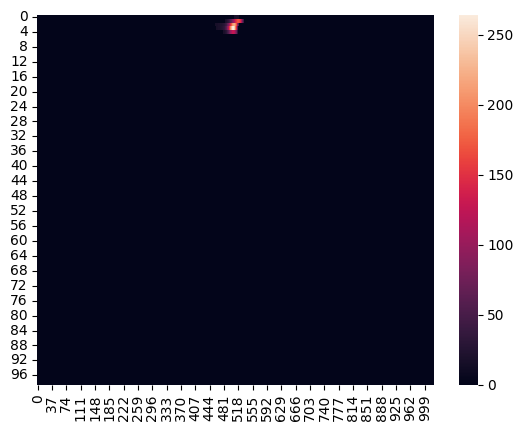

In [275]:
sns.heatmap(protimages[2, 1])

In [146]:
p = np.stack([p_c_d, p_i_d], axis=1)            # shape: (N, 2, H, W)
d = np.stack([d_c_d, d_i_d], axis=1)            # shape: (N, 2, H, W)

p = np.vstack([p, d])

In [148]:
p = torch.from_numpy(p).float()
d = torch.from_numpy(d).float()

In [149]:
class CAE(nn.Module):
    def __init__(self, input_hw=(240, 240), latent=8):
        super(CAE, self).__init__()
        in_h, in_w = input_hw
        assert in_h % 16 == 0 and in_w % 16 == 0, "input spatial dims must be divisible by 16"

        self.encoder = nn.Sequential(
            nn.Conv2d(2, 32, 5, stride=2, padding=2), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 5, stride=2, padding=2), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 5, stride=2, padding=2), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 5, stride=2, padding=2), nn.BatchNorm2d(256), nn.ReLU()
        )

        self.h_enc = in_h // 16
        self.w_enc = in_w // 16
        flat_size = 256 * self.h_enc * self.w_enc

        self.fc_enc = nn.Linear(flat_size, latent)
        self.fc_dec = nn.Linear(latent, flat_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 2, 5, stride=2, padding=2, output_padding=1),
            nn.ReLU()  
        )

    def forward(self, x):
        enc = self.encoder(x)            # (B,256,H_enc,W_enc)
        z = enc.view(enc.size(0), -1)    # (B, flat_size)
        z = self.fc_enc(z)               # (B, latent)
        z = self.fc_dec(z)               # (B, flat_size)
        y = z.view(x.size(0), 256, self.h_enc, self.w_enc)  # (B,256,H_enc,W_enc)
        y = self.decoder(y)              # (B,H,W)
        return y

In [150]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Training device:", device)

X = torch.tensor(p, dtype=torch.float32)  # shape (N, 2, H, W)
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

epochs = 100
batch_size = 32

fold_train_losses, fold_val_losses = [], []
fold_REs = []
fold_REs_d_d = []

Training device: mps


/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_14403/457457524.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(p, dtype=torch.float32)  # shape (N, 2, H, W)



===== Fold 1/5 =====
Epoch 1/100: Train=87.4177126104, Val=55.7517253331
Epoch 2/100: Train=47.2478411588, Val=37.6739562580
Epoch 3/100: Train=37.4680831042, Val=33.6615730694
Epoch 4/100: Train=33.7621019884, Val=30.7005871705
Epoch 5/100: Train=29.6395052130, Val=26.2274121898
Epoch 6/100: Train=25.1903463797, Val=22.6082442488
Epoch 7/100: Train=22.8371884173, Val=20.8911684922
Epoch 8/100: Train=21.0724246285, Val=18.8329716069
Epoch 9/100: Train=19.7481657462, Val=18.8259679079
Epoch 10/100: Train=19.2801381978, Val=17.7436381749
Epoch 11/100: Train=17.9033412066, Val=16.9943966695
Epoch 12/100: Train=17.4557385271, Val=17.6445885386
Epoch 13/100: Train=17.0991450570, Val=16.2592172452
Epoch 14/100: Train=16.0668167028, Val=15.8099164282
Epoch 15/100: Train=15.7214906866, Val=15.2050696611
Epoch 16/100: Train=14.8412819169, Val=14.3203724282
Epoch 17/100: Train=14.1115954703, Val=14.2100063051
Epoch 18/100: Train=14.0579481082, Val=13.9555343900
Epoch 19/100: Train=13.2788860278

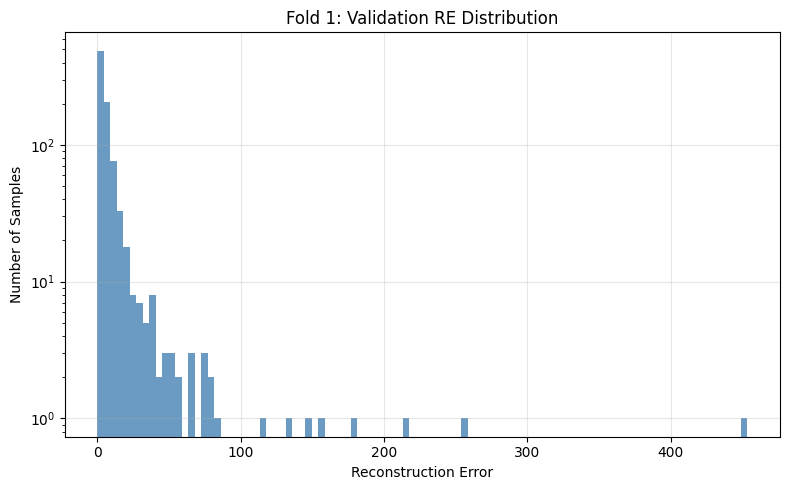

Computing RE on unseen dataset (d)...


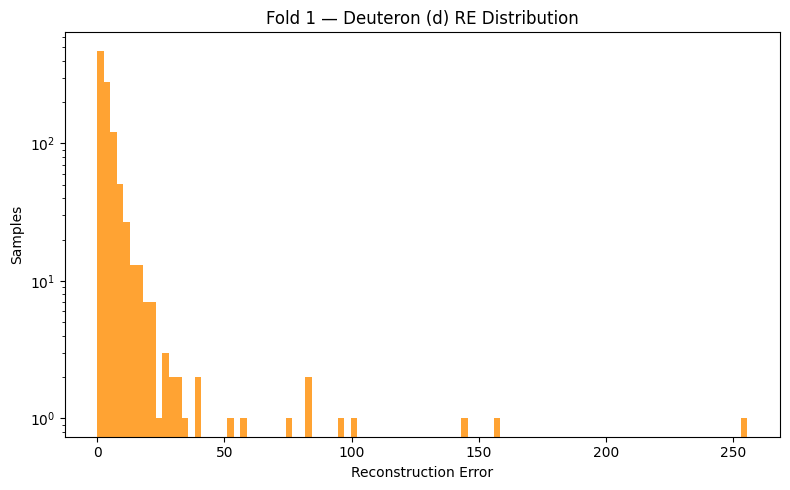


===== Fold 2/5 =====
Epoch 1/100: Train=79.1000067104, Val=51.2353143692
Epoch 2/100: Train=44.2236294486, Val=39.1191710404
Epoch 3/100: Train=36.6856375608, Val=34.9773741109
Epoch 4/100: Train=33.0232461409, Val=32.9438177177


KeyboardInterrupt: 

In [153]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n===== Fold {fold+1}/{n_splits} =====")

    train_subset = Subset(X, train_idx)
    val_subset = Subset(X, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    model = CAE(input_hw=(64, 64), latent=16).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    train_losses, val_losses = [], []

    # --- Training ---
    for epoch in range(epochs):
        model.train()
        total_train, total_val = 0.0, 0.0

        for xb in train_loader:
            xb = xb.to(device)
            optim.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, xb)
            loss.backward()
            optim.step()
            total_train += loss.item()

        model.eval()
        with torch.no_grad():
            for xb in val_loader:
                xb = xb.to(device)
                preds = model(xb)
                loss = loss_fn(preds, xb)
                total_val += loss.item()

        train_losses.append(total_train / len(train_loader))
        val_losses.append(total_val / len(val_loader))

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train={train_losses[-1]:.10f}, Val={val_losses[-1]:.10f}")

    fold_train_losses.append(train_losses)
    fold_val_losses.append(val_losses)

    # -----------------------------
    # 4. Reconstruction error (RE) on this fold's validation set
    # -----------------------------
    print("Computing validation REs...")

    model.eval()
    device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device_inf)

    X_val_np = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()
    N, C, H, W = X_val_np.shape
    recon_all = np.empty((N, C, H, W), dtype=np.float32)


    latent_dim = model.fc_enc.out_features
    latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

    with torch.no_grad():
        for i in range(0, N, 8):
            j = min(i + 8, N)
            xb = torch.tensor(X_val_np[i:j], dtype=torch.float32).to(device_inf)
            out = model(xb)
            recon_all[i:j] = out.cpu().numpy()

            enc = model.encoder(xb)
            z_flat = enc.flatten(1)
            z = model.fc_enc(z_flat)
            latent_vectors[i:j] = z.cpu().numpy()

            if device_inf.type == "mps":
                try:
                    torch.mps.empty_cache()
                except Exception:
                    pass

    mse_per_pixel = (recon_all - X_val_np) ** 2
    RE_per_sample = mse_per_pixel.mean(axis=(1, 2, 3))
    fold_REs.append(RE_per_sample)

    plt.figure(figsize=(8, 5))
    plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Number of Samples")
    plt.title(f"Fold {fold+1}: Validation RE Distribution")
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # === Compute Reconstruction Error on Unseen Data (d_d) ======
    # ============================================================

    print("Computing RE on unseen dataset (d)...")

    Xd_np = d.cpu().numpy() if torch.is_tensor(d) else np.array(d, dtype=np.float32)       # unseen data
    N, C, H, W = Xd_np.shape
    recon_all_d = np.empty((N, C, H, W), dtype=np.float32)

    latent_vectors_d = np.empty((N, latent_dim), dtype=np.float32)

    with torch.no_grad():
        for i in range(0, N, 8):
            j = min(i + 8, N)
            xb = torch.tensor(Xd_np[i:j], dtype=torch.float32).to(device_inf)
            out = model(xb)
            recon_all_d[i:j] = out.cpu().numpy()

            enc = model.encoder(xb)
            z_flat = enc.flatten(1)
            z = model.fc_enc(z_flat)
            latent_vectors_d[i:j] = z.cpu().numpy()

            if device_inf.type == "mps":
                try:
                    torch.mps.empty_cache()
                except Exception:
                    pass

    RE_d_d = ((recon_all_d - Xd_np) ** 2).mean(axis=(1, 2, 3))
    fold_REs_d_d.append(RE_d_d)

    plt.figure(figsize=(8, 5))
    plt.hist(RE_d_d, bins=100, color='darkorange', alpha=0.8)
    plt.yscale('log')
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Samples")
    plt.title(f"Fold {fold+1} — Deuteron (d) RE Distribution")
    plt.tight_layout()
    plt.show()

    # torch.save(model.state_dict(), f"msefolds/CAE_fold{fold+1}.pt")
    # np.save(f"msefolds/RE_val_fold{fold+1}.npy", RE_per_sample)
    # np.save(f"msefolds/RE_d_d_fold{fold+1}.npy", RE_d_d)
    # np.save(f"msefolds/latent_val_fold{fold+1}.npy", latent_vectors)
    # np.save(f"msefolds/latent_d_d_fold{fold+1}.npy", latent_vectors_d)

    # print(f"Saved model and RE arrays for fold {fold+1}.")


plt.figure(figsize=(10, 6))
plt.plot(torch.tensor(fold_train_losses).mean(dim=0), label='Avg Training Loss')
plt.plot(torch.tensor(fold_val_losses).mean(dim=0), label='Avg Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{n_splits}-Fold CV Average Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

all_REs = np.concatenate(fold_REs)
plt.figure(figsize=(8, 5))
plt.hist(all_REs, bins=100, color='teal', alpha=0.7)
plt.yscale('log')
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title(f"Validation RE Distribution (All {n_splits} folds combined)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

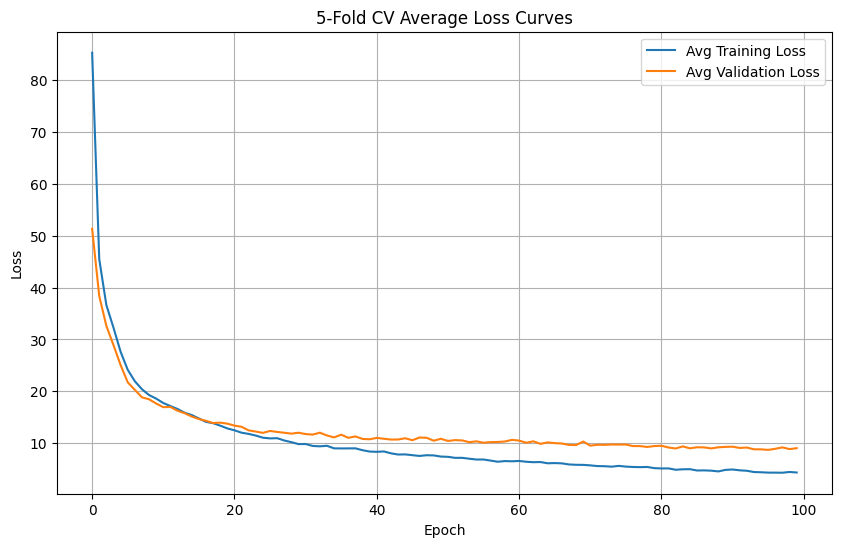

In [154]:
plt.figure(figsize=(10, 6))
plt.plot(torch.tensor(fold_train_losses).mean(dim=0), label='Avg Training Loss')
plt.plot(torch.tensor(fold_val_losses).mean(dim=0), label='Avg Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{n_splits}-Fold CV Average Loss Curves')
plt.legend()
plt.grid(True)
# plt.savefig('Loss.png', dpi=1000)
plt.show()

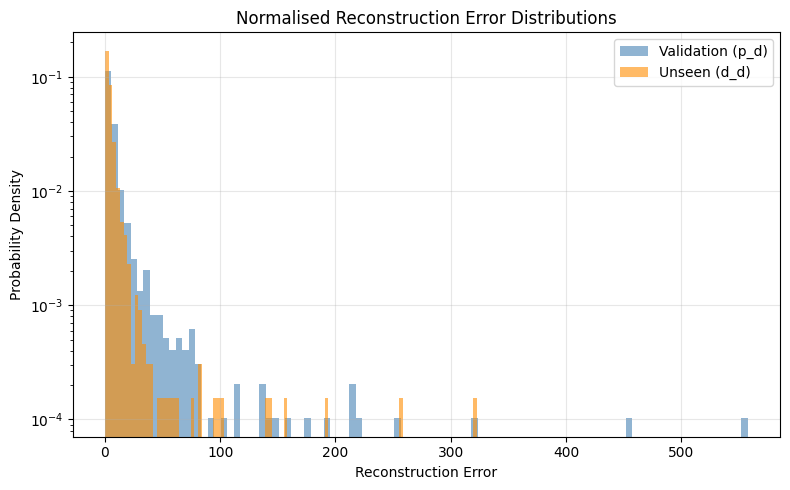

Validation mean RE: 9.1598453522 ± 25.8898143768
Unseen (d_d) mean RE: 5.0948381424 ± 13.4311265945


In [156]:
all_RE_val = np.concatenate(fold_REs)
all_RE_d_d  = np.concatenate(fold_REs_d_d)

plt.figure(figsize=(8, 5))
plt.hist(all_RE_val, bins=100, density=True, alpha=0.6, color='steelblue', label='Validation (p_d)')
plt.hist(all_RE_d_d, bins=100, density=True, alpha=0.6, color='darkorange', label='Unseen (d_d)')
plt.xlabel("Reconstruction Error")
plt.ylabel("Probability Density")
plt.title("Normalised Reconstruction Error Distributions")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Validation mean RE: {all_RE_val.mean():.10f} ± {all_RE_val.std():.10f}")
print(f"Unseen (d_d) mean RE: {all_RE_d_d.mean():.10f} ± {all_RE_d_d.std():.10f}")

Inference device: mps
recon_all.shape: (3504, 2, 64, 64)
latent_vectors.shape: (3504, 16)
RE_per_sample.shape: (3504,)


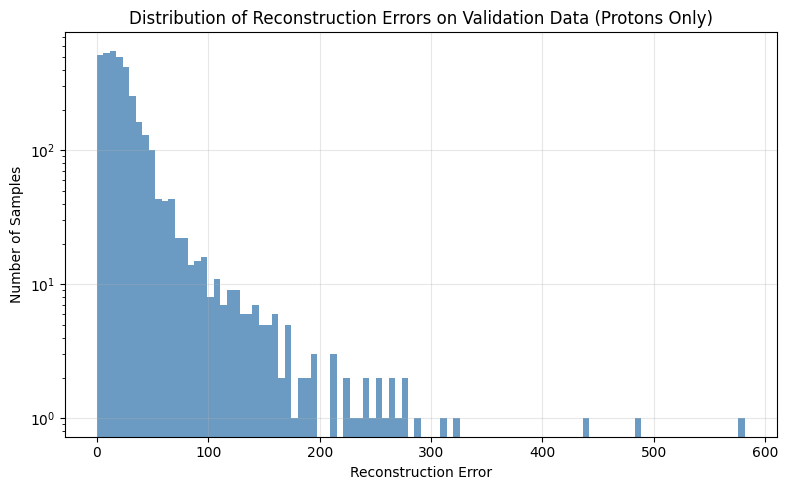

In [157]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X_np = torch.stack([train_subset[i] for i in range(len(train_subset))]).cpu().numpy()        # (N, 2, H, W)
N, C, H, W = X_np.shape

batch_size = 8   
recon_all = np.empty((N, C, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, 2, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, 2, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all[i:j] = out_cpu

        # latent
        enc = model.encoder(xb)              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all - X_np) ** 2
RE_per_sample = mse_per_pixel.mean(axis=(1, 2, 3))        # (N,)

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample.shape:", RE_per_sample.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.tight_layout()
plt.show()

Inference device: mps
recon_all.shape: (876, 2, 64, 64)
latent_vectors.shape: (876, 16)
RE_per_sample.shape: (876,)


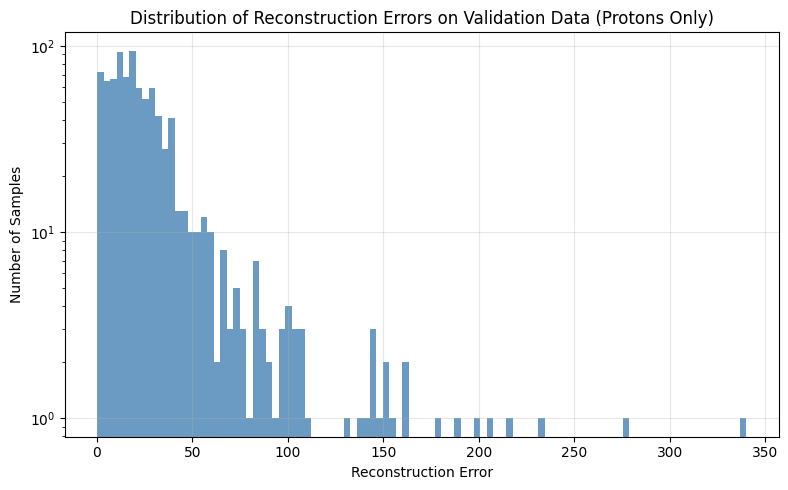

In [158]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X_nval = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()        # (N, H, W)
N, C, H, W = X_nval.shape

batch_size = 8   
recon_all_val = np.empty((N, C, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors_val = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_nval[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all_val[i:j] = out_cpu

        # latent
        enc = model.encoder(xb)              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors_val[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all_val - X_nval) ** 2
RE_per_sample_val = mse_per_pixel.mean(axis=(1, 2, 3))        # (N,)

print("recon_all.shape:", recon_all_val.shape)
print("latent_vectors.shape:", latent_vectors_val.shape)
print("RE_per_sample.shape:", RE_per_sample_val.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample_val, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.tight_layout()
plt.show()

recon_all_d.shape: (1014, 2, 64, 64)
latent_vectors.shape: (1014, 16)
RE_per_sample_d.shape: (1014,)


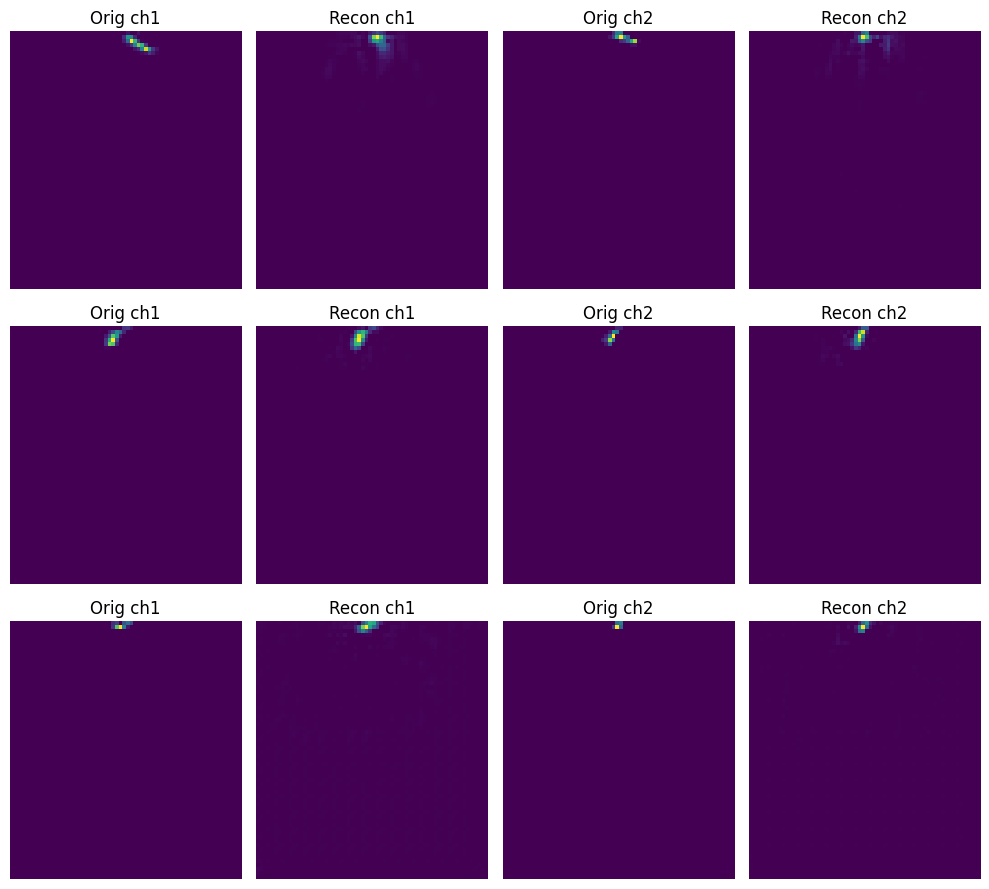

In [159]:
device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.eval()
model.to(device_inf)

Xd_np = d.cpu().numpy() if torch.is_tensor(d) else np.array(d, dtype=np.float32)          # (N, H, W)
N, C, H, W = Xd_np.shape
batch_size = 8                           # lower if OOM on MPS

recon_all_d = np.empty((N, C, H, W), dtype=np.float32)
latent_dim = model.fc_enc.out_features
latent_vectors_d = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb = torch.tensor(Xd_np[i:j], dtype=torch.float32).to(device_inf)  # (b,H,W)

        out = model(xb)                         # (b,H,W)
        recon_all_d[i:j] = out.cpu().numpy()

        enc = model.encoder(xb)    # (b,C,h_enc,w_enc)
        z_flat = enc.flatten(1)                 # (b,flat_size)
        z = model.fc_enc(z_flat)                # (b,latent)
        latent_vectors_d[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

RE_per_sample_d = ((recon_all_d - Xd_np) ** 2).mean(axis=(1, 2, 3))

print("recon_all_d.shape:", recon_all_d.shape)
print("latent_vectors.shape:", latent_vectors_d.shape)
print("RE_per_sample_d.shape:", RE_per_sample_d.shape)

k = min(3, N)  # number of samples to show
fig, axs = plt.subplots(k, 4, figsize=(10, 3*k))  # 2 channels × (orig,recon)

for ii in range(k):
    for c in range(2):
        axs[ii, 2*c].imshow(Xd_np[ii, c], cmap='viridis', aspect='auto')
        axs[ii, 2*c].set_title(f"Orig ch{c+1}")
        axs[ii, 2*c].axis('off')

        axs[ii, 2*c+1].imshow(recon_all_d[ii, c], cmap='viridis', aspect='auto')
        axs[ii, 2*c+1].set_title(f"Recon ch{c+1}")
        axs[ii, 2*c+1].axis('off')

plt.tight_layout()
plt.show()


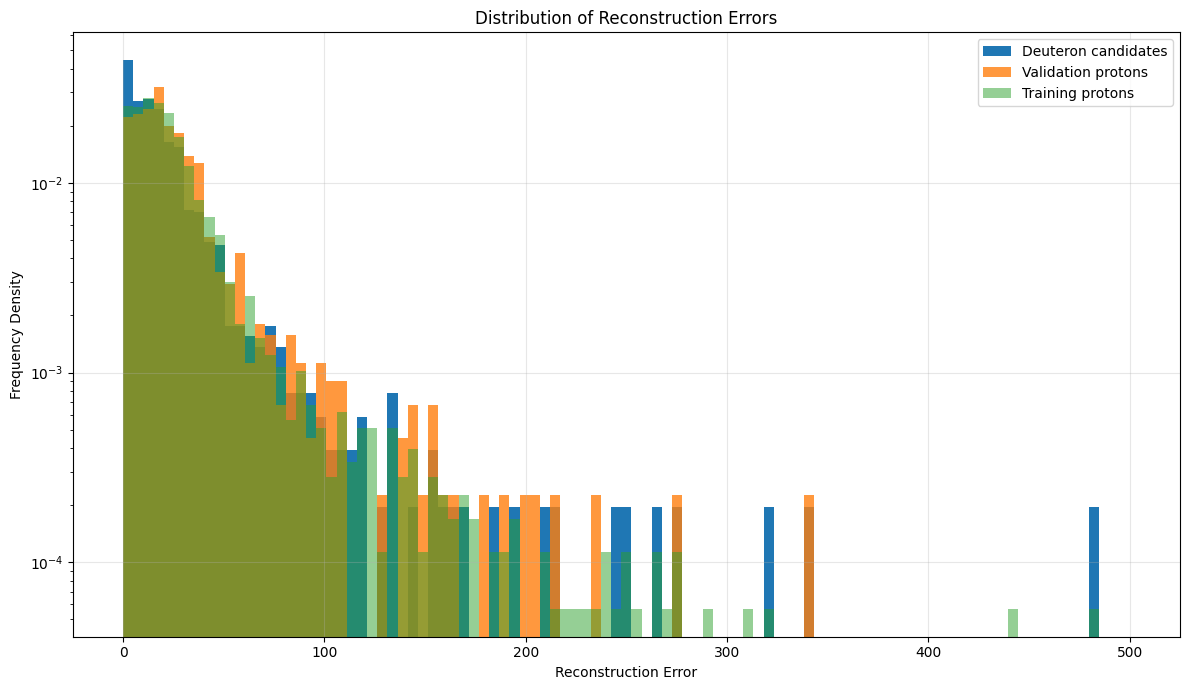

In [185]:
plt.figure(figsize=(12, 7))

bins = np.linspace(0, 500, 100)

plt.hist(RE_per_sample_d, bins=bins, alpha=1, label='Deuteron candidates', density=True)
plt.hist(RE_per_sample_val, bins=bins, alpha=0.8, label='Validation protons', density=True)
plt.hist(RE_per_sample, bins=bins, alpha=0.5, label='Training protons', density=True)

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency Density")
plt.title("Distribution of Reconstruction Errors")
plt.grid(True, alpha=0.3)
plt.yscale('log')
# plt.xlim(0, 300)
plt.legend()
plt.tight_layout()
plt.savefig('RE.png', dpi=1000)
plt.show()

Found 631 samples


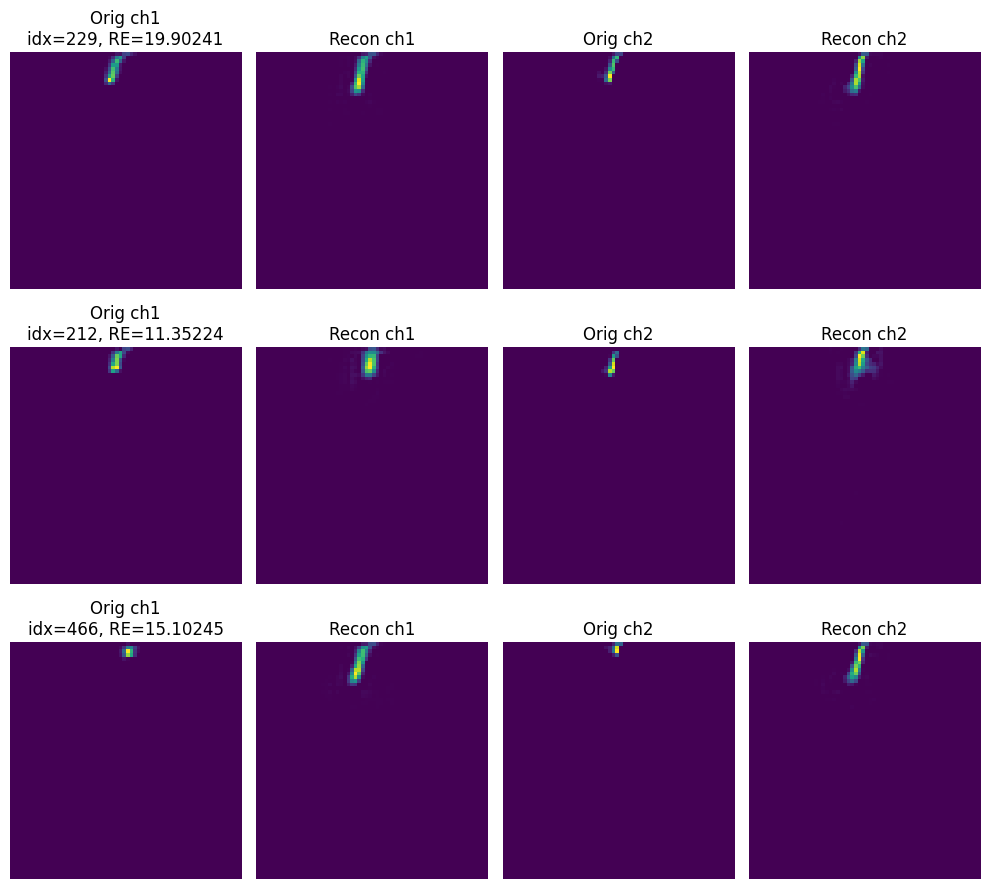

In [161]:
high_re_idx = np.where((RE_per_sample_d > 0) & (RE_per_sample_d < 20))[0]
print(f"Found {len(high_re_idx)} samples")

k = min(3, len(high_re_idx))
if k == 0:
    print("No samples found in specified RE range.")
else:
    selected = np.random.choice(high_re_idx, size=k, replace=False)

    # 4 columns: orig ch1 | recon ch1 | orig ch2 | recon ch2
    fig, axs = plt.subplots(k, 4, figsize=(10, 3*k))

    for ii in range(k):
        idx = selected[ii]

        # --- Channel 1 ---
        axs[ii, 0].imshow(Xd_np[idx, 0], cmap='viridis', aspect='auto')
        axs[ii, 0].set_title(f"Orig ch1\nidx={idx}, RE={RE_per_sample_d[idx]:.5f}")
        axs[ii, 0].axis('off')

        axs[ii, 1].imshow(recon_all[idx, 0], cmap='viridis', aspect='auto')
        axs[ii, 1].set_title("Recon ch1")
        axs[ii, 1].axis('off')

        # --- Channel 2 ---
        axs[ii, 2].imshow(Xd_np[idx, 1], cmap='viridis', aspect='auto')
        axs[ii, 2].set_title("Orig ch2")
        axs[ii, 2].axis('off')

        axs[ii, 3].imshow(recon_all[idx, 1], cmap='viridis', aspect='auto')
        axs[ii, 3].set_title("Recon ch2")
        axs[ii, 3].axis('off')

    plt.tight_layout()
    plt.show()


In [163]:
latent_vectors_d.shape, RE_per_sample_d.shape, recon_all_d.shape

((1014, 16), (1014,), (1014, 2, 64, 64))

In [164]:
latent_vectors.shape, RE_per_sample.shape, recon_all.shape

((3504, 16), (3504,), (3504, 2, 64, 64))

In [165]:
latent_vectors_val.shape, RE_per_sample_val.shape, recon_all_val.shape

((876, 16), (876,), (876, 2, 64, 64))

In [166]:
from sklearn.manifold import TSNE

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_d)),         # 1 = deuterons
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

In [167]:
tsne = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate=50,
    max_iter=2000,
    init='random',
    random_state=42
)
Z_2d = tsne.fit_transform(Z_all)

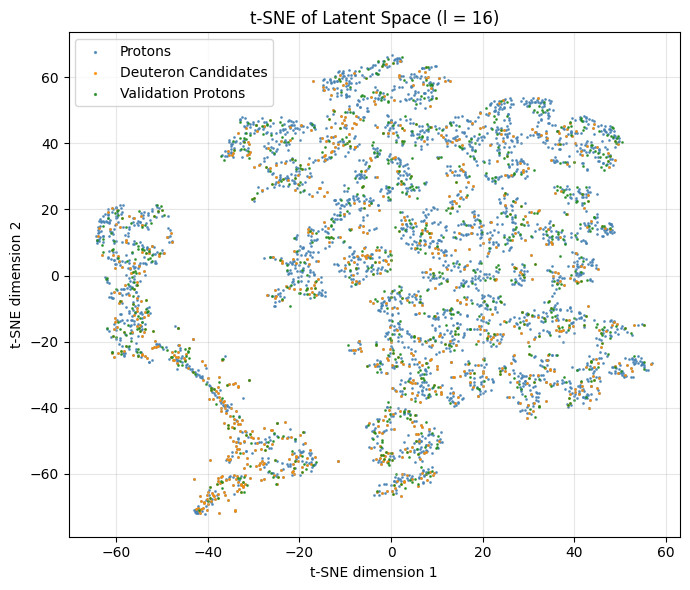

In [168]:
plt.figure(figsize=(7, 6))
colours = ['steelblue', 'darkorange', 'forestgreen']
labels_text = ['Protons', 'Deuteron Candidates', 'Validation Protons']

for i, (colour, label_name) in enumerate(zip(colours, labels_text)):
    plt.scatter(Z_2d[labels == i, 0],
                Z_2d[labels == i, 1],
                color=colour,
                alpha=0.8,
                s=1,
                label=label_name)

plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(markerscale=1.3)
plt.title("t-SNE of Latent Space (l = 16)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

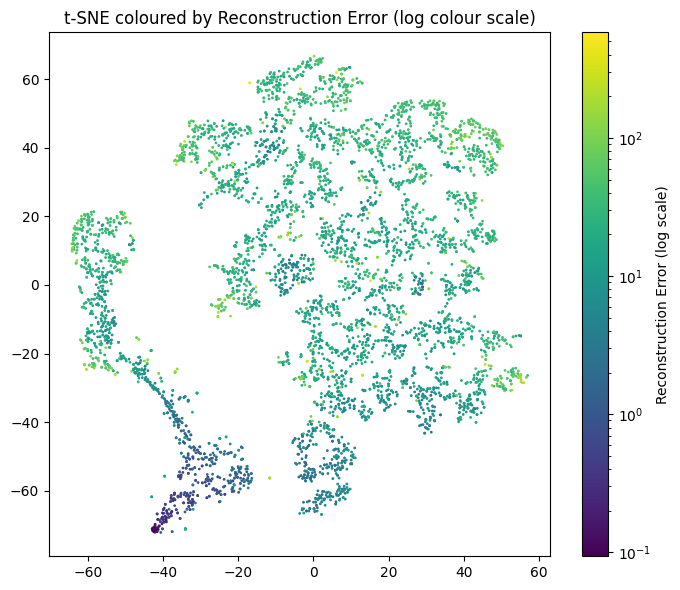

In [169]:
import matplotlib.colors as mcolors

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val])
RE_all = np.concatenate([RE_per_sample, RE_per_sample_d, RE_per_sample_val])

plt.figure(figsize=(7,6))
sc = plt.scatter(Z_2d[:, 0], Z_2d[:, 1],
                 c=RE_all,
                 cmap='viridis',
                 norm=mcolors.LogNorm(vmin=RE_all.min()+1e-8, vmax=RE_all.max()),
                 s=1)
plt.colorbar(sc, label='Reconstruction Error (log scale)')
plt.title("t-SNE coloured by Reconstruction Error (log colour scale)")
plt.tight_layout()
plt.show()

# low error regions and high error regions in deuteron candidates?
# overlap with proton latent vectors?
# separation with proton latent vectors

In [170]:
import umap
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
Z_umap = reducer.fit_transform(Z_all)

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


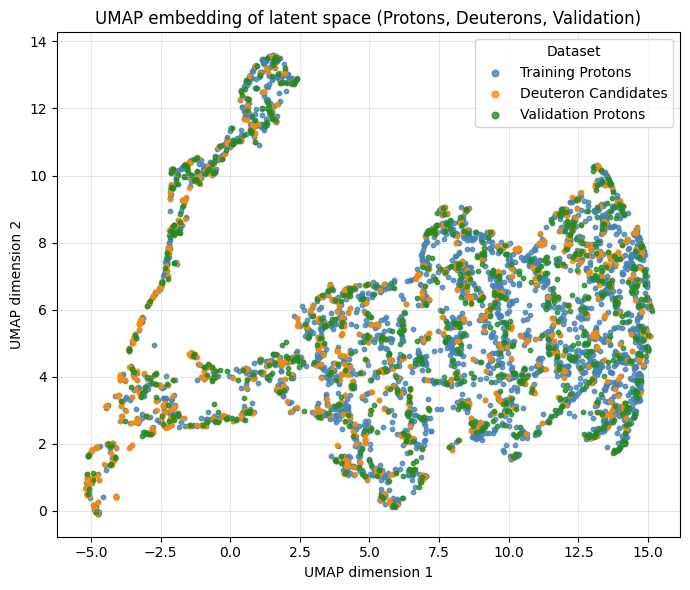

In [171]:
# labels: 0=Protons, 1=Deuterons, 2=Validation
palette = ['steelblue', 'darkorange', 'forestgreen']  # order matches labels

plt.figure(figsize=(7,6))
for i, name in enumerate(['Training Protons', 'Deuteron Candidates', 'Validation Protons']):
    m = (labels == i)
    plt.scatter(Z_umap[m, 0], Z_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)

plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("UMAP embedding of latent space (Protons, Deuterons, Validation)")
plt.legend(title="Dataset", markerscale=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('UMAP.png', dpi=1000)
plt.show()


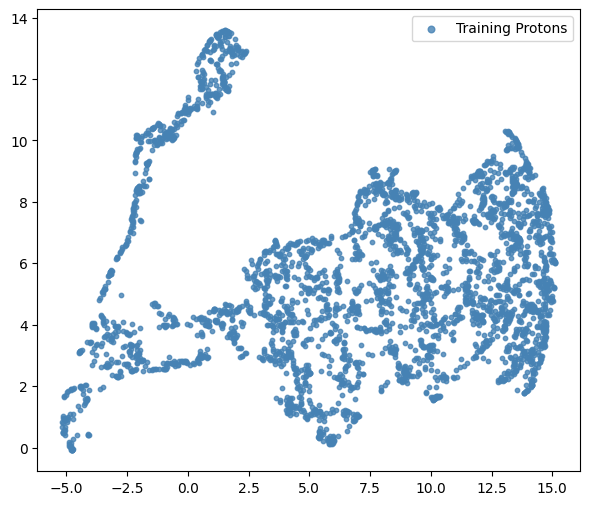

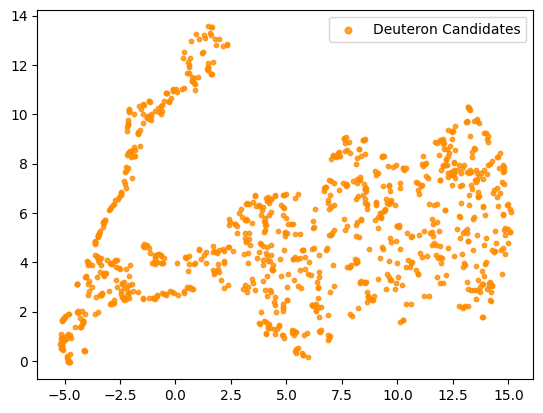

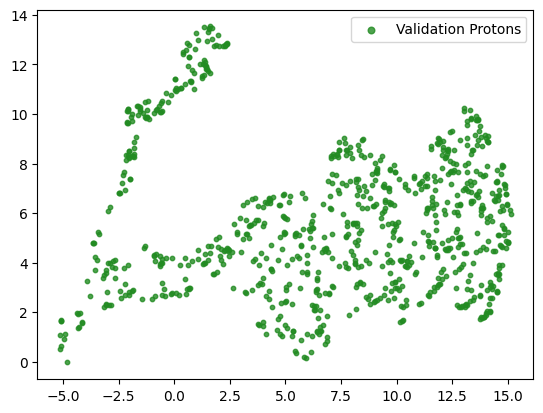

In [172]:
# labels: 0=Protons, 1=Deuterons, 2=Validation
palette = ['steelblue', 'darkorange', 'forestgreen']  # order matches labels

plt.figure(figsize=(7,6))
for i, name in enumerate(['Training Protons', 'Deuteron Candidates', 'Validation Protons']):
    m = (labels == i)
    plt.scatter(Z_umap[m, 0], Z_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)
    plt.legend(markerscale=1.5)
    # plt.xlim(-5, 14)
    # plt.ylim(0, 10)
    plt.show()

# plt.xlabel("UMAP dimension 1")
# plt.ylabel("UMAP dimension 2")
# plt.title("UMAP embedding of latent space (Protons, Deuterons, Validation)")
# plt.legend(title="Dataset", markerscale=1.5)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


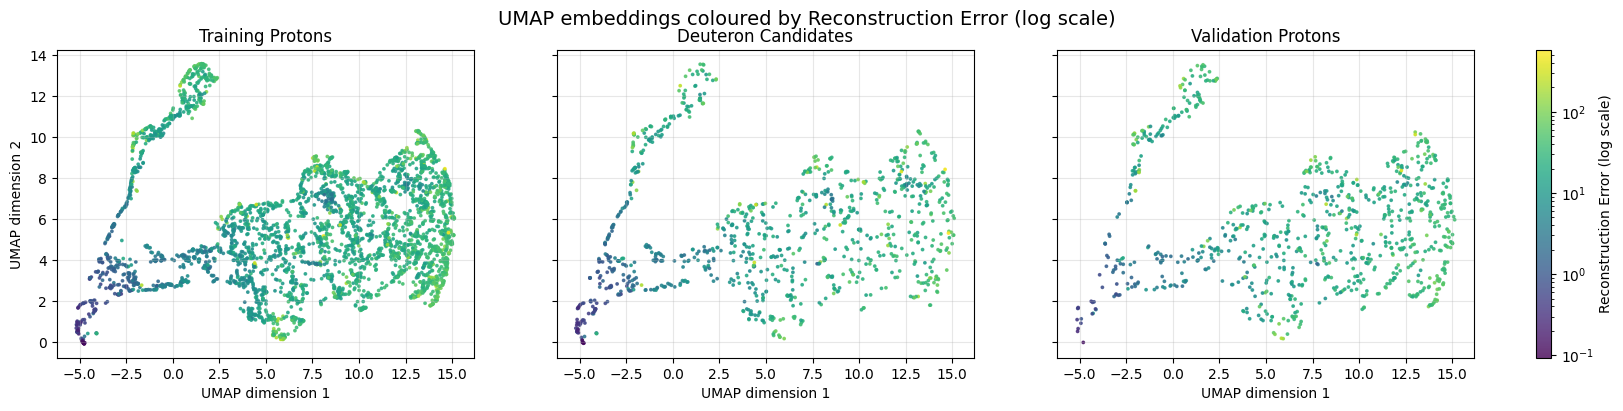

In [173]:
palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

norm = mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max())
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes):
    m = (labels == i)
    sc = ax.scatter(
        Z_umap[m, 0],
        Z_umap[m, 1],
        c=RE_all[m],
        cmap=cmap,
        norm=norm,
        s=3,
        alpha=0.8
    )
    ax.set_title(names[i], fontsize=12)
    ax.set_xlabel("UMAP dimension 1")
    if i == 0:
        ax.set_ylabel("UMAP dimension 2")
    ax.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

fig.suptitle("UMAP embeddings coloured by Reconstruction Error (log scale)", fontsize=14)

# plt.savefig('UMAPandRE.png', dpi=1000)
plt.show()


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


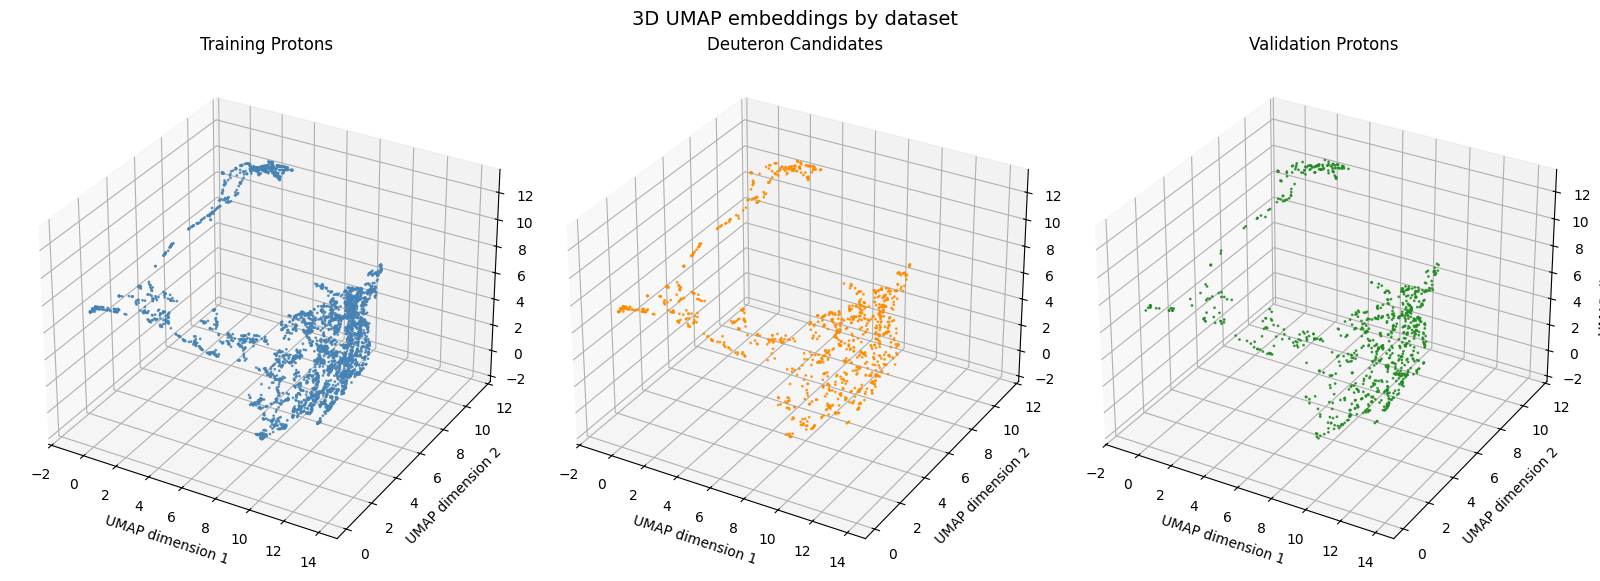

In [174]:
from mpl_toolkits.mplot3d import Axes3D

umap_3d = umap.UMAP(n_components=3, random_state=42)
embedding = umap_3d.fit_transform(Z_all)

palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

fig = plt.figure(figsize=(16, 6))

for i, name in enumerate(names):
    mask = (labels == i)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        color=palette[i],
        s=1,
        alpha=0.8
    )
    ax.set_title(name)
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.set_zlabel("UMAP dimension 3")
    # ax.view_init(elev=25, azim=45)  

fig.suptitle("3D UMAP embeddings by dataset", fontsize=14)
plt.tight_layout()
plt.show()


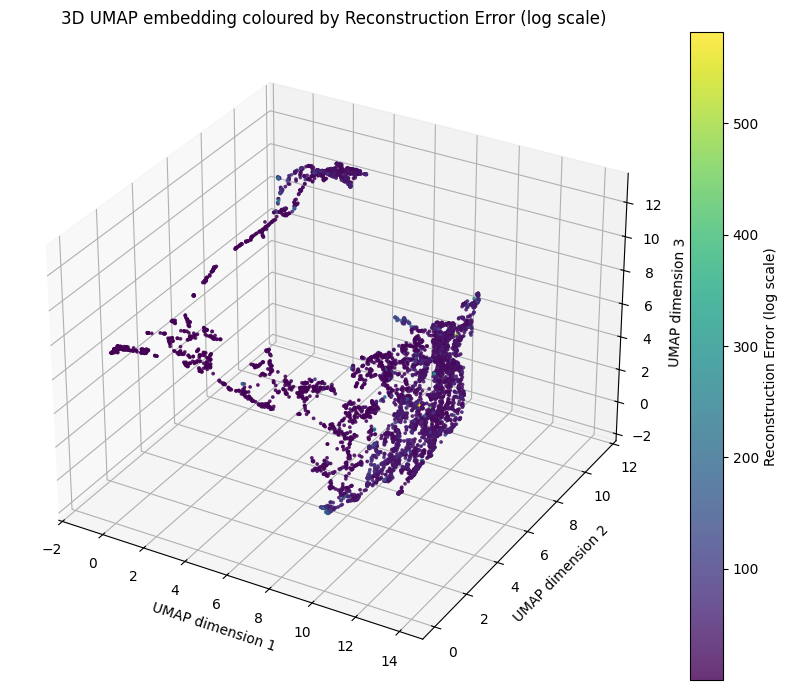

In [175]:
%matplotlib inline

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot coloured by reconstruction error
sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    embedding[:, 2],
    c=RE_all,
    cmap='viridis',
    # norm=mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max()),
    s=3,
    alpha=0.8
)

# Axis labels and title
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.set_zlabel("UMAP dimension 3")
ax.set_title("3D UMAP embedding coloured by Reconstruction Error (log scale)")

# Colour bar
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

plt.tight_layout()
plt.show()


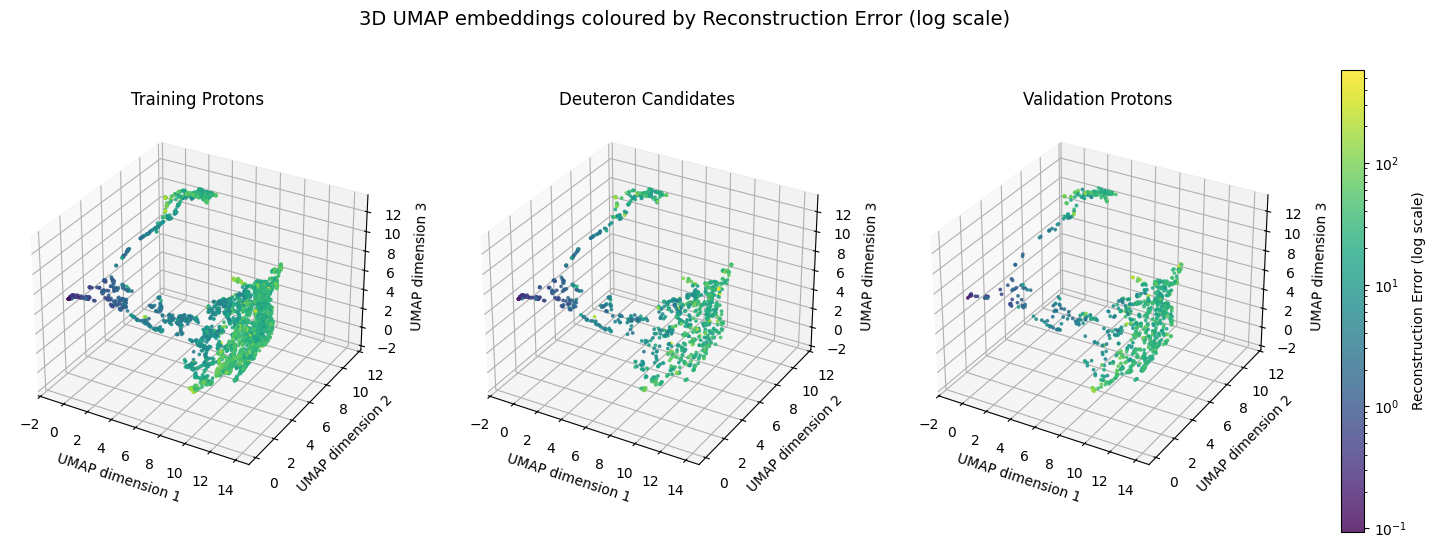

In [176]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Assume: embedding (3D UMAP), RE_all (reconstruction errors), labels (0,1,2)
palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

# Shared normalisation and colormap for all plots
norm = mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max())
cmap = plt.cm.viridis

fig = plt.figure(figsize=(18, 6))

for i, name in enumerate(names):
    mask = (labels == i)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')

    sc = ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        c=RE_all[mask],
        cmap=cmap,
        norm=norm,
        s=3,
        alpha=0.8
    )

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.set_zlabel("UMAP dimension 3")
    # ax.view_init(elev=25, azim=45)  # consistent 3D orientation

# Shared colour bar for all subplots
cbar = fig.colorbar(sc, ax=fig.get_axes(), fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

fig.suptitle("3D UMAP embeddings coloured by Reconstruction Error (log scale)", fontsize=14)
plt.show()


In [177]:
latent_vectors.shape, latent_vectors_val.shape, latent_vectors_d.shape

((3504, 16), (876, 16), (1014, 16))

In [178]:
latent = np.concatenate([latent_vectors, latent_vectors_val])

Deuteron subset shape: (1014, 2)


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


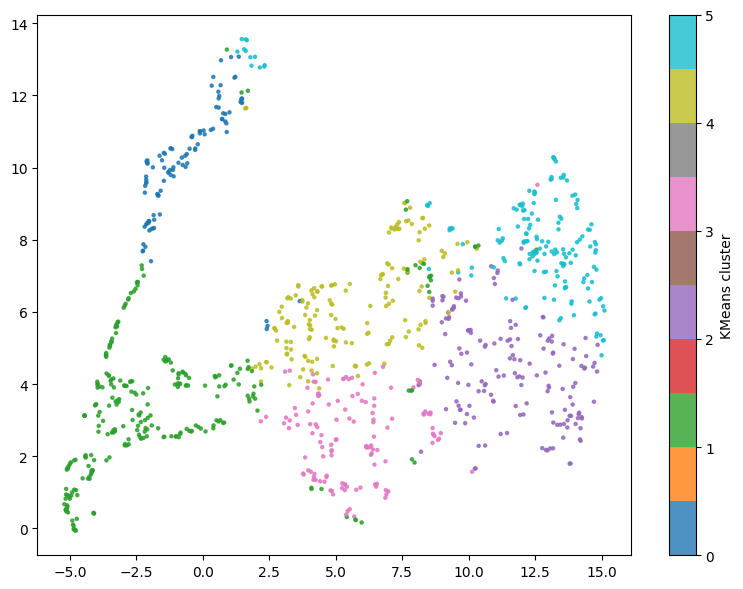

In [179]:
from sklearn.cluster import KMeans

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_d)),         # 1 = deuterons
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

mask = (labels == 1)
Z_d = Z_all[mask]          # latent vectors
E_d = Z_umap[mask]      # 3D UMAP coordinates

print(f"Deuteron subset shape: {E_d.shape}")

kmeans = KMeans(n_clusters=6, random_state=42) #6
labels_km = kmeans.fit_predict(Z_d)

fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                c=labels_km, cmap='tab10', s=5, alpha=0.8)
plt.colorbar(label='KMeans cluster')
ax.set_title("Deuteron candidates — KMeans clusters")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
plt.tight_layout()
# plt.savefig('Kmeans.png', dpi=1000)
plt.show()


In [180]:
p_m = col[col['particle_type'] == 'proton']['beamline_mass'].values
d_m = col[col['particle_type'] == 'deuteron']['beamline_mass'].values

d_l = col[col['particle_type'] == 'deuteron']['height'].values
d_p = col[col['particle_type'] == 'deuteron']['p'].values

d_diff = col[col['particle_type'] == 'deuteron']['maxdiff'].values
p_diff = col[col['particle_type'] == 'proton']['maxdiff'].values

labels = labels_km

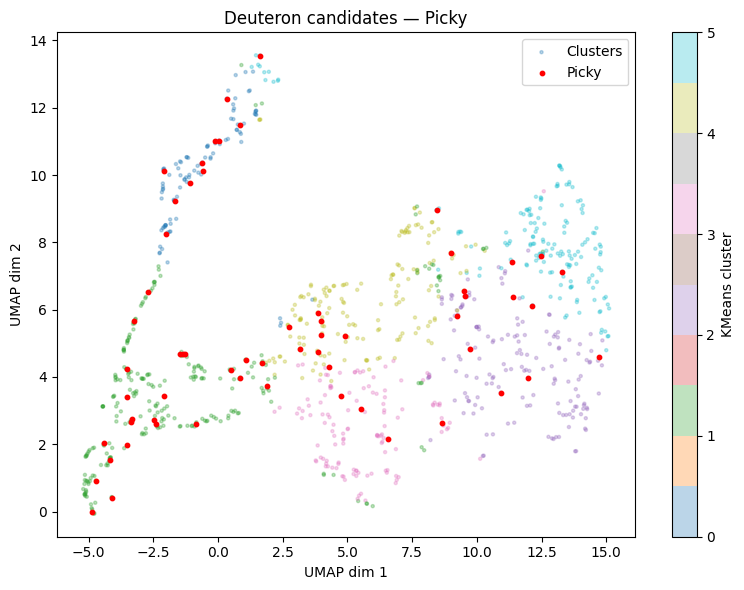

In [181]:
# Highlight points where highlight == 1
highlight_mask = (d_p == 1)

fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(E_d[:, 0], E_d[:, 1], c=labels_km, cmap='tab10', s=5, alpha=0.3, label='Clusters')

# Overlay highlighted points
plt.scatter(E_d[highlight_mask, 0], E_d[highlight_mask, 1], 
            color='red', s=10, label='Picky', alpha=1)

plt.colorbar(sc, label='KMeans cluster')
plt.title("Deuteron candidates — Picky")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.legend()
plt.tight_layout()
# plt.savefig('picky.png', dpi=1000)
plt.show()

/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_14403/33059724.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = plt.scatter(m[:, 0], m[:, 1], cmap='tab10', s=5, alpha=0.8, label='Clusters')


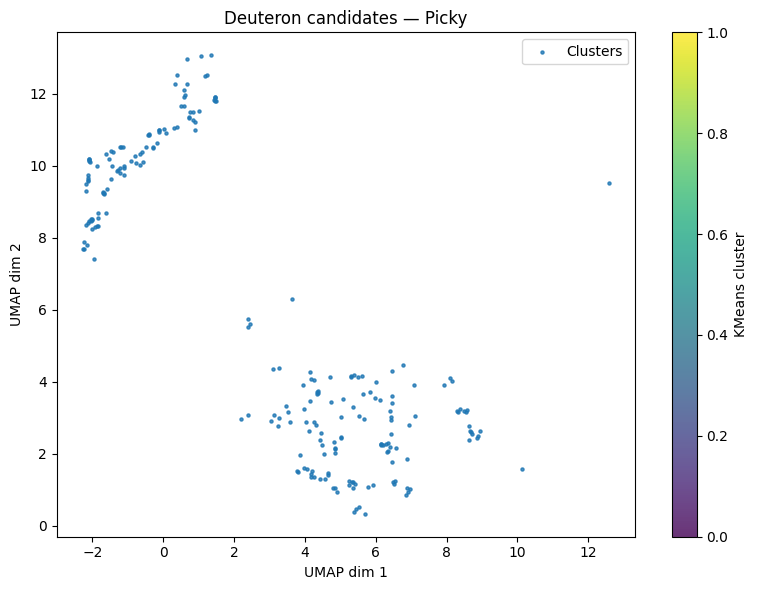

In [182]:
m0 = E_d[(labels == 0)]
m1 = E_d[(labels == 3)]
m = np.concatenate([m0, m1])

# Highlight points where highlight == 1
highlight_mask = (d_p == 1)

fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(m[:, 0], m[:, 1], cmap='tab10', s=5, alpha=0.8, label='Clusters')

plt.colorbar(sc, label='KMeans cluster')
plt.title("Deuteron candidates — Picky")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
unique, counts = np.unique(highlight_mask, return_counts=True)

unique, counts

(array([False,  True]), array([953,  61]))

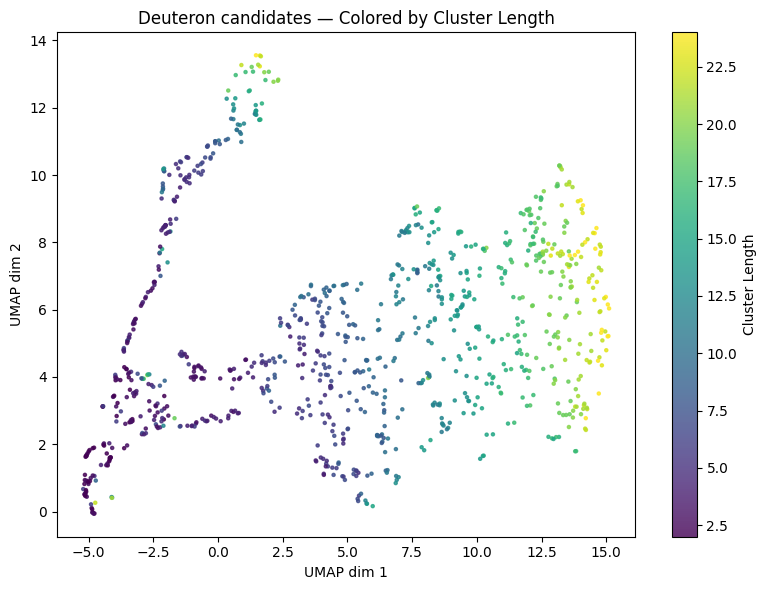

In [183]:
fig = plt.figure(figsize=(8, 6))

# Scatter plot colored by cluster length
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                 c=d_l, cmap='viridis', s=5, alpha=0.8)

# Add a colorbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("Cluster Length")

plt.title("Deuteron candidates — Colored by Cluster Length")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
# plt.savefig('length.png', dpi=1000)
plt.show()

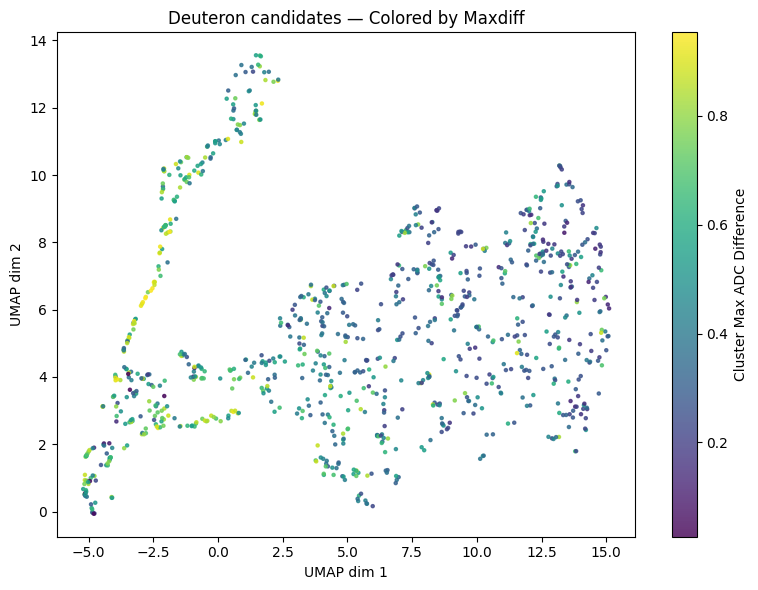

In [184]:
fig = plt.figure(figsize=(8, 6))

# Scatter plot colored by cluster length
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                 c=d_diff, cmap='viridis', s=5, alpha=0.8)

# Add a colorbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("Cluster Max ADC Difference")

plt.title("Deuteron candidates — Colored by Maxdiff")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
# plt.savefig('maxdiff.png', dpi=1000)
plt.show()

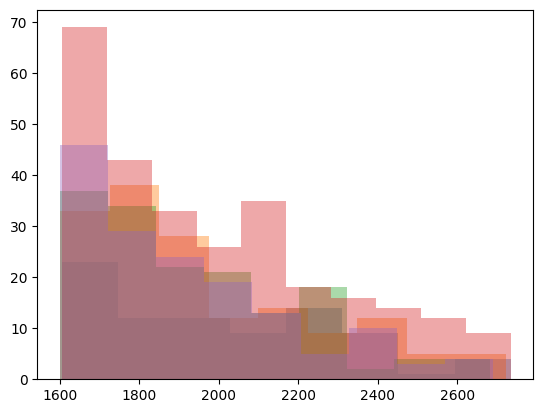

In [64]:
for i in range(5):
    mass = d_m[labels == i]
    plt.hist(mass, bins='auto', alpha=0.4, label=f'Label {i}')

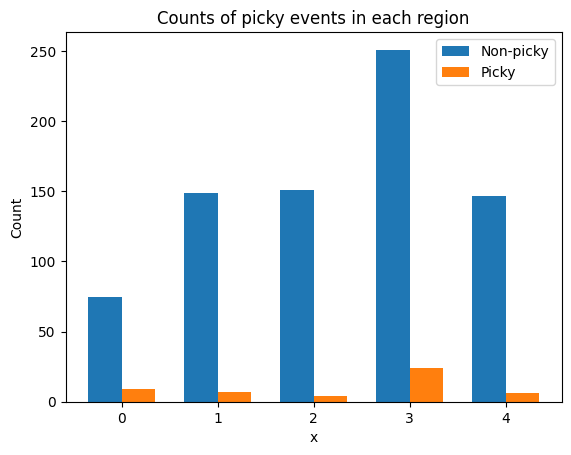

In [65]:
k = 5
counts = np.zeros((k, 2))  # rows: x, cols: label
for i in range(k):
    for j in [0, 1]:
        counts[i, j] = np.sum((labels == i) & (d_p == j))

x_vals = np.arange(k)  # positions for x = 0, 1
width = 0.35

plt.bar(x_vals - width/2, counts[:, 0], width, label='Non-picky', color='tab:blue')
plt.bar(x_vals + width/2, counts[:, 1], width, label='Picky', color='tab:orange')

# plt.xticks(x_vals, ['x=0', 'x=1', 'x=2', 'x=3'])
plt.ylabel('Count')
plt.xlabel('x')
plt.legend()
plt.title('Counts of picky events in each region')
plt.show()


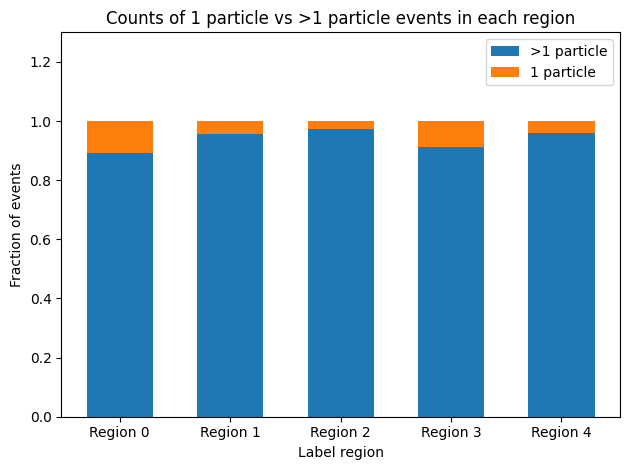

In [67]:
k = 5
counts = np.zeros((k, 2))  # rows: label (0–5), cols: [non-picky, picky]

for i in range(k):
    for j in [0, 1]:
        counts[i, j] = np.sum((labels == i) & (d_p == j))

# Normalise per label
row_sums = counts.sum(axis=1, keepdims=True)
counts_norm = np.divide(counts, row_sums, where=row_sums != 0)  # avoid divide-by-zero

x_vals = np.arange(k)
width = 0.6

# plt.figure(figsize=(8, 5))
plt.bar(x_vals, counts_norm[:, 0], width, label='>1 particle', color='tab:blue')
plt.bar(x_vals, counts_norm[:, 1], width, bottom=counts_norm[:, 0],
        label='1 particle', color='tab:orange')

plt.ylabel('Fraction of events')
plt.xlabel('Label region')
plt.title('Counts of 1 particle vs >1 particle events in each region')
plt.xticks(x_vals, [f'Region {i}' for i in range(k)])
plt.ylim(0, 1.3)
plt.legend()
plt.tight_layout()
plt.savefig('pickyCount.png', dpi=1000)
plt.show()


In [68]:
# look at mass plot of just the picky

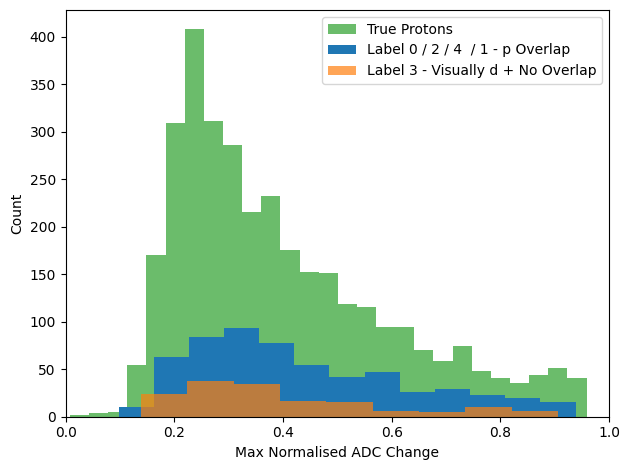

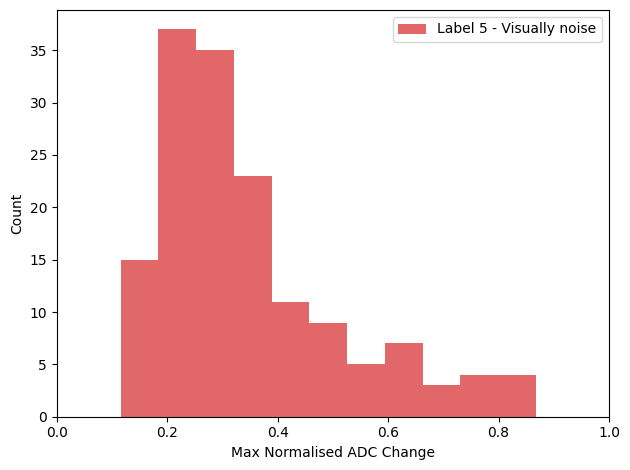

In [69]:
mass_0 = d_diff[(labels == 0) | (labels == 2) | (labels == 5) | (labels == 1) ]
mass_1 = d_diff[(labels == 1)]
mass_2 = d_diff[(labels == 4)]
mass_3 = p_diff

# Plot
plt.hist(mass_3, bins='auto', alpha=0.7, label='True Protons', color='tab:green')
plt.hist(mass_0, bins='auto', alpha=1.0, label='Label 0 / 2 / 4  / 1 - p Overlap', color='tab:blue')
plt.hist(mass_1, bins='auto', alpha=0.7, label='Label 3 - Visually d + No Overlap', color='tab:orange')
plt.xlim(0, 1)
plt.xlabel('Max Normalised ADC Change')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

plt.hist(mass_2, bins='auto', alpha=0.7, label='Label 5 - Visually noise', color='tab:red')


# plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')

plt.xlim(0, 1)
plt.xlabel('Max Normalised ADC Change')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

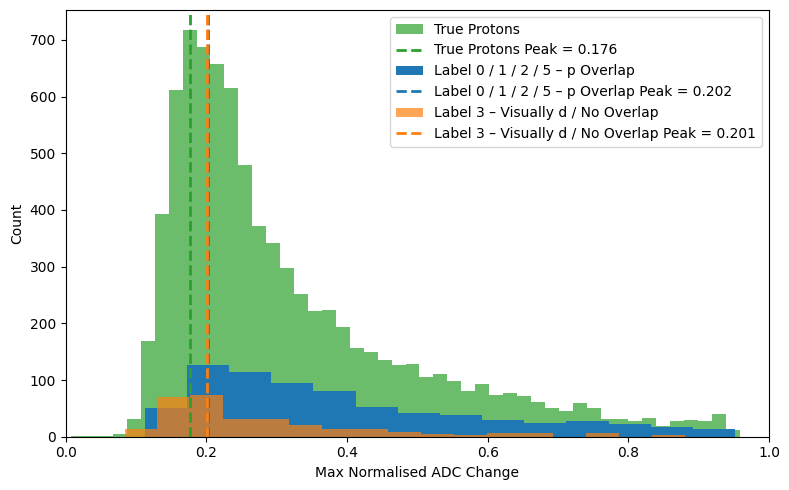

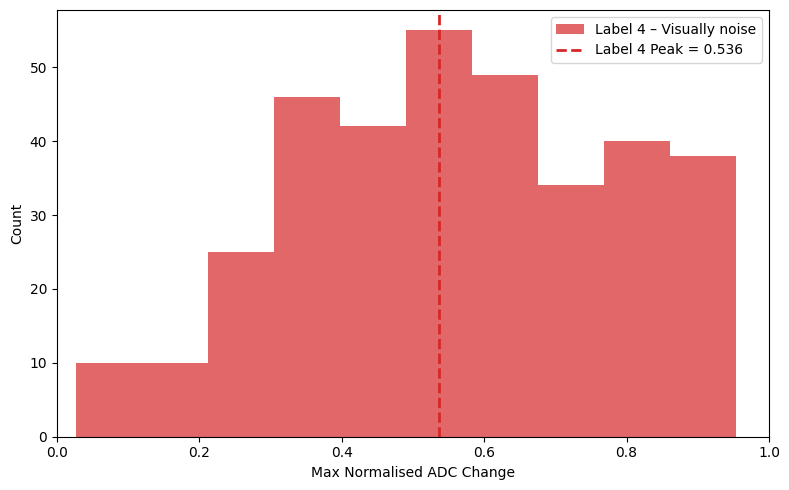

In [62]:
mass_0 = d_diff[(labels == 0) | (labels == 1) | (labels == 2) | (labels == 5)]
mass_1 = d_diff[(labels == 3)]
mass_2 = d_diff[(labels == 4)]
mass_3 = p_diff

plt.figure(figsize=(8, 5))

datasets = [
    (mass_3, 'True Protons', 'tab:green', 0.7),
    (mass_0, 'Label 0 / 1 / 2 / 5 – p Overlap', 'tab:blue', 1.0),
    (mass_1, 'Label 3 – Visually d / No Overlap', 'tab:orange', 0.7),
]

for data, label, colour, alpha in datasets:
    counts, bins, _ = plt.hist(data, bins='auto', alpha=alpha, label=label, color=colour)
    max_bin_idx = np.argmax(counts)
    peak_x = 0.5 * (bins[max_bin_idx] + bins[max_bin_idx + 1])
    plt.axvline(peak_x, color=colour, linestyle='--', linewidth=2,
                label=f'{label} Peak = {peak_x:.3f}')

plt.xlim(0, 1)
plt.xlabel('Max Normalised ADC Change')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
counts, bins, _ = plt.hist(mass_2, bins='auto', alpha=0.7, label='Label 4 – Visually noise', color='tab:red')
max_bin_idx = np.argmax(counts)
peak_x = 0.5 * (bins[max_bin_idx] + bins[max_bin_idx + 1])
plt.axvline(peak_x, color='tab:red', linestyle='--', linewidth=2,
            label=f'Label 4 Peak = {peak_x:.3f}')

plt.xlim(0, 1)
plt.xlabel('Max Normalised ADC Change')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()


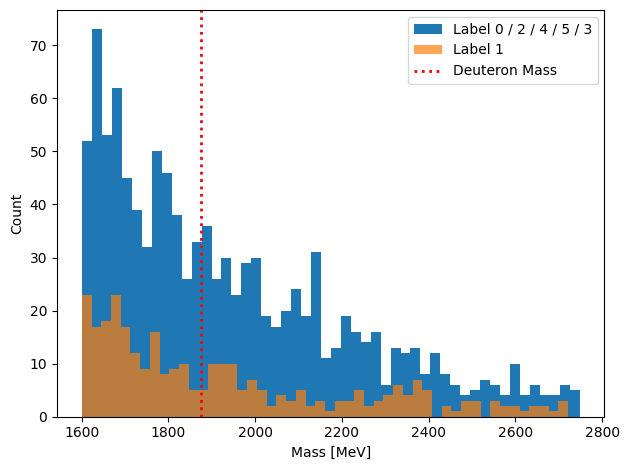

In [63]:
mass_0 = d_m[(labels == 0) | (labels == 2) | (labels == 4) | (labels == 5) | (labels == 1) ]
mass_1 = d_m[(labels == 3)]

# Plot
plt.hist(mass_0, bins=50, alpha=1.0, label='Label 0 / 2 / 4 / 5 / 3', color='tab:blue')
plt.hist(mass_1, bins=50, alpha=0.7, label='Label 1', color='tab:orange')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')

plt.xlabel('Mass [MeV]')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

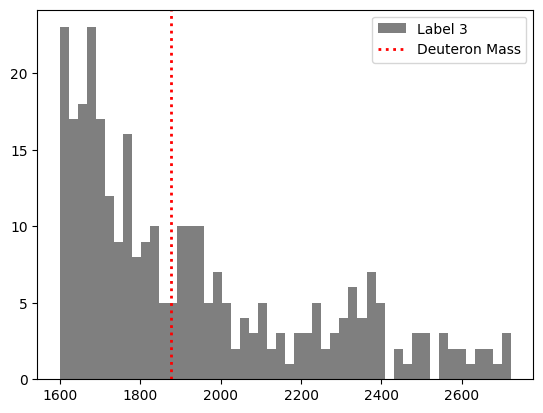

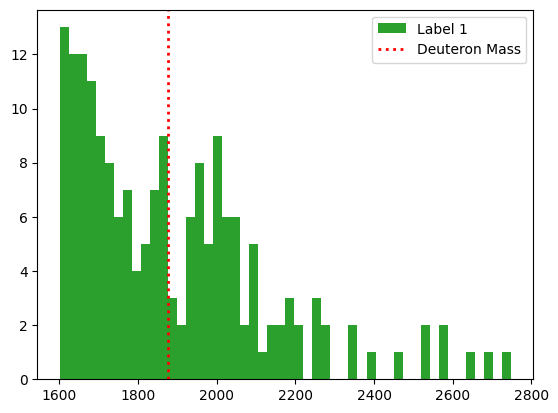

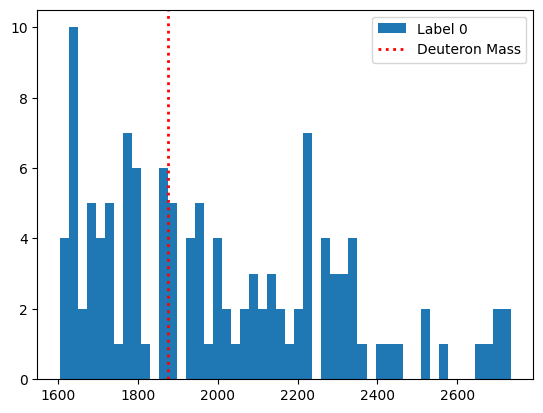

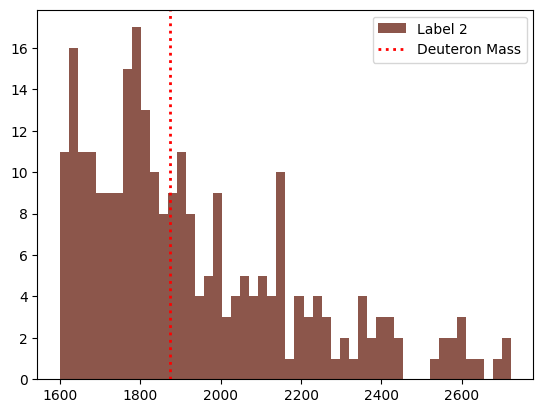

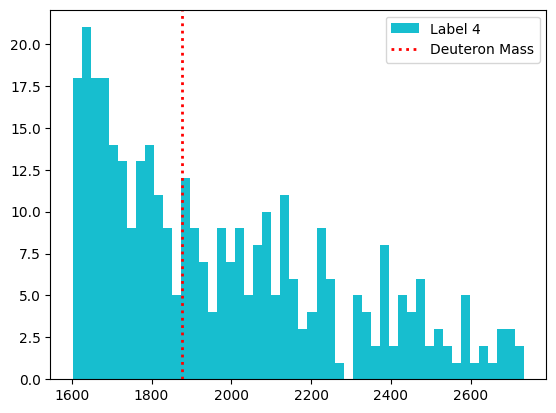

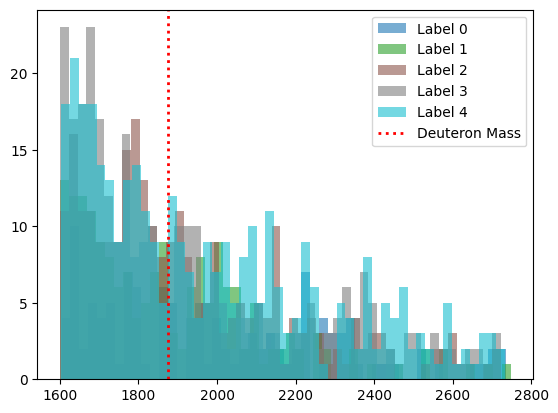

In [64]:
labels = labels_km

m0 = d_m[(labels == 0)]
m1 = d_m[(labels == 1)]
m2 = d_m[(labels == 2)]
m3 = d_m[(labels == 3)]
m4 = d_m[(labels == 4)]
m5 = d_m[(labels == 5)]


label_colours = {
    0: 'tab:blue',   
    1: 'tab:green',  
    2: 'tab:brown',  
    3: 'tab:gray',   
    4: 'tab:cyan'   
}

plt.hist(m3, bins=50, alpha=1, color=label_colours[3], label='Label 3')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

plt.hist(m1, bins=50, alpha=1, color=label_colours[1], label='Label 1')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

plt.hist(m0, bins=50, alpha=1, color=label_colours[0], label='Label 0')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

plt.hist(m2, bins=50, alpha=1, color=label_colours[2], label='Label 2')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

plt.hist(m4, bins=50, alpha=1, color=label_colours[4], label='Label 4')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()

for i, m in enumerate([m0, m1, m2, m3, m4]):
    plt.hist(m, bins=50, alpha=0.6, color=label_colours[i], label=f'Label {i}')

plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
plt.legend(); plt.show()


In [65]:
d_p.shape, d_m.shape, labels.shape

((2421,), (2421,), (2421,))

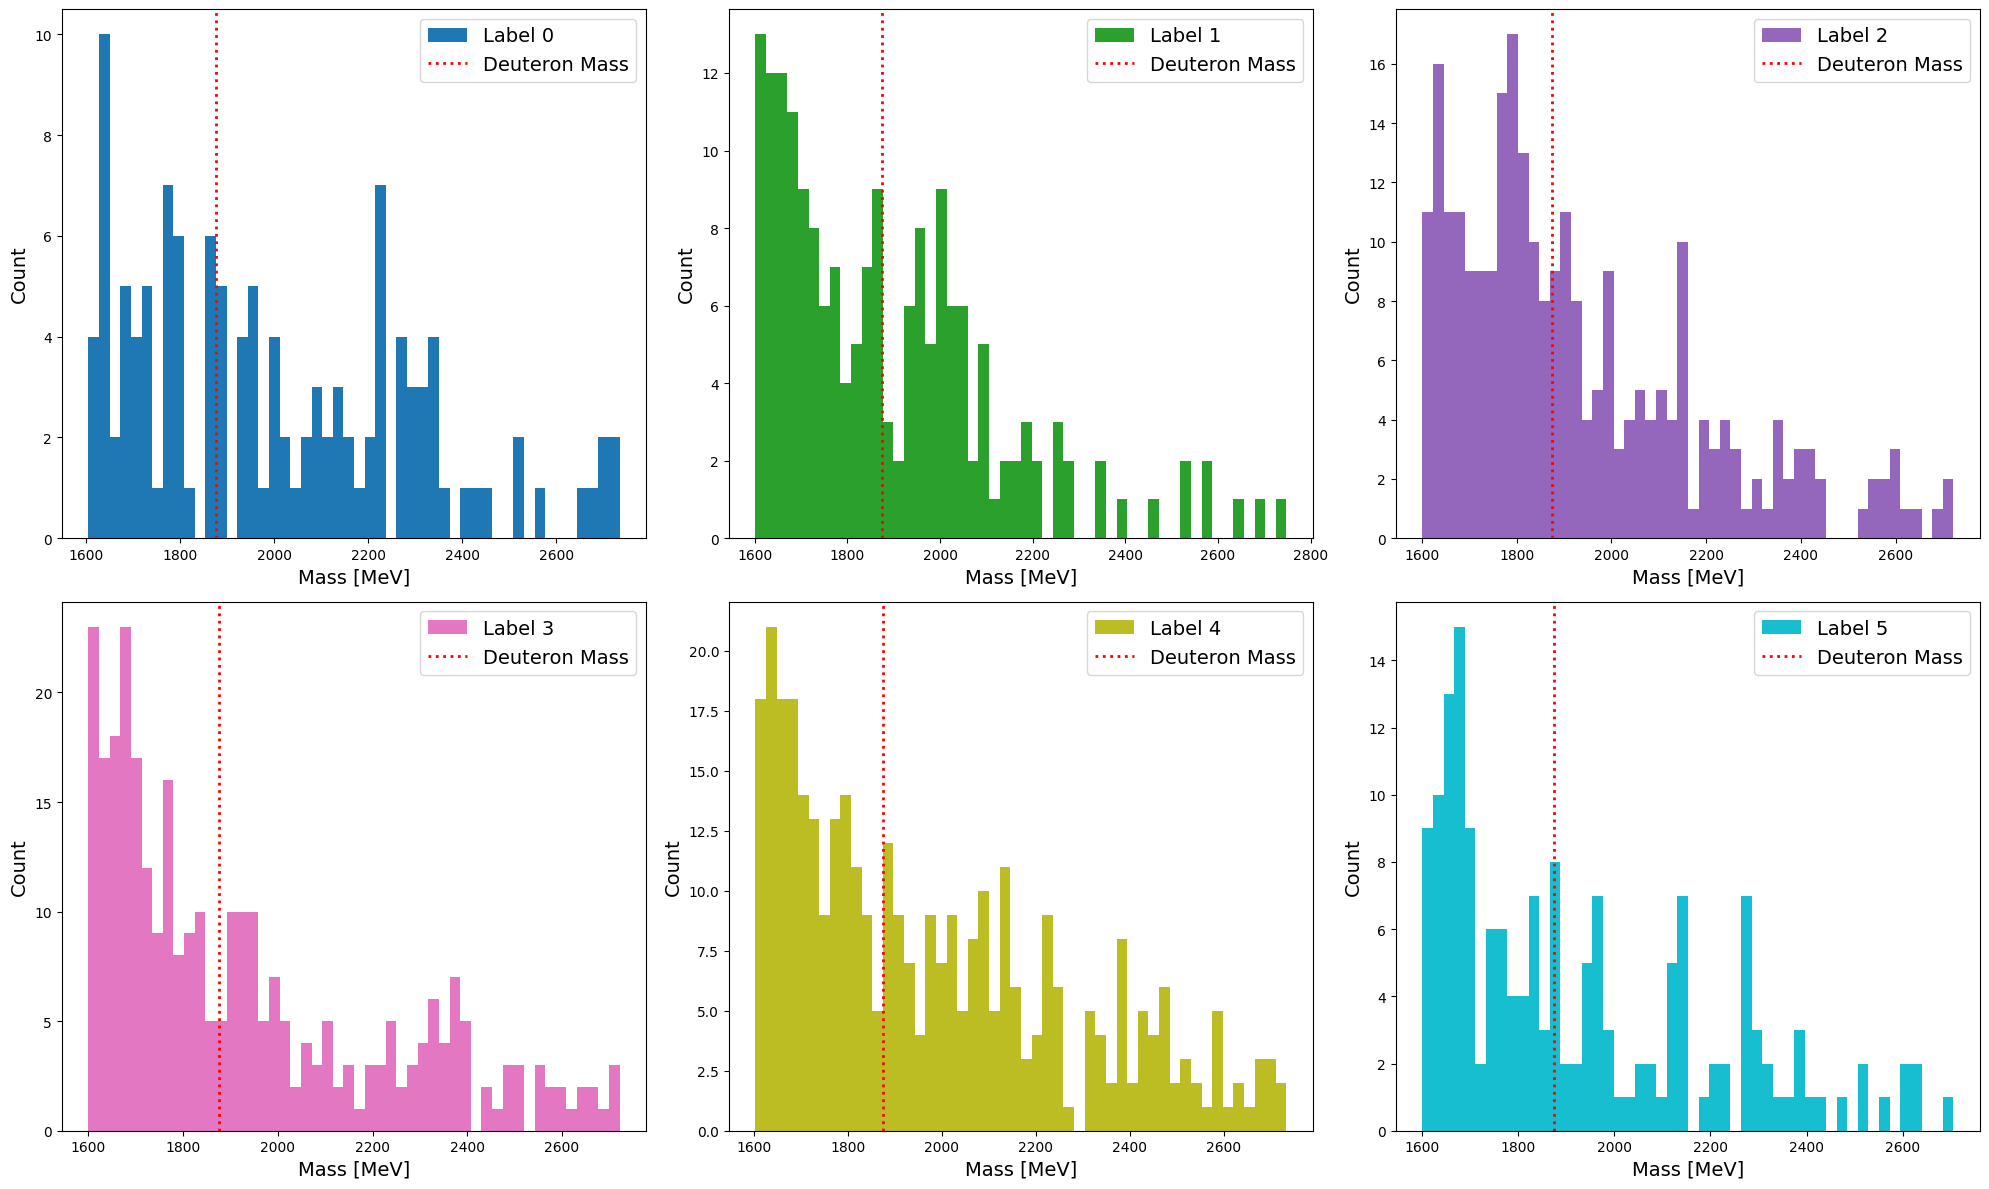

In [66]:
# Define consistent colours
label_colours = {
    0: 'tab:blue',
    1: 'tab:green',
    2: 'tab:purple',
    3: 'tab:pink',
    4: 'tab:olive',
    5: 'tab:cyan'
}

# Your datasets
datasets = {0: m0, 1: m1, 2: m2, 3: m3, 4: m4, 5:m5}

# Create a grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, label in enumerate(datasets.keys()):
    ax = axes[i]
    ax.hist(datasets[label], bins=50, alpha=1, color=label_colours[label], label=f'Label {label}')
    ax.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')
    ax.legend(fontsize=14)
    ax.set_xlabel('Mass [MeV]', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

# Hide any unused subplot (since we have 5 plots but 6 slots)
for j in range(len(datasets), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
# plt.savefig('labelsvmass.png', dpi=500)
plt.show()


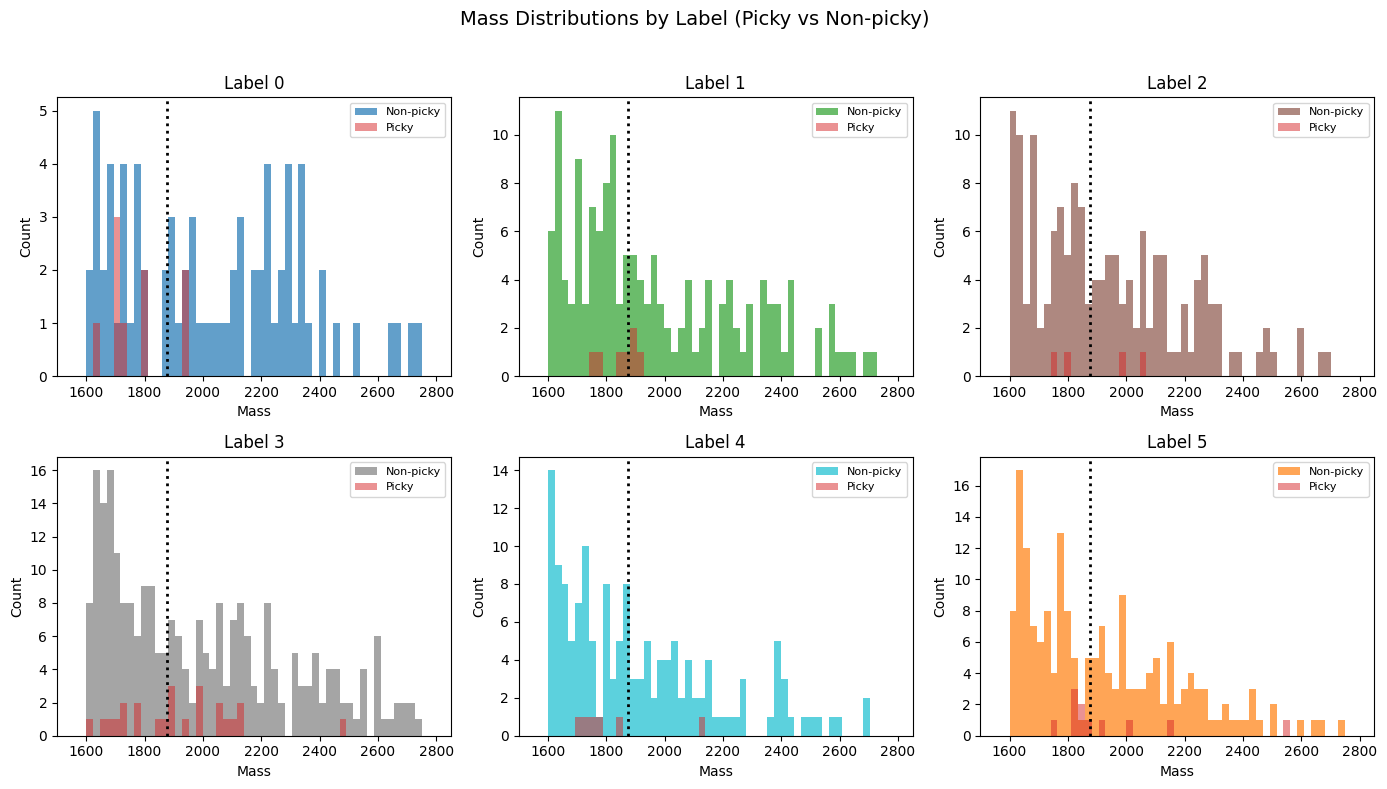

In [70]:
labels = labels_km

label_colours = {
    0: 'tab:blue',
    1: 'tab:green',
    2: 'tab:brown',
    3: 'tab:gray',
    4: 'tab:cyan',
    5: 'tab:orange'
}

unique_labels = np.unique(labels)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

bins = np.linspace(1600, 2750, 50)

for ax, lbl in zip(axes, unique_labels):
    mask = (labels == lbl)
    m_label = d_m[mask]
    m_label_picky = d_m[mask & (d_p == 1)]
    m_label_nonpicky = d_m[mask & (d_p == 0)]

    # Plot both histograms
    ax.hist(m_label_nonpicky, bins=bins, alpha=0.7,
            color=label_colours.get(lbl, 'tab:gray'),
            label='Non-picky')
    ax.hist(m_label_picky, bins=bins, alpha=0.5,
            color='tab:red',
            label='Picky')

    # Deuteron mass line
    ax.axvline(1875.6, c='black', linestyle=':', linewidth=2)

    ax.set_title(f'Label {lbl}')
    ax.set_xlim(1500, 2850)
    ax.set_xlabel('Mass')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

# Hide any unused subplots (if fewer than 6 clusters)
for ax in axes[len(unique_labels):]:
    ax.axis('off')

plt.suptitle('Mass Distributions by Label (Picky vs Non-picky)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_14403/281858489.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', num_labels)  # You can also try 'tab20' or 'Set3'


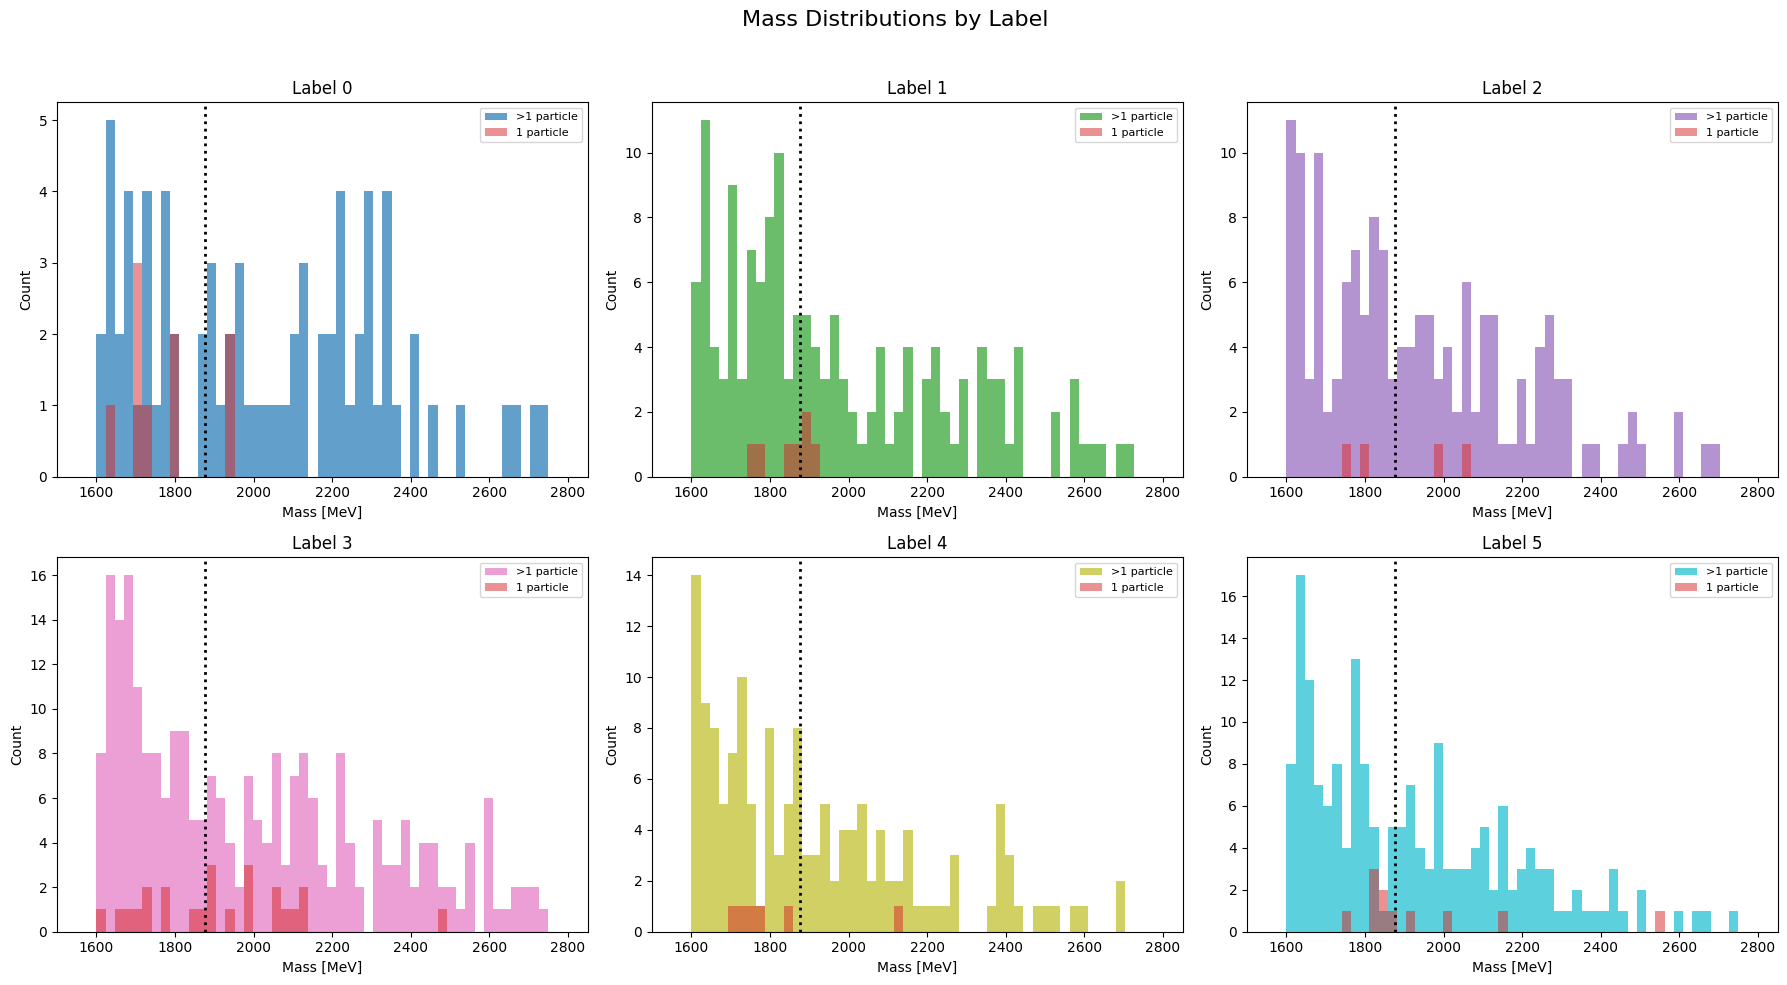

In [71]:
import math

unique_labels = np.unique(labels)

num_labels = len(unique_labels)
cmap = plt.cm.get_cmap('tab10', num_labels)  # You can also try 'tab20' or 'Set3'
label_colours = {lbl: cmap(i) for i, lbl in enumerate(unique_labels)}

# Determine subplot grid size automatically (square-like layout)
n_cols = math.ceil(math.sqrt(num_labels))
n_rows = math.ceil(num_labels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

bins = np.linspace(1600, 2750, 50)

for ax, lbl in zip(axes, unique_labels):
    mask = (labels == lbl)
    m_label = d_m[mask]
    m_label_picky = d_m[mask & (d_p == 1)]
    m_label_nonpicky = d_m[mask & (d_p == 0)]

    # Plot histograms
    ax.hist(m_label_nonpicky, bins=bins, alpha=0.7,
            color=label_colours[lbl],
            label='>1 particle')
    ax.hist(m_label_picky, bins=bins, alpha=0.5,
            color='tab:red',
            label='1 particle')

    # Deuteron mass line
    ax.axvline(1875.6, c='black', linestyle=':', linewidth=2)

    ax.set_title(f'Label {lbl}', fontsize=12)
    ax.set_xlim(1500, 2850)
    ax.set_xlabel('Mass [MeV]', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)

# Hide unused subplots (if any)
for ax in axes[len(unique_labels):]:
    ax.axis('off')

plt.suptitle('Mass Distributions by Label', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('pickyinMass.png', dpi=1000)

plt.show()


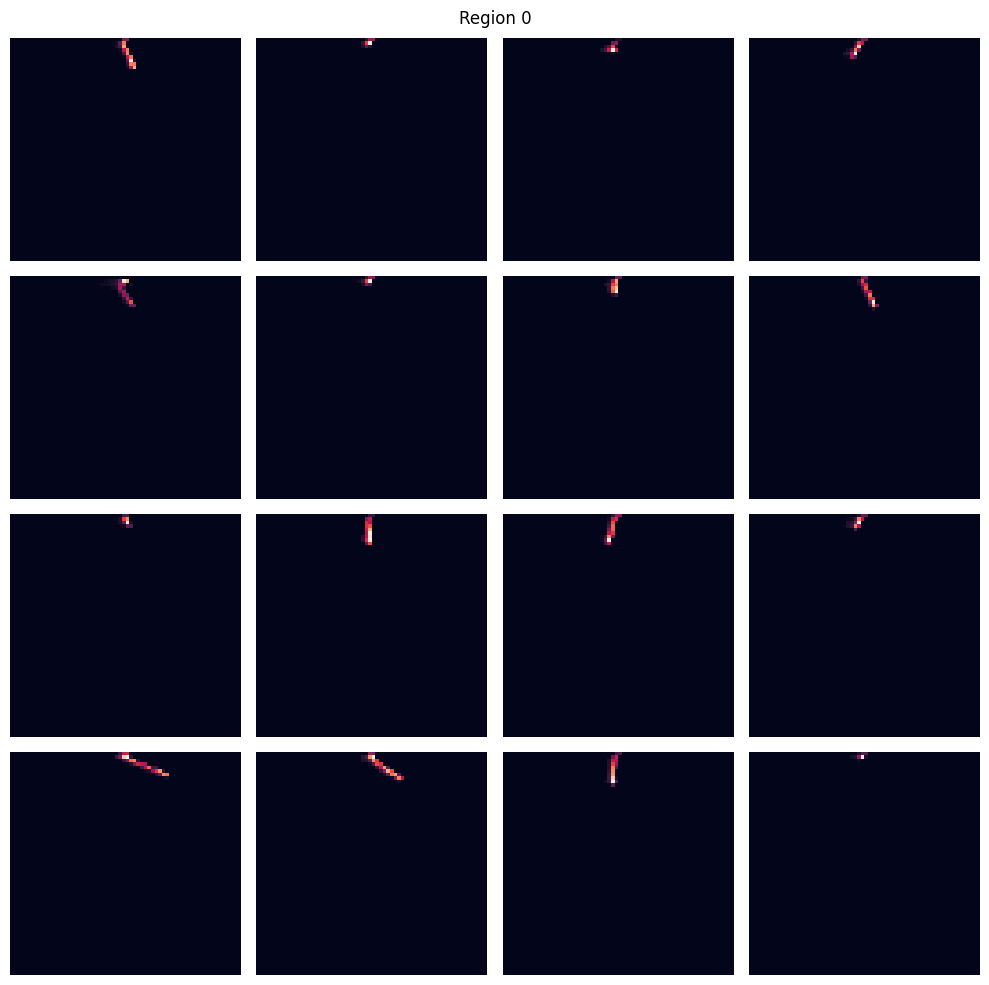

In [69]:
num_images = 16  # Number of images to display
grid_size = int(np.ceil(np.sqrt(num_images)))  # Grid dimensions (grid_size x grid_size)

# Filter the original images for the selected cluster
cluster_id = 0 # Change this to the desired cluster ID
cluster_mask = (labels_km == cluster_id)
cluster_indices = np.where(cluster_mask)[0]

# Randomly select up to `num_images` images from the cluster
if len(cluster_indices) > num_images:
    selected_indices = np.random.choice(cluster_indices, size=num_images, replace=False)
else:
    selected_indices = cluster_indices

selected_images = d[selected_indices]

fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < len(selected_images):
        sns.heatmap(selected_images[i, 1], ax=ax, cbar=False, xticklabels=False, yticklabels=False)
    else:
        ax.axis('off')  # Turn off unused subplots

fig.suptitle(f'Region {cluster_id}')
plt.tight_layout()
plt.show()

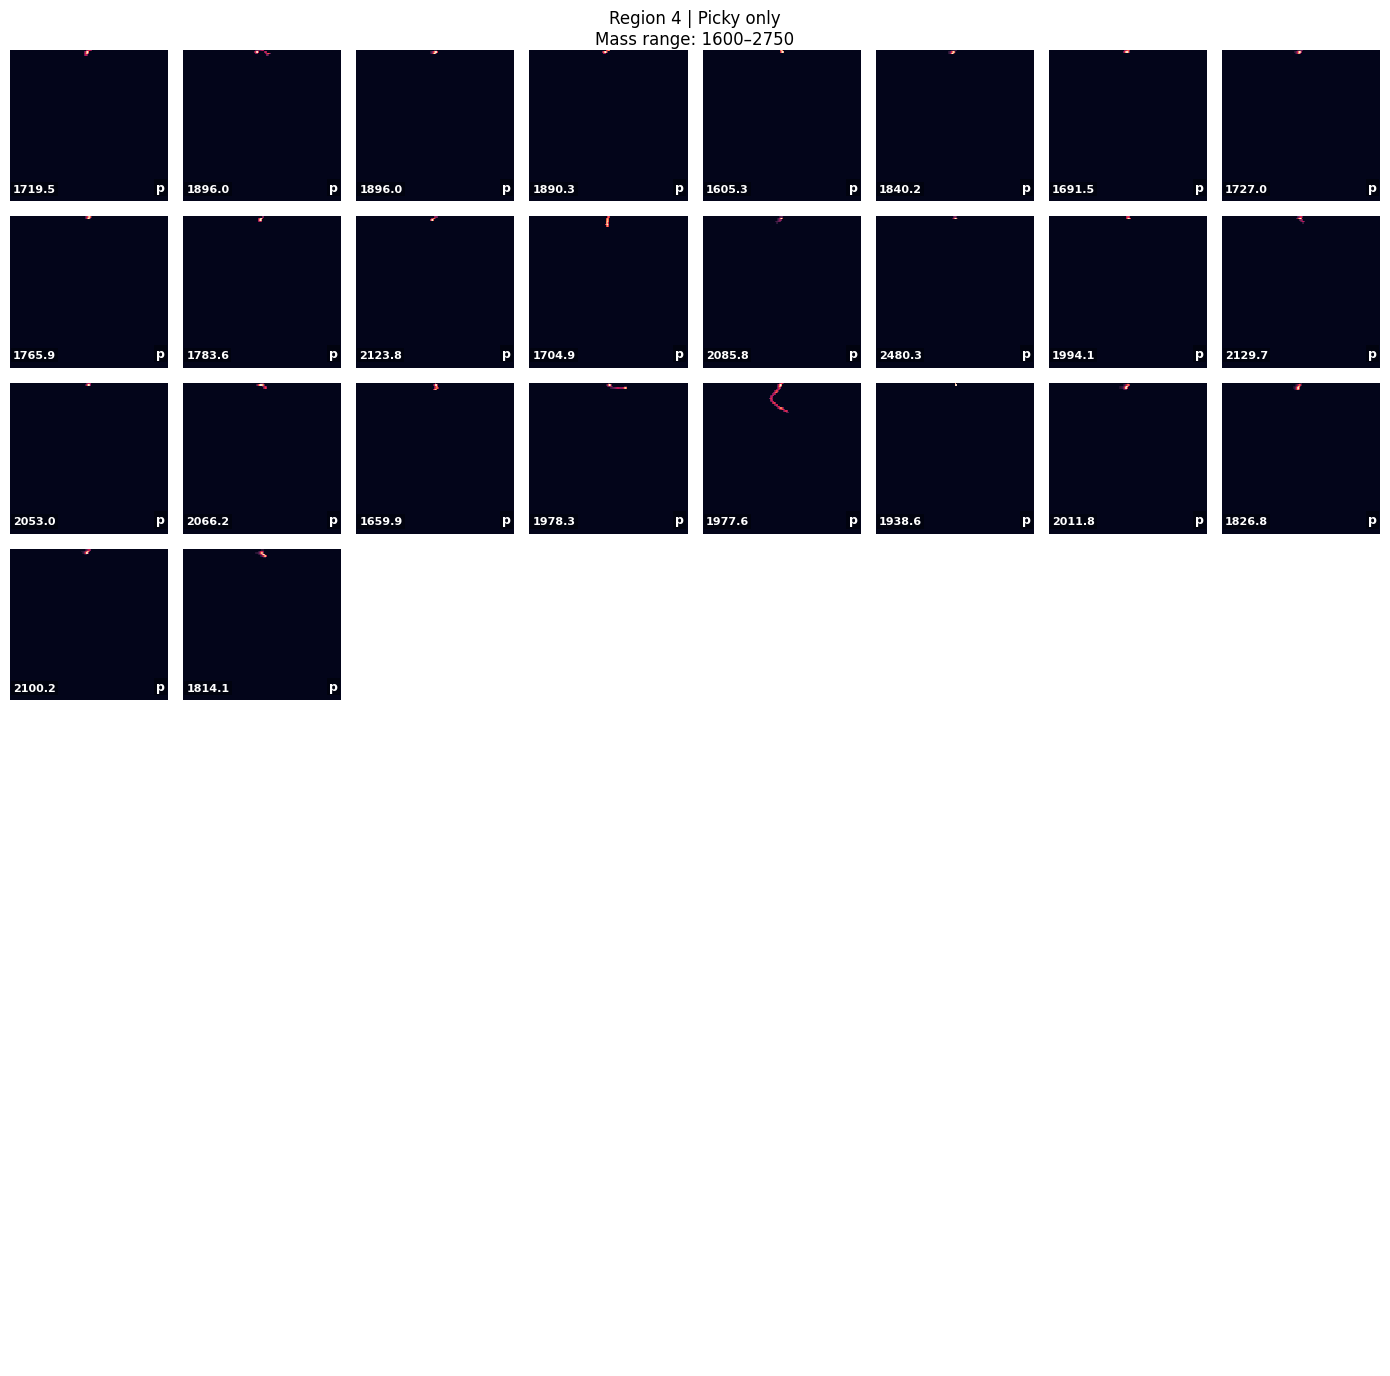

In [71]:
num_images = 64
grid_size = int(np.ceil(np.sqrt(num_images)))

# --- Selection parameters ---
cluster_id = 4
mass_min, mass_max = 1600, 2750
picky_only = True  # True = picky only, False = non-picky only, None = both

# --- Masks ---
cluster_mask = (labels_km == cluster_id)
mass_mask = (d_m >= mass_min) & (d_m <= mass_max)

if picky_only is True:
    picky_mask = (d_p == 1)
elif picky_only is False:
    picky_mask = (d_p == 0)
else:
    picky_mask = np.ones_like(d_p, dtype=bool)

combined_mask = cluster_mask & mass_mask & picky_mask
selected_indices = np.where(combined_mask)[0]

# --- Randomly select subset ---
if len(selected_indices) > num_images:
    selected_indices = np.random.choice(selected_indices, size=num_images, replace=False)

selected_images = deutimages[selected_indices]
selected_masses = d_m[selected_indices]
selected_picky = d_p[selected_indices]

# --- Plot ---
fig, axes = plt.subplots(grid_size, grid_size, figsize=(14, 14))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < len(selected_images):
        sns.heatmap(selected_images[i, 1], ax=ax, cbar=False,
                    xticklabels=False, yticklabels=False)

        # --- Annotate mass (bottom-left) ---
        ax.text(0.02, 0.05, f"{selected_masses[i]:.1f}",
                transform=ax.transAxes,
                fontsize=8, color='white', ha='left', va='bottom',
                fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1.5))

        # --- Annotate 'p' if picky (bottom-right) ---
        if selected_picky[i] == 1:
            ax.text(0.98, 0.05, 'p',
                    transform=ax.transAxes,
                    fontsize=9, color='white', ha='right', va='bottom',
                    fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1.5))
    else:
        ax.axis('off')

# --- Title ---
sel_type = (
    "Picky only" if picky_only is True else
    "Non-picky only" if picky_only is False else
    "All events"
)
fig.suptitle(f"Region {cluster_id} | {sel_type}\nMass range: {mass_min}–{mass_max}",
             fontsize=12)
plt.tight_layout()
plt.show()

In [60]:
# cluster_id = 3

# cluster_mask = (labels_km == cluster_id)
# cluster_indices = np.where(cluster_mask)[0]
# print(f"Cluster {cluster_id}: {len(cluster_indices)} samples")

# filtered_idx = cluster_indices[(RE_per_sample_d[cluster_indices] >= 0) &
#                                (RE_per_sample_d[cluster_indices] < 3000)]

# print(f"Filtered: {len(filtered_idx)} samples with RE in range")

# k = min(10, len(filtered_idx))
# if k == 0:
#     print(f"No samples found in cluster {cluster_id} with RE in range.")
# else:
#     selected = np.random.choice(filtered_idx, size=k, replace=False)

#     fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
#     for ii in range(k):
#         idx = selected[ii]
#         axs[ii, 0].imshow(Xd_np[idx], cmap='viridis', aspect='auto')
#         axs[ii, 0].set_title(f"Original (idx={idx}, RE={RE_per_sample_d[idx]:.1f})")
#         axs[ii, 0].axis('off')

#         axs[ii, 1].imshow(recon_all[idx], cmap='viridis', aspect='auto')
#         axs[ii, 1].set_title("Reconstruction")
#         axs[ii, 1].axis('off')

#     plt.tight_layout()
#     plt.show()

Deuteron subset shape: (2421, 2)


/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_66328/859799654.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = plt.scatter(E_d[:, 0], E_d[:, 1], cmap='tab10', s=5, alpha=0.8)


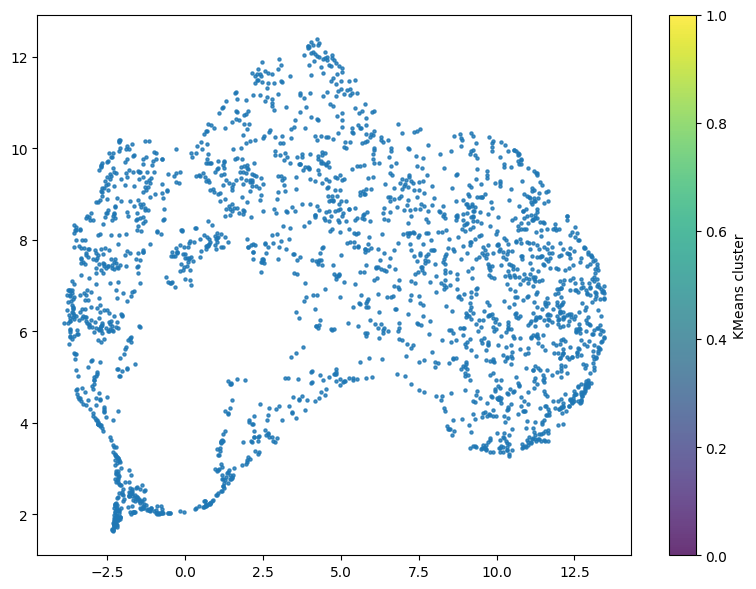

In [72]:
Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_d)),         # 1 = deuterons
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

mask = (labels == 1)
Z_d = Z_all[mask]          # latent vectors
E_d = Z_umap[mask]      # 3D UMAP coordinates

print(f"Deuteron subset shape: {E_d.shape}")


fig = plt.figure(figsize=(8, 6))
sc = plt.scatter(E_d[:, 0], E_d[:, 1], cmap='tab10', s=5, alpha=0.8)
plt.colorbar(label='KMeans cluster')
ax.set_title("Deuteron candidates — KMeans clusters")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()


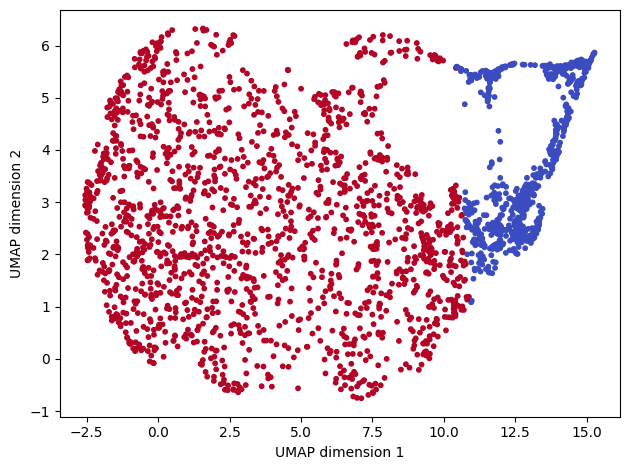

In [62]:

# Example: UMAP coordinates
x = E_d[:, 0]
y = E_d[:, 1]

# Define your line: y = m*x + c
m = -10    # slope
c = 110    # intercept

# Compute which side each point is on
side = y < (m * x + c)
labels = side.astype(int)   # 0 or 1 cluster assignment

# Plot
# plt.figure(figsize=(7, 5))
plt.scatter(x, y, c=labels, cmap='coolwarm', s=10)
# plt.plot(x, m*x + c, 'k--', linewidth=2, label='Manual boundary')
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
# plt.legend()
plt.tight_layout()
plt.savefig('linear.png', dpi=1000)
plt.show()


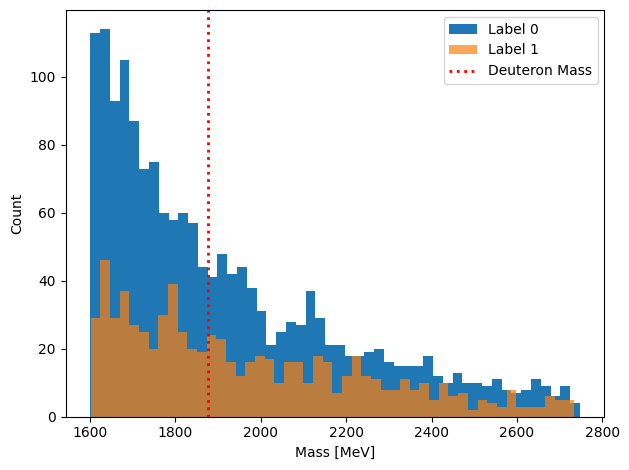

In [63]:
mass_0 = d_m[(labels == 1)]
mass_1 = d_m[(labels == 0)]

# Plot
plt.hist(mass_0, bins=50, alpha=1.0, label='Label 0', color='tab:blue')
plt.hist(mass_1, bins=50, alpha=0.7, label='Label 1', color='tab:orange')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')

plt.xlabel('Mass [MeV]')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('linearcut.png', dpi=1000)
plt.show()

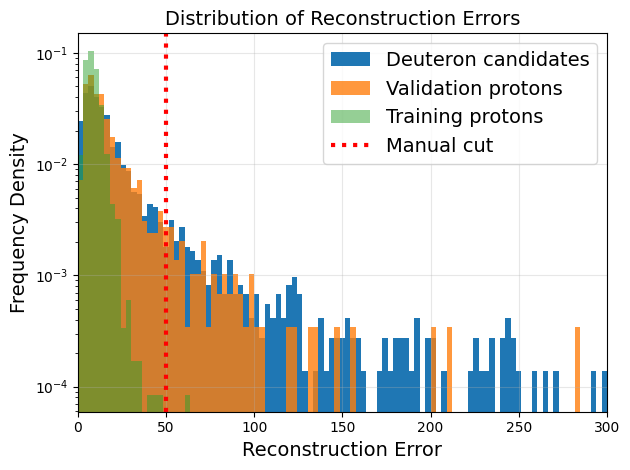

In [64]:
# plt.figure(figsize=(12, 7))

bins = np.linspace(0, 300, 100)

plt.hist(RE_per_sample_d, bins=bins, alpha=1, label='Deuteron candidates', density=True)
plt.hist(RE_per_sample_val, bins=bins, alpha=0.8, label='Validation protons', density=True)
plt.hist(RE_per_sample, bins=bins, alpha=0.5, label='Training protons', density=True)

plt.axvline(50, linewidth=3, linestyle=":", c='red', label='Manual cut')

plt.xlabel("Reconstruction Error", fontsize=14)
plt.ylabel("Frequency Density", fontsize=14)
plt.title("Distribution of Reconstruction Errors", fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(0, 300)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig('reconerror.png', dpi=1000)
plt.show()

In [65]:
unique, counts = np.unique(labels, return_counts=True)
unique, counts

(array([0, 1]), array([ 738, 1683]))

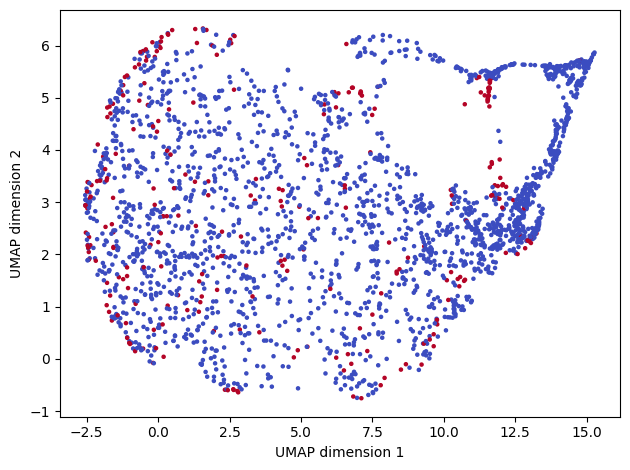

In [66]:
labels = RE_per_sample_d > 50

x = E_d[:, 0]
y = E_d[:, 1]

plt.scatter(x, y, c=labels, cmap='coolwarm', s=5)
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.tight_layout()
plt.show()


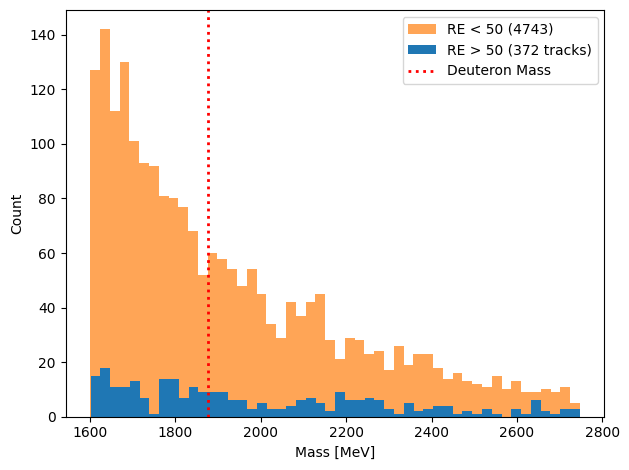

In [67]:
mass_0 = d_m[(labels == 1)]
mass_1 = d_m[(labels == 0)]

# Plot

plt.hist(mass_1, bins=50, alpha=0.7, label='RE < 50 (4743)', color='tab:orange')
plt.hist(mass_0, bins=50, alpha=1.0, label='RE > 50 (372 tracks)', color='tab:blue')
plt.axvline(1875.6, c='red', linestyle=':', linewidth=2, label='Deuteron Mass')

plt.xlabel('Mass [MeV]')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('REcutSeparation.png', dpi=1000)
plt.show()

# ANGLE PROXY

<Axes: >

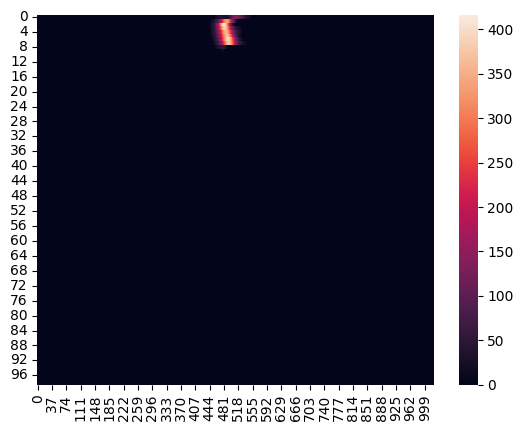

In [186]:
sns.heatmap(p_c[1])

In [187]:
height = col[col['particle_type'] == 'proton'].iloc[1]['height']
height

np.int64(10)

In [188]:
a = p_c[1]
start = np.argmax(a[0,:])
end = np.argmax(a[34,:])

In [189]:
end

np.int64(0)

In [205]:
theta = np.arctan((start - end) / height)
theta = np.degrees(theta)
theta

np.float64(88.88108406943282)

In [206]:
images = []

for idx, row in col.iterrows():
    padded = pad_image(
        row['image_intensity'])
    images.append(padded)

ind_images = []

for idx, row in ind.iterrows():
    padded = pad_image(
        row['image_intensity'])
    ind_images.append(padded)

In [207]:
heights = col['height'].values
starts = np.array([np.argmax(img[0,:]) for img in images])
ends = np.array([np.argmax(img[h-1, :]) for img, h in zip(images, heights)])

thetas = np.arctan((starts - ends) / heights)
thetas = np.degrees(thetas)

col['thetas'] = thetas

In [208]:
heights = ind['height'].values
starts = np.array([np.argmax(img[0,:]) for img in images])
ends = np.array([np.argmax(img[h-1, :]) for img, h in zip(images, heights)])

thetas = np.arctan((starts - ends) / heights)
thetas = np.degrees(thetas)

ind['thetas'] = thetas

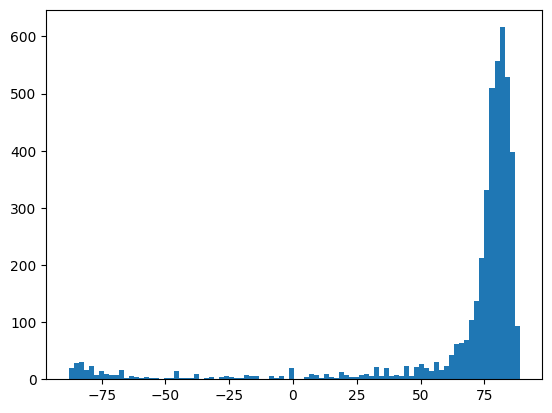

In [239]:
hist = plt.hist(col['thetas'], bins=90)

In [240]:


idx = np.argmax(hist[0])

# mode estimate = centre of the bin with highest count
most_common_theta = (hist[1][idx] + hist[1][idx+1]) / 2

most_common_theta

np.float64(81.94182130742466)

# SCORING DEUTERON CANDIDATES

Using the picky deuterons 

In [72]:
i = np.where((d_p == 1) & ((labels == 0) | (labels == 3)))[0]
len(i)

33

In [73]:
labels[i]

array([3, 0, 0, 0, 3, 3, 3, 0, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0,
       3, 0, 3, 3, 3, 3, 0, 0, 3, 3, 3], dtype=int32)

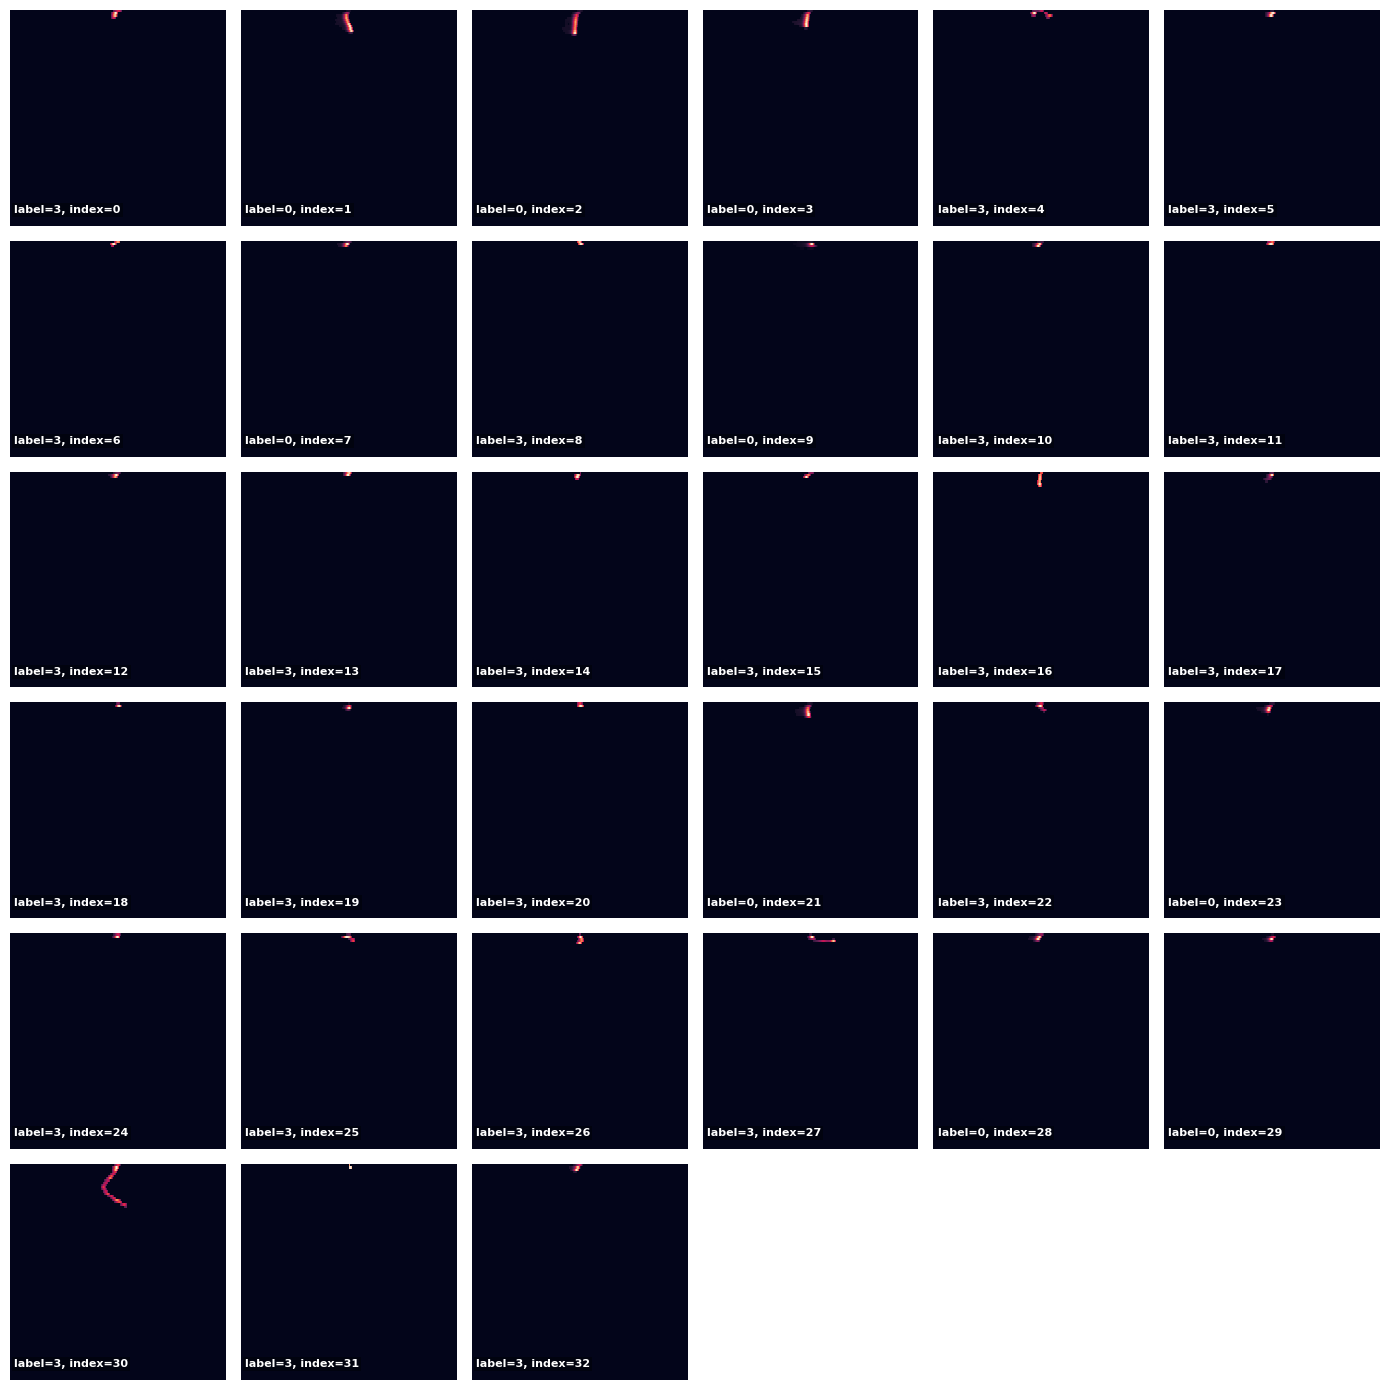

In [74]:
num_images = len(i) 
grid_size = int(np.ceil(np.sqrt(num_images)))

selected_images = deutimages[i]
selected_labels = labels[i]

fig, axes = plt.subplots(grid_size, grid_size, figsize=(14, 14))

for img in range(grid_size * grid_size):
    ax = axes[img // grid_size, img % grid_size]
    if img < len(selected_images):
        sns.heatmap(selected_images[img, 1], ax=ax, cbar=False, xticklabels=False, yticklabels=False)
        ax.text(0.02, 0.05, f"label={selected_labels[img]:.0f}, index={img}",
            transform=ax.transAxes,
            fontsize=8, color='white', ha='left', va='bottom',
            fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1.5))
    else:
        ax.axis('off')  # Turn off unused subplots

        

plt.tight_layout()
plt.show()

In [75]:
d_p.shape

(1014,)

In [76]:
labels.shape

(1014,)

In [77]:
latent_vectors_d.shape

(1014, 16)

In [78]:
l = latent_vectors_d[i]
l.shape

(33, 16)

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import IsolationForest

Mean per dimension: [ 3.8776996   0.59254557  9.252487    3.482664   -3.3621793   1.2386203
 -1.059761    3.1409583   9.203646    6.6735363   2.4877734  13.70341
  8.372917    5.59911    15.921432   -4.709255  ]
Variance per dimension: [ 91.04252   46.56642   80.011406  35.406918  29.93487  154.41158
   9.922264  29.172394 238.88371   70.38123   39.260555 174.6485
  33.55006   42.35585  211.59322   33.106327]
Average variance across dimensions: 82.51549


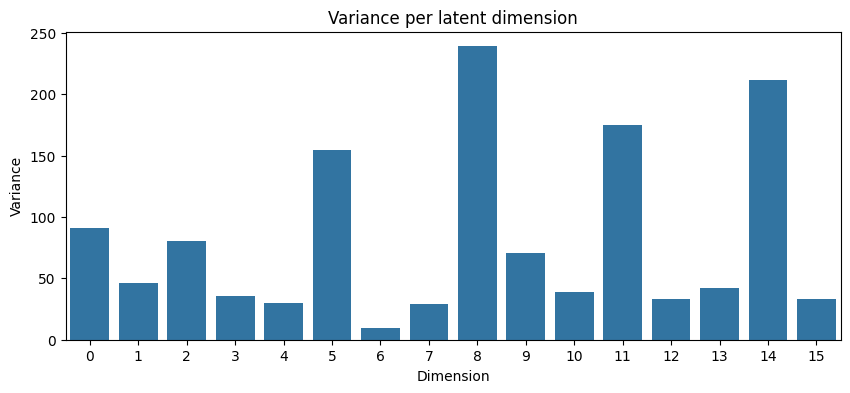

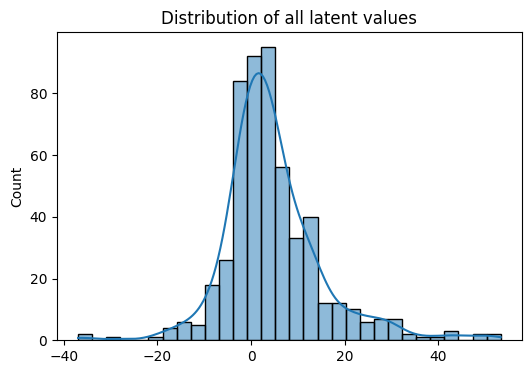

In [80]:
# Per-dimension statistics
means = l.mean(axis=0)
stds = l.std(axis=0)
variances = l.var(axis=0)

# Summary
print("Mean per dimension:", means)
print("Variance per dimension:", variances)
print("Average variance across dimensions:", np.mean(variances))

# Visualise variance
plt.figure(figsize=(10, 4))
sns.barplot(x=np.arange(16), y=variances)
plt.title("Variance per latent dimension")
plt.xlabel("Dimension")
plt.ylabel("Variance")
plt.show()

# Optional: Distribution across all numbers
plt.figure(figsize=(6,4))
sns.histplot(l.flatten(), bins=30, kde=True)
plt.title("Distribution of all latent values")
plt.show()


Mean per dimension: [  1.9687189    3.3825722    3.989056     0.55112785 -10.8142395
   3.3265097   -1.1794142    0.455413     4.286151    -7.1609263
   2.995817     5.1967063    5.6115627  -10.680913     7.6241956
   8.263992  ]
Variance per dimension: [148.37138  176.37697  226.32562  142.28937  232.24377  233.43486
  53.622948  82.31683  284.9436   194.69608  192.64195  284.545
 170.03784  326.15216  344.4489   299.6418  ]
Average variance across dimensions: 212.00558


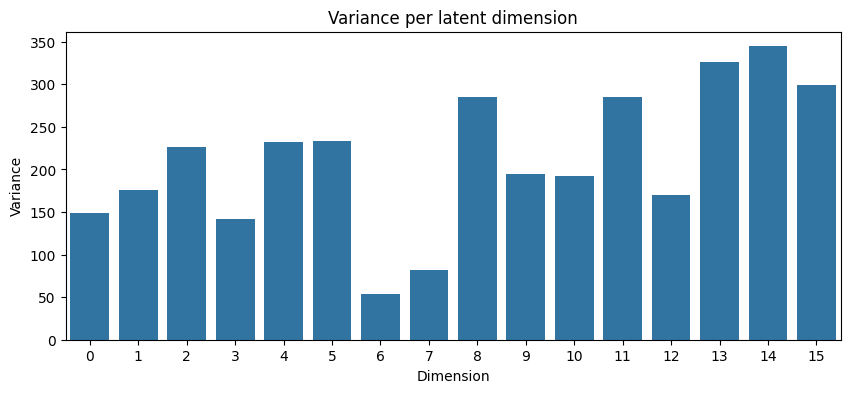

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


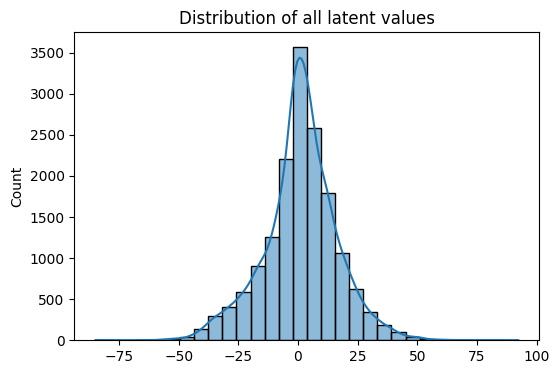

In [81]:
# Per-dimension statistics
means = latent_vectors_d.mean(axis=0)
stds = latent_vectors_d.std(axis=0)
variances = latent_vectors_d.var(axis=0)

# Summary
print("Mean per dimension:", means)
print("Variance per dimension:", variances)
print("Average variance across dimensions:", np.mean(variances))

# Visualise variance
plt.figure(figsize=(10, 4))
sns.barplot(x=np.arange(16), y=variances)
plt.title("Variance per latent dimension")
plt.xlabel("Dimension")
plt.ylabel("Variance")
plt.show()

# Optional: Distribution across all numbers
plt.figure(figsize=(6,4))
sns.histplot(latent_vectors_d.flatten(), bins=30, kde=True)
plt.title("Distribution of all latent values")
plt.show()


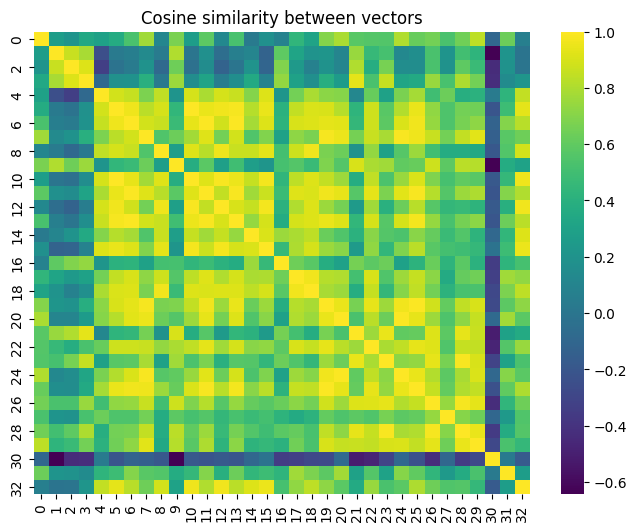

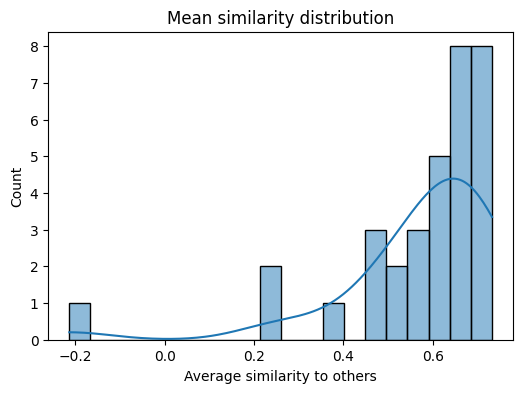

In [82]:
# Compute pairwise cosine similarity
similarity_matrix = cosine_similarity(l)

# Show as heatmap
plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, cmap="viridis")
plt.title("Cosine similarity between vectors")
plt.show()

# Mean similarity per vector (to see which are unusual)
mean_sim = similarity_matrix.mean(axis=1)
plt.figure(figsize=(6,4))
sns.histplot(mean_sim, bins=20, kde=True)
plt.title("Mean similarity distribution")
plt.xlabel("Average similarity to others")
plt.show()


In [83]:
remove = np.where(mean_sim < 0.5)[0]
print(remove)
len(remove)

[ 0  1  2  3 16 30 31]


7

In [84]:
f = i[43]

IndexError: index 43 is out of bounds for axis 0 with size 33

In [85]:
sns.heatmap(deutimages[f][0])

NameError: name 'f' is not defined

In [86]:
i = np.delete(i, remove)
len(i)

26

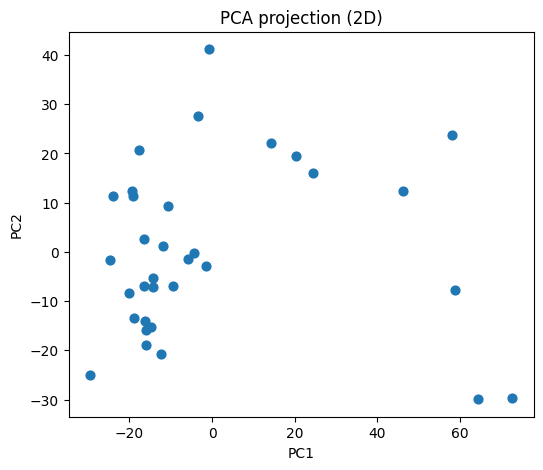

Explained variance ratio: [0.5955482  0.22075145]


In [87]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(l)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=40)
plt.title("PCA projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


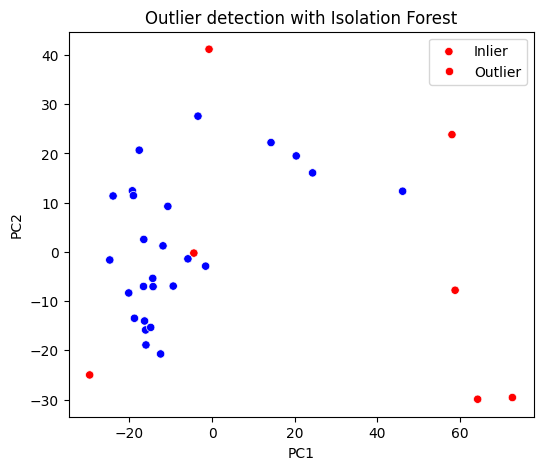

Outlier indices: [ 0  1  2  3  7  9 30]


In [88]:
iso = IsolationForest(contamination=0.2, random_state=1)
outlier_labels = iso.fit_predict(l)

# Visualise outliers in PCA space
plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=outlier_labels, palette={1:'blue', -1:'red'})
plt.title("Outlier detection with Isolation Forest")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(["Inlier", "Outlier"])
plt.show()

# Get indices of suspected outliers
outlier_indices = np.where(outlier_labels == -1)[0]
print("Outlier indices:", outlier_indices)


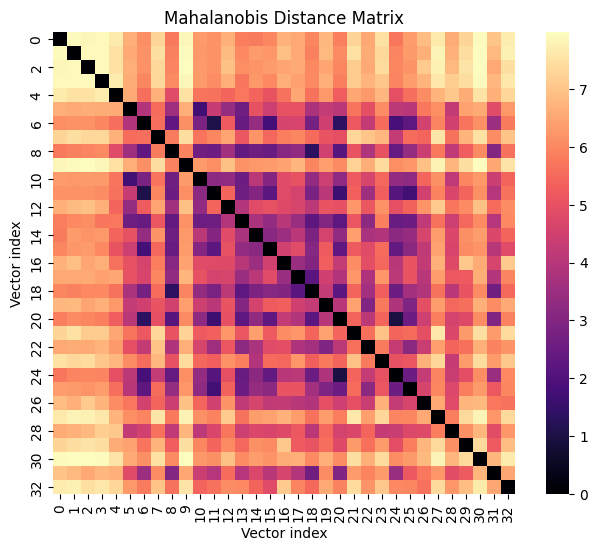

In [89]:
import numpy as np
from scipy.spatial import distance
import seaborn as sns
import matplotlib.pyplot as plt

# Assume latent_vectors is (87, 16)
cov = np.cov(l, rowvar=False)
inv_cov = np.linalg.inv(cov)

# Compute full pairwise distance matrix
n = l.shape[0]
mahal_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        mahal_matrix[i, j] = distance.mahalanobis(l[i], l[j], inv_cov)

plt.figure(figsize=(8,6))
sns.heatmap(mahal_matrix, cmap="magma", square=True)
plt.title("Mahalanobis Distance Matrix")
plt.xlabel("Vector index")
plt.ylabel("Vector index")
plt.show()


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


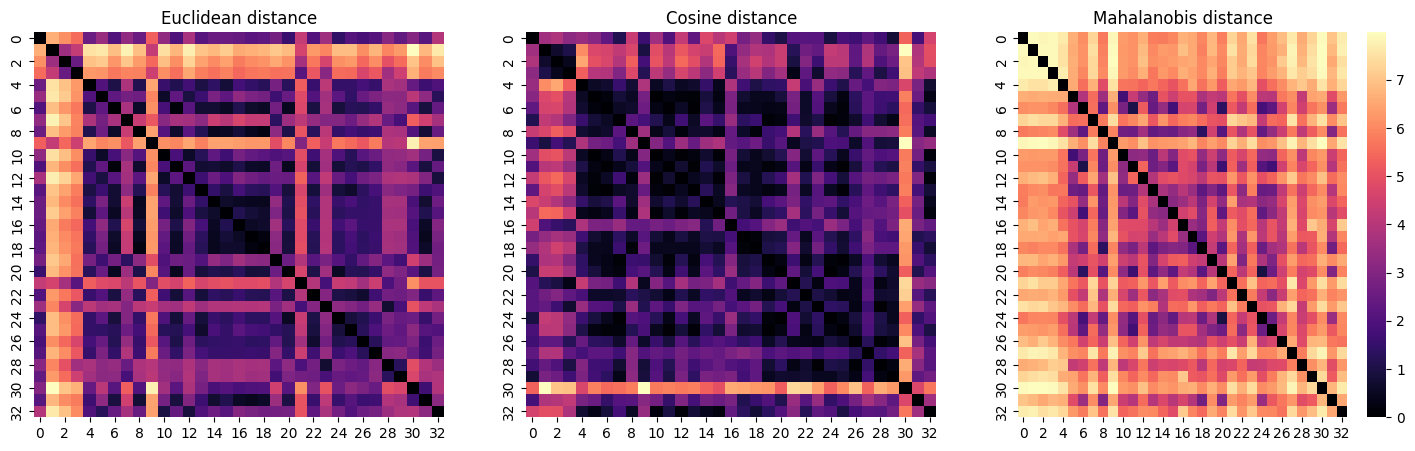

In [90]:
from sklearn.metrics import pairwise_distances

eucl = pairwise_distances(l, metric='euclidean')
cos = pairwise_distances(l, metric='cosine')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(eucl, ax=axes[0], cmap="magma", cbar=False)
axes[0].set_title("Euclidean distance")

sns.heatmap(cos, ax=axes[1], cmap="magma", cbar=False)
axes[1].set_title("Cosine distance")

sns.heatmap(mahal_matrix, ax=axes[2], cmap="magma")
axes[2].set_title("Mahalanobis distance")

plt.show()

In [91]:
latent_vectors_d.shape

(1014, 16)

In [92]:
l.shape

(33, 16)

In [93]:
from sklearn.covariance import LedoitWolf
from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import chi2

def fit_covariance(Z, use_shrinkage=True):
    """
    Z: (T, D) array used to estimate covariance (ideally many latents; can be refs+queries).
    Returns (mu, precision) where precision = Σ^{-1}.
    """
    mu = Z.mean(axis=0)
    X = Z - mu
    if use_shrinkage:
        est = LedoitWolf().fit(X)
        Sigma = est.covariance_
    else:
        Sigma = np.cov(X, rowvar=False)
    # precision
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    # numerical guard
    eigvals = np.maximum(eigvals, 1e-8)
    precision = (eigvecs @ np.diag(1.0 / eigvals) @ eigvecs.T)
    return mu, precision

def pairwise_mahalanobis2(queries, refs, precision, centre=None):
    """
    Vectorised squared Mahalanobis distances between every query and reference.
    queries: (M,D), refs: (N,D), precision: (D,D).
    centre: optional mean to subtract from both sets (use the mean from fit_covariance).
    Returns D2: (M,N)
    """
    Q = queries if centre is None else (queries - centre)
    R = refs    if centre is None else (refs - centre)
    QP = Q @ precision               # (M,D)
    RP = R @ precision               # (N,D)
    q_quad = np.sum(QP * Q, axis=1)  # (M,)
    r_quad = np.sum(RP * R, axis=1)  # (N,)
    cross  = QP @ R.T                # (M,N)
    D2 = q_quad[:, None] + r_quad[None, :] - 2.0 * cross
    # numerical noise may make tiny negatives—clip
    np.maximum(D2, 0.0, out=D2)
    return D2

def score_against_references(
    refs, queries, cov_fit='all', also_cosine=True
):
    """
    refs:    (N, D) = 24 x 16
    queries: (M, D) = 2529 x 16
    cov_fit: 'all' uses refs+queries to fit Σ; 
             'refs' uses only the 24 refs (OK but less stable);
             or pass a precomputed array to fit on (e.g. training latents).
    Returns a dict of useful outputs.
    """
    D = refs.shape[1]
    if isinstance(cov_fit, str):
        if cov_fit == 'all':
            Z_for_cov = np.vstack([refs, queries])
        elif cov_fit == 'refs':
            Z_for_cov = refs
        else:
            raise ValueError("cov_fit must be 'all', 'refs', or an array.")
    else:
        Z_for_cov = np.asarray(cov_fit)

    mu, P = fit_covariance(Z_for_cov, use_shrinkage=True)

    # Squared Mahalanobis distances M x N
    D2_maha = pairwise_mahalanobis2(queries, refs, P, centre=mu)

    # Per-query best (nearest) reference
    nn_idx = np.argmin(D2_maha, axis=1)
    nn_d2  = D2_maha[np.arange(D2_maha.shape[0]), nn_idx]

    # χ² p-values for interpretability (df = D)
    p_vals = 1.0 - chi2.cdf(nn_d2, df=D)  # small p => unusually far

    out = {
        "D2_maha": D2_maha,
        "nearest_ref_index": nn_idx,
        "nearest_maha_d2": nn_d2,
        "nearest_p_value": p_vals,
    }

    if also_cosine:
        # Cosine distances (direction only). Optionally centre/whiten first if desired.
        D_cos = cosine_distances(queries, refs)  # M x N
        nn_idx_cos = np.argmin(D_cos, axis=1)
        nn_cos = D_cos[np.arange(D_cos.shape[0]), nn_idx_cos]
        out.update({
            "D_cos": D_cos,
            "nearest_ref_index_cos": nn_idx_cos,
            "nearest_cos_dist": nn_cos
        })

    return out


In [94]:
# refs: (24,16)  your reference latent vectors
# queries: (2529,16)  the vectors to score

res = score_against_references(l, latent_vectors_d, cov_fit='all', also_cosine=True)

# Per-query best match (Mahalanobis)
nearest_ref = res["nearest_ref_index"]      # (2529,)
best_d2     = res["nearest_maha_d2"]        # squared distance
p_values    = res["nearest_p_value"]        # small p => unusual w.r.t. Σ

# Example: flag queries that are unlikely under the reference distribution
alpha = 0.01
anomalous_mask = p_values < alpha
anomalous_indices = np.where(anomalous_mask)[0]

# If you also want cosine-based nearest
nearest_ref_cos = res["nearest_ref_index_cos"]
best_cos        = res["nearest_cos_dist"]


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: overflow encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: invalid value encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_14403/746596412.py:21: RuntimeWarning: divide by zero encountered in matmul
  precision = (eigvecs @ np.diag(1.0 / eigvals) @ eigvecs.T)
/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_14403/746596412.py:21: RuntimeWarning: overflow encountered in matmul
  precision = (eigvecs @ np.diag(1.0 / eigvals) @ eigvecs.T)
/var/folders/cm/m55y72dj6cd5lkwrf

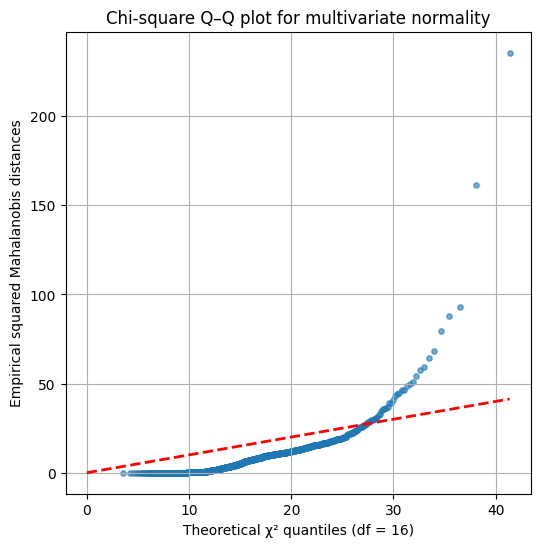

In [95]:
X = latent_vectors_d

mu = X.mean(axis=0)
Sigma = np.cov(X, rowvar=False)

D2 = best_d2  # efficient (x-μ)^T Σ⁻¹ (x-μ)

n, D = len(D2), X.shape[1]
D2_sorted = np.sort(D2)
quantiles = chi2.ppf((np.arange(1, n+1) - 0.5) / n, df=16)

plt.figure(figsize=(6,6))
plt.scatter(quantiles, D2_sorted, s=15, alpha=0.6)
plt.plot([0, max(quantiles)], [0, max(quantiles)], 'r--', lw=2)
plt.xlabel('Theoretical χ² quantiles (df = {})'.format(D))
plt.ylabel('Empirical squared Mahalanobis distances')
plt.title('Chi-square Q–Q plot for multivariate normality')
plt.grid(True)
plt.show()


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.

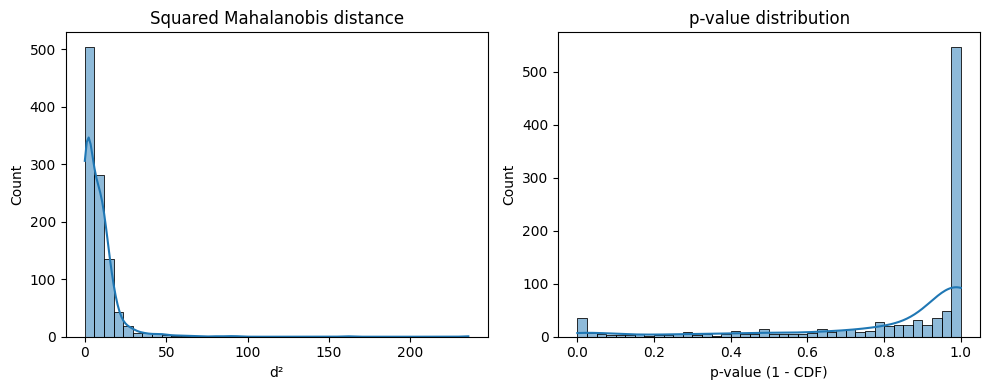

In [96]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(best_d2, bins=40, ax=ax[0], kde=True)
ax[0].set_title("Squared Mahalanobis distance")
ax[0].set_xlabel("d²")
ax[0].set_ylabel("Count")

sns.histplot(p_values, bins=40, ax=ax[1], kde=True)
ax[1].set_title("p-value distribution")
ax[1].set_xlabel("p-value (1 - CDF)")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11

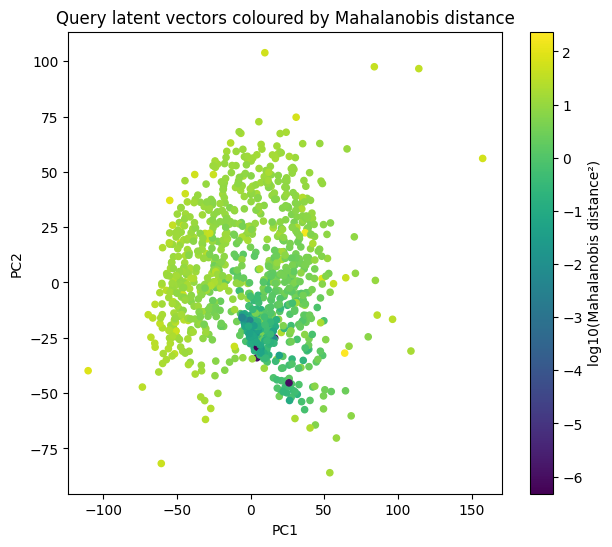

In [97]:
X = latent_vectors_d  # your 2529 queries
pca = PCA(n_components=2)
X2d = pca.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(X2d[:,0], X2d[:,1], c=np.log10(best_d2), cmap="viridis", s=20)
plt.colorbar(label="log10(Mahalanobis distance²)")
plt.title("Query latent vectors coloured by Mahalanobis distance")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11

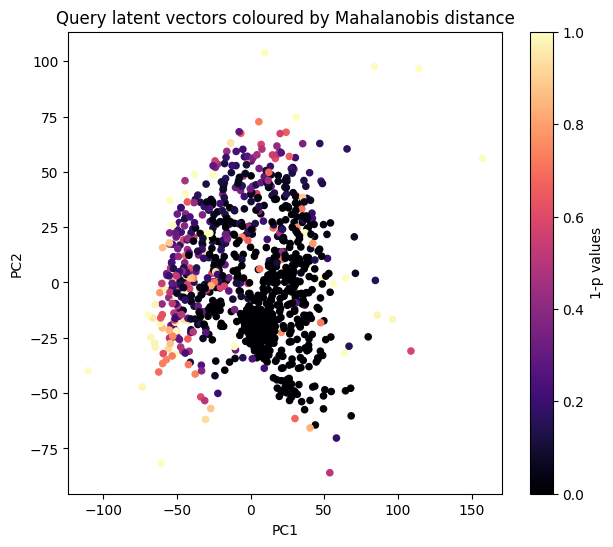

In [98]:
from sklearn.decomposition import PCA

X = latent_vectors_d  # your 2529 queries
pca = PCA(n_components=2)
X2d = pca.fit_transform(X)

plt.figure(figsize=(7,6))
plt.scatter(X2d[:,0], X2d[:,1], c=1-p_values, cmap="magma", s=20)
plt.colorbar(label="1-p values")
plt.title("Query latent vectors coloured by Mahalanobis distance")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


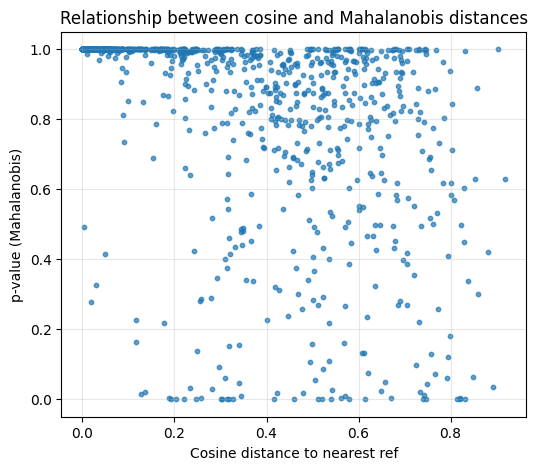

In [99]:
plt.figure(figsize=(6,5))
plt.scatter(best_cos, p_values, s=10, alpha=0.7)
plt.xlabel("Cosine distance to nearest ref")
plt.ylabel("p-value (Mahalanobis)")
plt.title("Relationship between cosine and Mahalanobis distances")
plt.grid(True, alpha=0.3)
plt.show()


In [100]:
print(f"Median Mahalanobis distance²: {np.median(best_d2):.2f}")
print(f"5th–95th percentile: {np.percentile(best_d2,[5,95])}")
print(f"Fraction of queries flagged as anomalies (p<0.01): {(p_values<0.01).mean()*100:.1f}%")


Median Mahalanobis distance²: 5.94
5th–95th percentile: [ 0.0318033  23.42669725]
Fraction of queries flagged as anomalies (p<0.01): 2.8%


33 reference vectors detected inside queries.
Lowest Mahalanobis (non-ref): [ 989 1008  415  527 1005  106  145  799  180  496  150  438  829  974
   61  267  654  807  489  171  566  338  610  164  993  939  343  152
  418  734  910   94]
Highest Mahalanobis (non-ref): [ 37 788 159 500 190  86 386 879 470 721 349 696 282 947 483 366 949 872
 631 387 731 532 627 409 932 376 167 310 472 239 624 120]


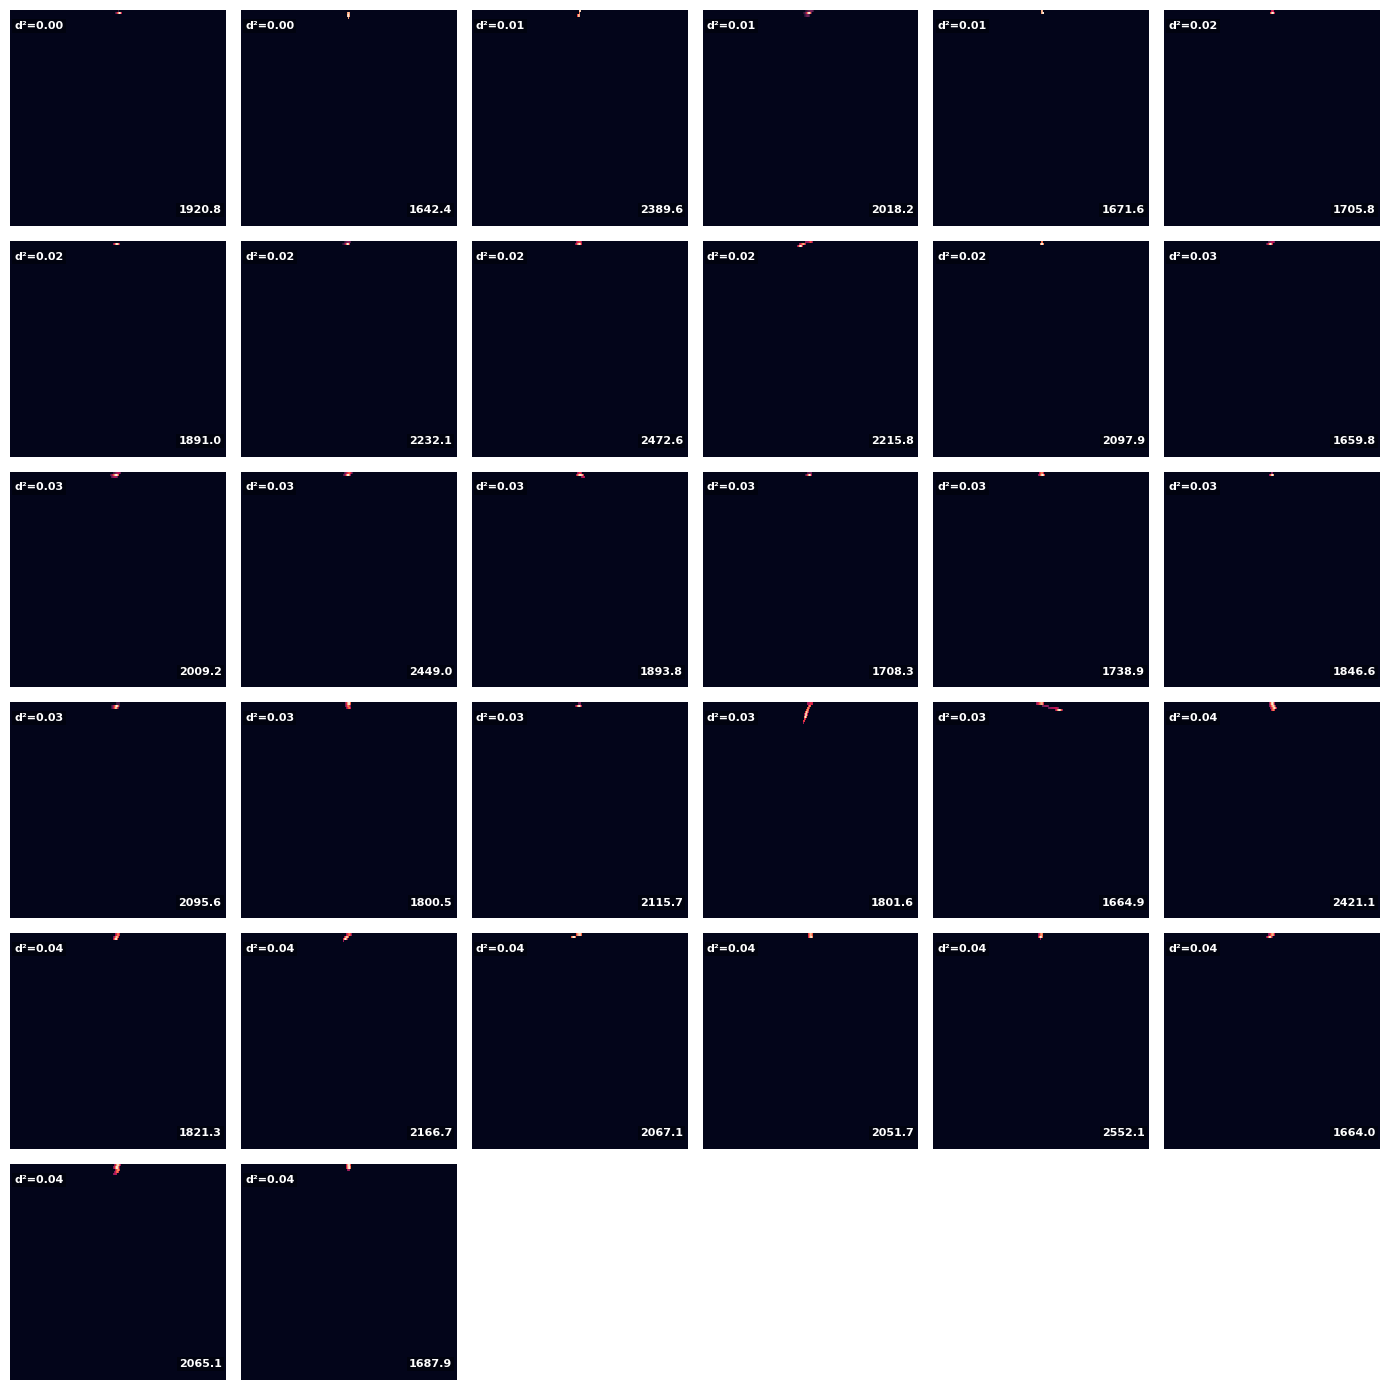

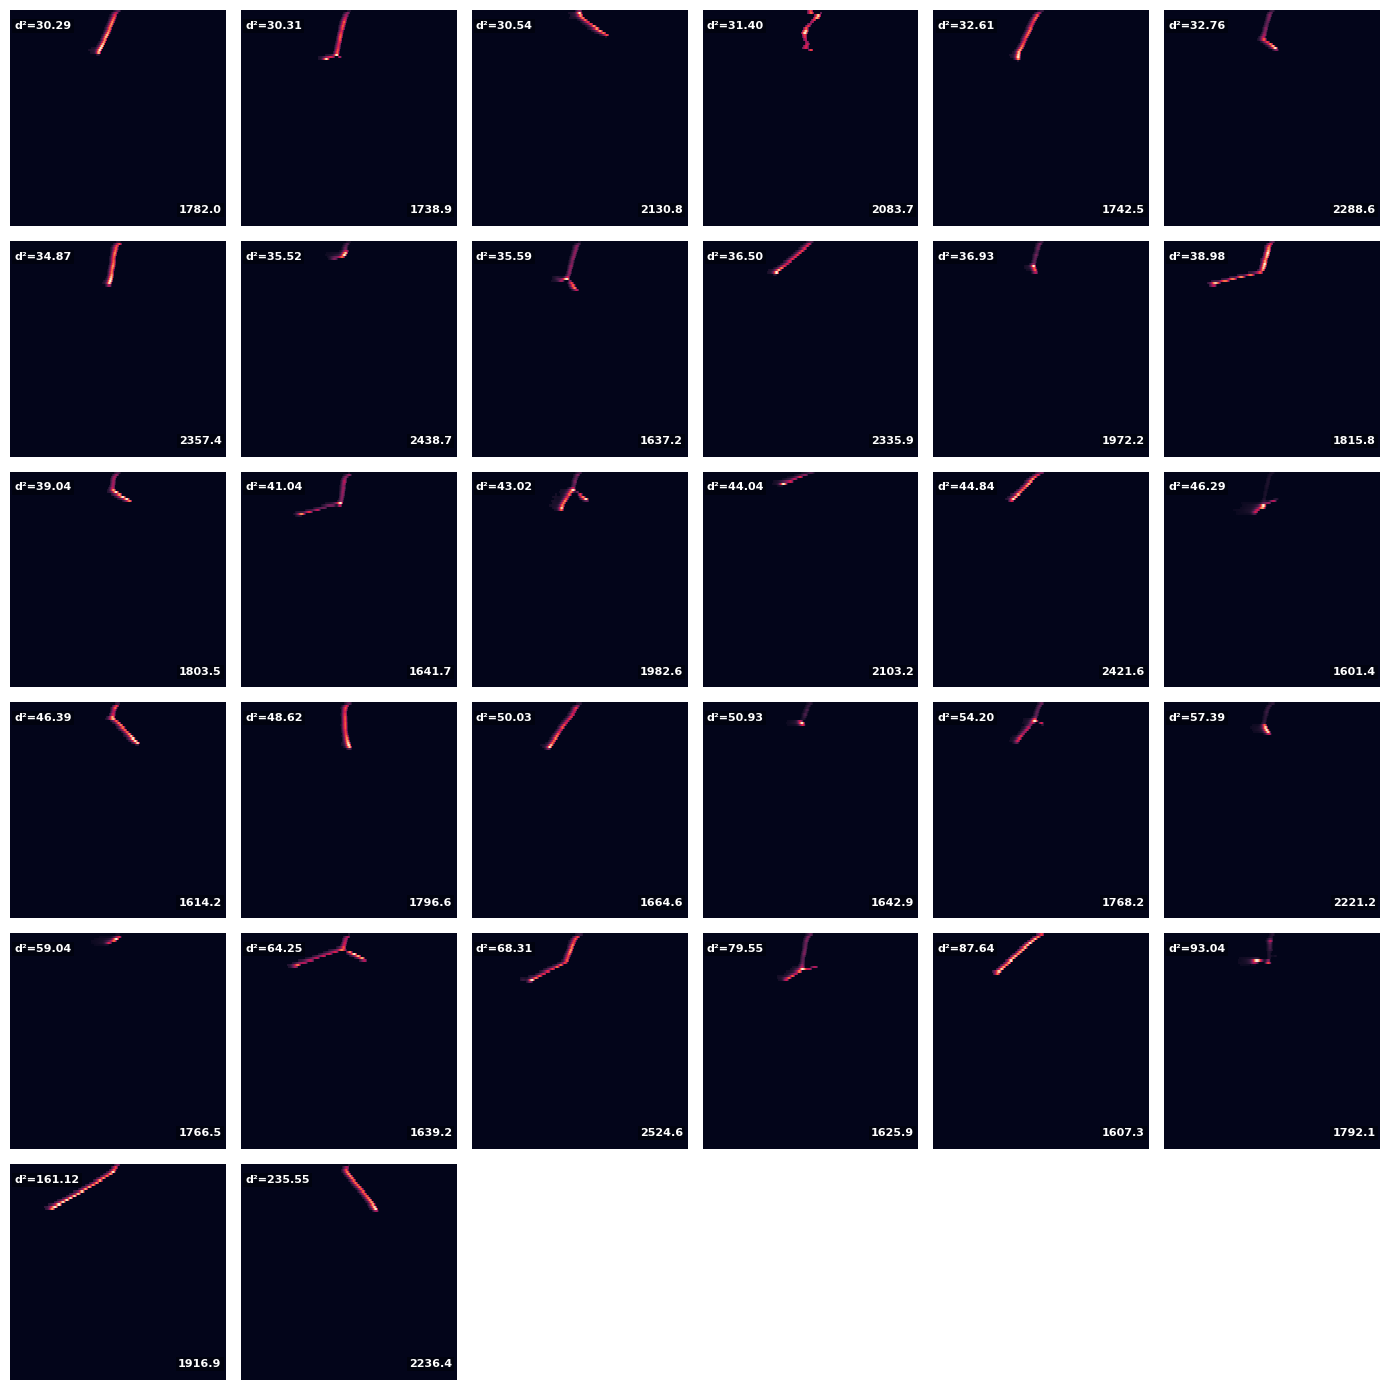

In [101]:
# --- Parameters ---
num_images = 32
grid_size = int(np.ceil(np.sqrt(num_images)))

# Identify which query entries are references (exact or near match)
def find_reference_indices(refs, queries, tol=1e-8):
    ref_set = set()
    for i, q in enumerate(queries):
        if np.any(np.all(np.isclose(refs, q[None, :], atol=tol), axis=1)):
            ref_set.add(i)
    return np.array(sorted(ref_set))

ref_indices_in_queries = find_reference_indices(l, latent_vectors_d)
print(f"{len(ref_indices_in_queries)} reference vectors detected inside queries.")

# --- Exclude refs from sorting ---
valid_mask = np.ones(len(latent_vectors_d), dtype=bool)
valid_mask[ref_indices_in_queries] = False

valid_indices = np.where(valid_mask)[0]
valid_d2 = best_d2[valid_indices]
valid_p = p_values[valid_indices]
valid_images = deutimages[valid_indices]

# --- Sort remaining (non-reference) samples by Mahalanobis distance ---
idx_sorted = np.argsort(valid_d2)
normal_idxs = valid_indices[idx_sorted[:num_images]]
anomalous_idxs = valid_indices[idx_sorted[-num_images:]]

print("Lowest Mahalanobis (non-ref):", normal_idxs)
print("Highest Mahalanobis (non-ref):", anomalous_idxs)


def plot_mahalanobis_examples(indices, title):
    """
    Plot decoded LArTPC images for given indices, annotated with Mahalanobis stats and candidate mass.
    """
    selected_images = deutimages[indices]
    selected_d2 = best_d2[indices]
    selected_p = p_values[indices]
    selected_m = d_m[indices]   # <-- include mass

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(14, 14))

    for i in range(grid_size * grid_size):
        ax = axes[i // grid_size, i % grid_size]
        if i < len(selected_images):
            sns.heatmap(selected_images[i, 1], ax=ax, cbar=False,
                        xticklabels=False, yticklabels=False)

            # --- Top-left: Mahalanobis distance ---
            ax.text(0.02, 0.95, f"d²={selected_d2[i]:.2f}",
                    transform=ax.transAxes,
                    fontsize=8, color='white', ha='left', va='top',
                    fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1.5))

            # --- Bottom-left: p-value ---
            # ax.text(0.02, 0.05, f"p={selected_p[i]:.3f}",
            #         transform=ax.transAxes,
            #         fontsize=8, color='white', ha='left', va='bottom',
            #         fontweight='bold',
            #         bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1.5))

            # --- Bottom-right: candidate mass ---
            ax.text(0.98, 0.05, f"{selected_m[i]:.1f}",
                    transform=ax.transAxes,
                    fontsize=8, color='white', ha='right', va='bottom',
                    fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1.5))

        else:
            ax.axis('off')

    # fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    # plt.savefig('noise.png', dpi=1000)
    plt.show()


# --- Plot closest and most anomalous events ---
plot_mahalanobis_examples(normal_idxs, "Closest (non-reference) samples – low Mahalanobis distance")
plot_mahalanobis_examples(anomalous_idxs, "Most anomalous (non-reference) samples – high Mahalanobis distance")


33 reference vectors detected inside queries.
Randomly selected indices with d² in range [0.0, 3.0]: [ 875   20  145  521  621  101  859  463  210  592  803   49  510  633
 1005  951  650  347  781  379  723  801  106  777]


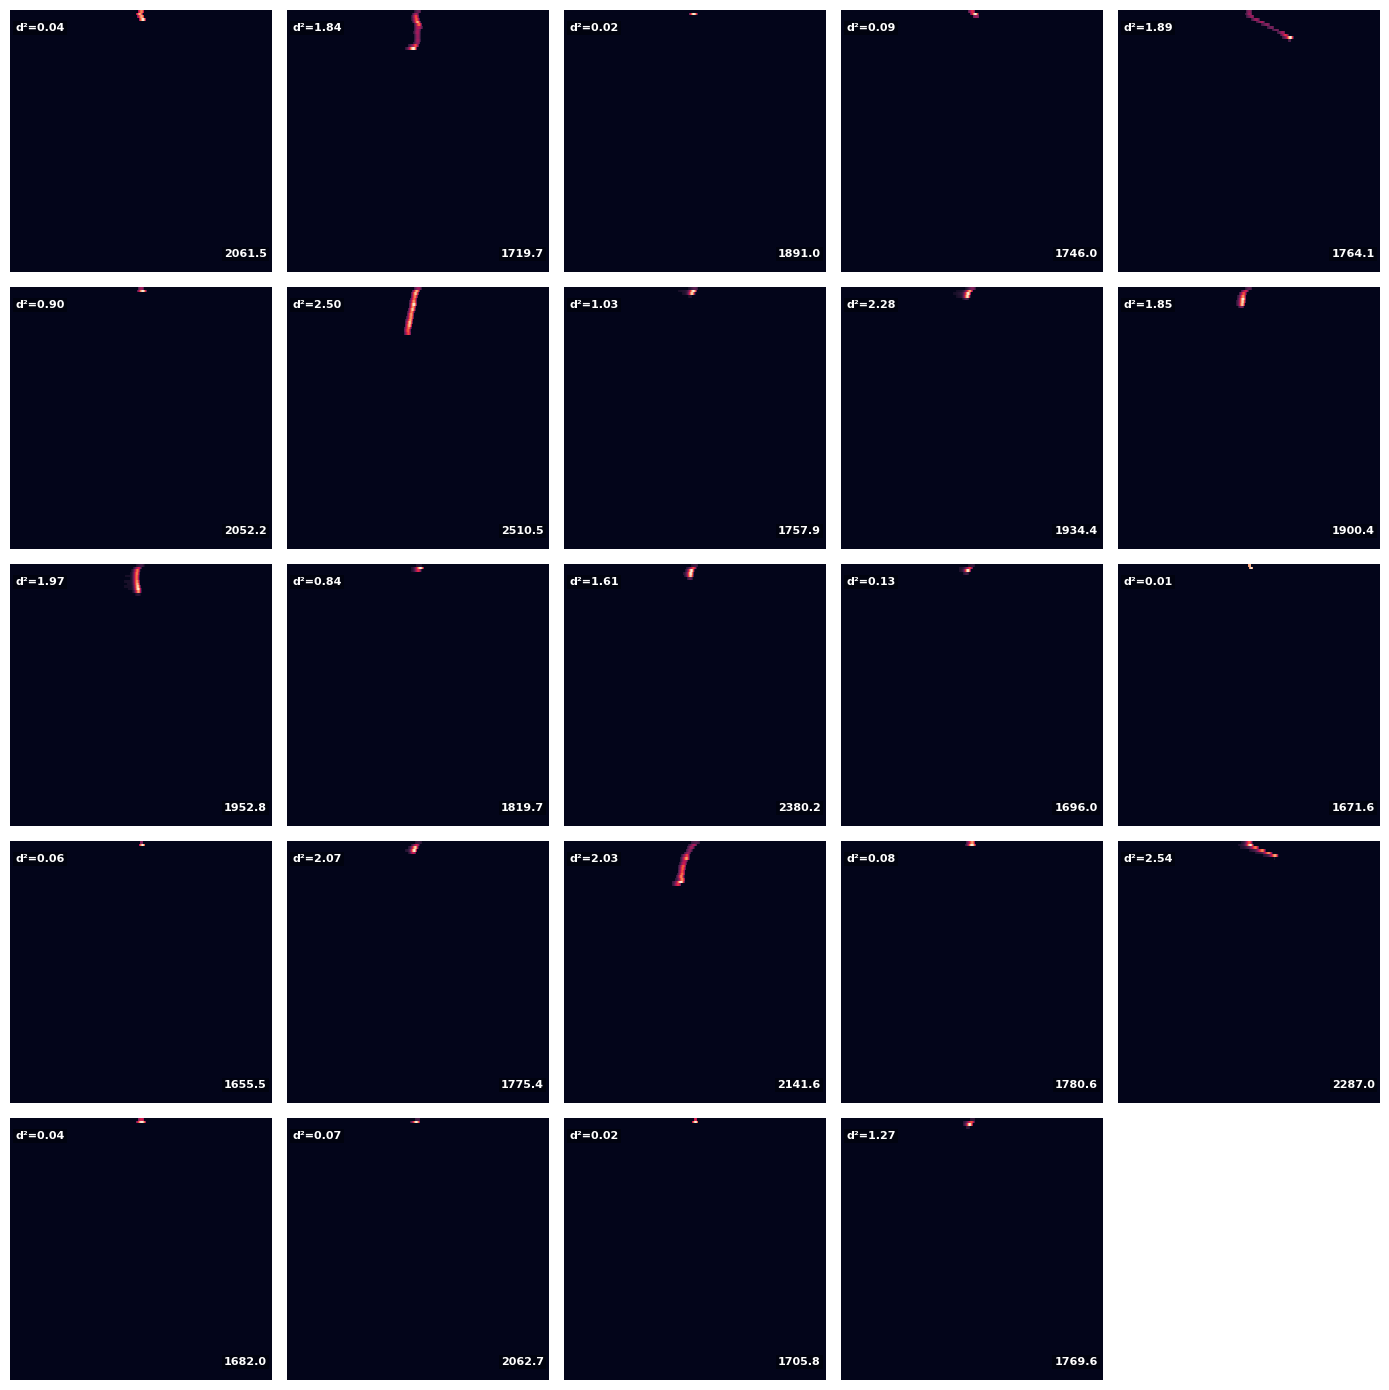

In [102]:
# --- Parameters ---
num_images = 24
grid_size = int(np.ceil(np.sqrt(num_images)))

# Identify which query entries are references (exact or near match)
def find_reference_indices(refs, queries, tol=1e-8):
    ref_set = set()
    for i, q in enumerate(queries):
        if np.any(np.all(np.isclose(refs, q[None, :], atol=tol), axis=1)):
            ref_set.add(i)
    return np.array(sorted(ref_set))

ref_indices_in_queries = find_reference_indices(l, latent_vectors_d)
print(f"{len(ref_indices_in_queries)} reference vectors detected inside queries.")

# --- Exclude refs from sorting ---
valid_mask = np.ones(len(latent_vectors_d), dtype=bool)
valid_mask[ref_indices_in_queries] = False

valid_indices = np.where(valid_mask)[0]
valid_d2 = best_d2[valid_indices]
valid_p = p_values[valid_indices]
valid_images = deutimages[valid_indices]

# --- Filter by Mahalanobis distance range ---
def filter_by_d2_range(d2_values, indices, d2_min=None, d2_max=None):
    """
    Filter indices based on a range of Mahalanobis distances.
    """
    mask = np.ones(len(d2_values), dtype=bool)
    if d2_min is not None:
        mask &= (d2_values >= d2_min)
    if d2_max is not None:
        mask &= (d2_values <= d2_max)
    return indices[mask]

# Example: Set your desired range for Mahalanobis distance
d2_min = 0.0  # Minimum d² value (inclusive)
d2_max = 3.0  # Maximum d² value (inclusive)

filtered_indices = filter_by_d2_range(valid_d2, valid_indices, d2_min, d2_max)
filtered_d2 = best_d2[filtered_indices]
filtered_p = p_values[filtered_indices]
filtered_images = deutimages[filtered_indices]

# --- Randomly select a subset of filtered samples ---
if len(filtered_indices) > num_images:
    selected_indices = np.random.choice(filtered_indices, size=num_images, replace=False)
else:
    selected_indices = filtered_indices

print(f"Randomly selected indices with d² in range [{d2_min}, {d2_max}]:", selected_indices)

def plot_mahalanobis_examples(indices, title):
    """
    Plot decoded LArTPC images for given indices, annotated with Mahalanobis stats and candidate mass.
    """
    selected_images = deutimages[indices]
    selected_d2 = best_d2[indices]
    selected_p = p_values[indices]
    selected_m = d_m[indices]   # <-- include mass

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(14, 14))

    for i in range(grid_size * grid_size):
        ax = axes[i // grid_size, i % grid_size]
        if i < len(selected_images):
            sns.heatmap(selected_images[i, 1], ax=ax, cbar=False,
                        xticklabels=False, yticklabels=False)

            # --- Top-left: Mahalanobis distance ---
            ax.text(0.02, 0.95, f"d²={selected_d2[i]:.2f}",
                    transform=ax.transAxes,
                    fontsize=8, color='white', ha='left', va='top',
                    fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1.5))

            # # --- Bottom-left: p-value ---
            # ax.text(0.02, 0.05, f"p={selected_p[i]:.3f}",
            #         transform=ax.transAxes,
            #         fontsize=8, color='white', ha='left', va='bottom',
            #         fontweight='bold',
            #         bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1.5))

            # --- Bottom-right: candidate mass ---
            ax.text(0.98, 0.05, f"{selected_m[i]:.1f}",
                    transform=ax.transAxes,
                    fontsize=8, color='white', ha='right', va='bottom',
                    fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.4, lw=0, pad=1.5))

        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# --- Plot randomly selected events ---
plot_mahalanobis_examples(selected_indices, f"Randomly selected samples with d² in range [{d2_min}, {d2_max}]")

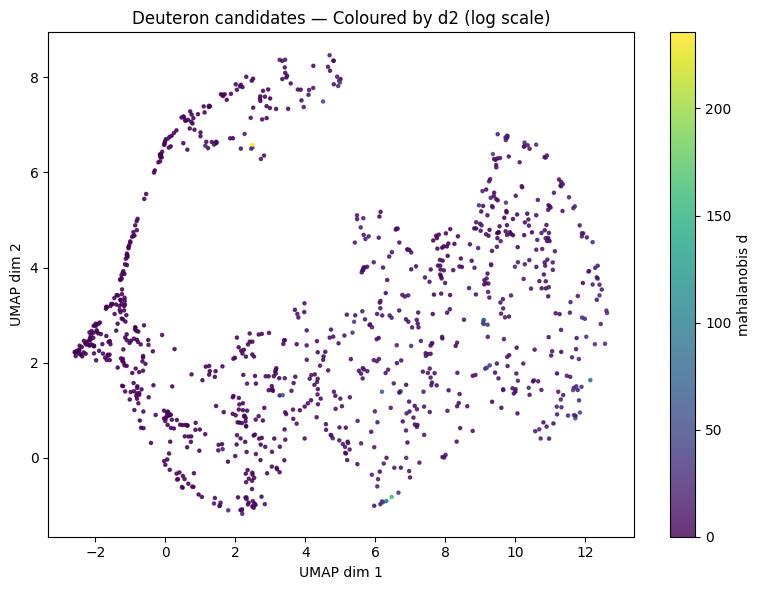

In [103]:
from matplotlib.colors import LogNorm

fig = plt.figure(figsize=(8, 6))

# Scatter plot coloured by cluster length on a log scale
sc = plt.scatter(
    E_d[:, 0], E_d[:, 1],
    c=best_d2, cmap='viridis',
    # norm=LogNorm(),  # <-- log scale
    s=5, alpha=0.8
)

# Add a colourbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("mahalanobis d")

plt.title("Deuteron candidates — Coloured by d2 (log scale)")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()


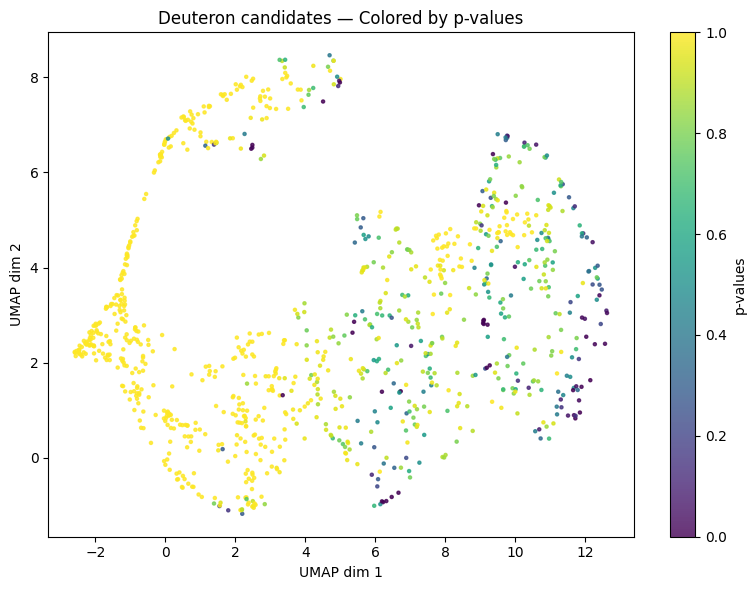

In [104]:
fig = plt.figure(figsize=(8, 6))

# Scatter plot colored by cluster length
sc = plt.scatter(E_d[:, 0], E_d[:, 1],
                 c=p_values, cmap='viridis', s=5, alpha=0.8)

# Add a colorbar to indicate cluster length
cbar = plt.colorbar(sc)
cbar.set_label("p-values")

plt.title("Deuteron candidates — Colored by p-values")
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
plt.show()

# COMPARING WITH SCORES FOR PROTONS

In [105]:
res_p = score_against_references(l, latent_vectors, cov_fit='all', also_cosine=True)

# Per-query best match (Mahalanobis)
nearest_ref_p = res_p["nearest_ref_index"]      # (2529,)
best_d2_p     = res_p["nearest_maha_d2"]        # squared distance
p_values_p    = res_p["nearest_p_value"]        # small p => unusual w.r.t. Σ

# Example: flag queries that are unlikely under the reference distribution
alpha = 0.01
anomalous_mask_p = p_values_p < alpha
anomalous_indices = np.where(anomalous_mask_p)[0]

# If you also want cosine-based nearest
nearest_ref_cos_p = res_p["nearest_ref_index_cos"]
best_cos_p        = res_p["nearest_cos_dist"]


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: overflow encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/linalg/_basic.py:1742: RuntimeWarning: invalid value encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_14403/746596412.py:21: RuntimeWarning: divide by zero encountered in matmul
  precision = (eigvecs @ np.diag(1.0 / eigvals) @ eigvecs.T)
/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_14403/746596412.py:21: RuntimeWarning: overflow encountered in matmul
  precision = (eigvecs @ np.diag(1.0 / eigvals) @ eigvecs.T)
/var/folders/cm/m55y72dj6cd5lkwrf

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/user/code/research/proton-deuteron/.

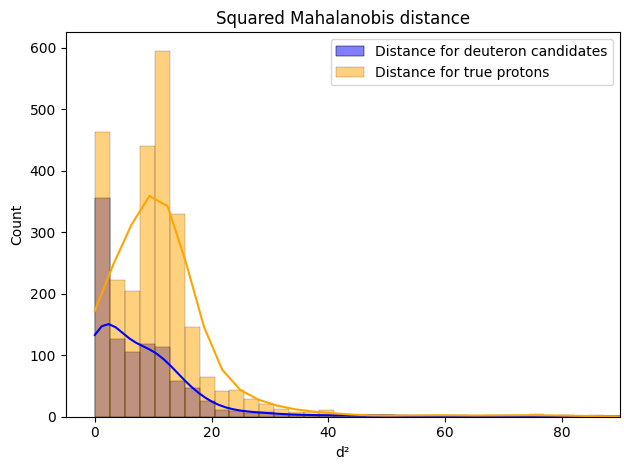

In [106]:
bins = np.linspace(0, 100, 40)
sns.histplot(best_d2, bins=bins, kde=True, color='blue', label='Distance for deuteron candidates')
sns.histplot(best_d2_p, bins=bins, kde=True, color='orange', label='Distance for true protons')
plt.title("Squared Mahalanobis distance")
plt.xlabel("d²")
plt.ylabel("Count")
plt.legend()
plt.xlim(-5, 90)

plt.tight_layout()
# plt.savefig('Mahal.png', dpi=1000)
plt.show()


In [107]:
x = np.where(best_d2_p < 2)
x

(array([  12,   20,   21,   30,   40,   52,   56,   58,   60,   62,   66,
          81,   93,  102,  103,  104,  113,  128,  135,  136,  139,  147,
         159,  164,  172,  185,  205,  208,  213,  251,  256,  276,  284,
         290,  309,  311,  322,  324,  340,  344,  357,  358,  363,  364,
         369,  374,  382,  383,  384,  389,  397,  409,  413,  427,  439,
         441,  443,  451,  455,  459,  478,  479,  480,  490,  494,  496,
         504,  508,  509,  510,  512,  516,  520,  525,  527,  535,  540,
         542,  543,  545,  547,  548,  554,  568,  569,  571,  579,  592,
         605,  613,  617,  619,  625,  638,  645,  660,  666,  676,  691,
         705,  709,  712,  715,  716,  727,  732,  743,  751,  769,  786,
         790,  795,  808,  817,  821,  838,  842,  845,  872,  878,  885,
         888,  901,  912,  925,  941,  944,  946,  949,  953,  954,  956,
         957,  959,  967,  968,  975,  988,  993, 1019, 1025, 1031, 1043,
        1049, 1053, 1066, 1071, 1076, 

In [108]:
n = np.unique(nearest_ref_p[x])
n

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32])

KeyboardInterrupt: 

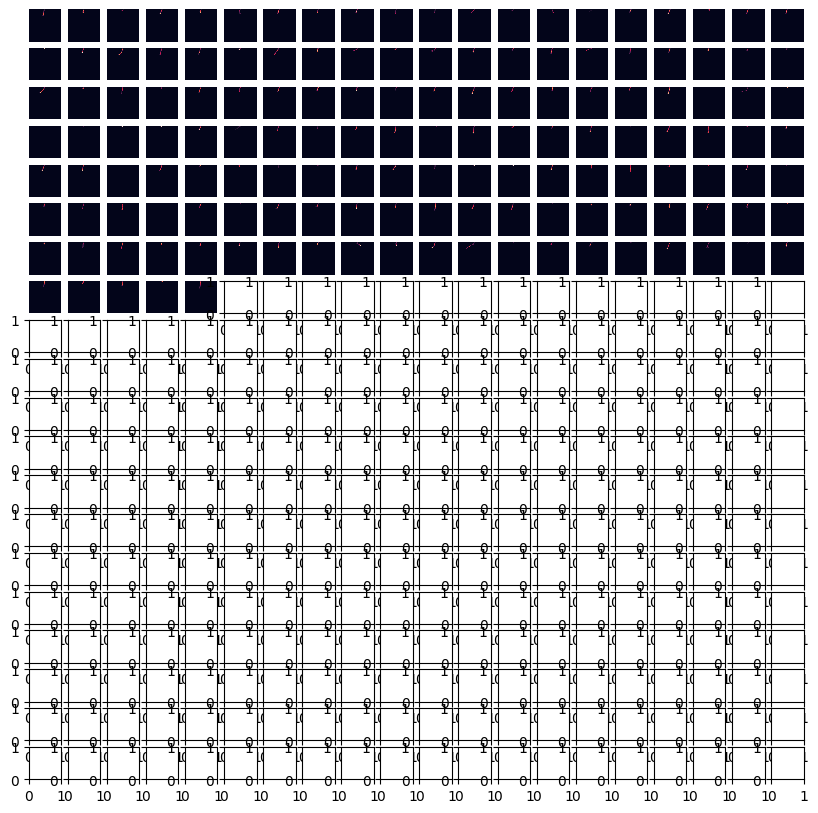

In [109]:
num_images = len(x[0])  
grid_size = int(np.ceil(np.sqrt(num_images)))

selected_images = protimages[x]

fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < len(selected_images):
        sns.heatmap(selected_images[i, 1], ax=ax, cbar=False, xticklabels=False, yticklabels=False)
    else:
        ax.axis('off')  # Turn off unused subplots

plt.tight_layout()
plt.show()

In [ ]:
best_d2.shape, d_m.shape

((2421,), (2421,))

(array([414., 136., 143., 108., 100., 103., 106.,  77.,  61.,  63.,  62.,
         50.,  62.,  52.,  43.,  43.,  55.,  46.,  34.,  35.,  30.,  44.,
         38.,  37.,  30.,  36.,  32.,  34.,  32.,  22.,  24.,  15.,  15.,
         15.,  13.,  17.,  18.,  14.,  13.,   9.,  10.,  13.,   9.,   7.,
         11.,   7.,   7.,   4.,   4.,  10.,   3.,   6.,   2.,   3.,   4.,
          2.,   6.,   1.,   4.,   1.,   3.,   1.,   3.,   1.,   1.,   3.,
          0.,   1.,   0.,   0.,   1.,   2.,   2.,   0.,   0.,   0.,   0.,
          1.,   1.,   0.,   0.,   2.,   0.,   0.,   0.,   1.,   0.,   0.,
          1.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([ 0.        ,  0.86952621,  1.73905241,  2.60857868,  3.47810483,
         4.34763098,  5.21715736,  6.08668327,  6.95620966,  7.82573605,
         8.69526196,  9.56478786, 10.43431473, 11.30384064, 12.17336655,
        13.04289341, 13.91241932, 14.78194523, 15.65147209, 16.520998  ,
        17.39052391, 18.26

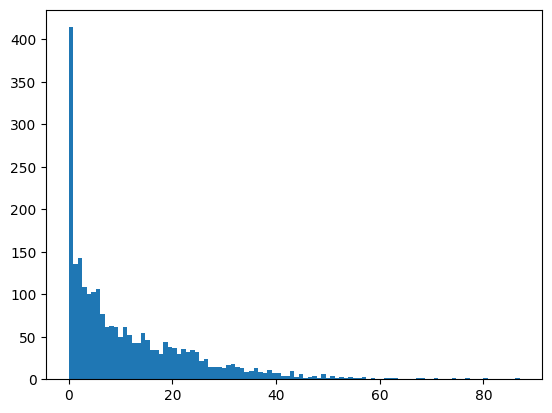

In [ ]:
plt.hist(best_d2, bins=100)

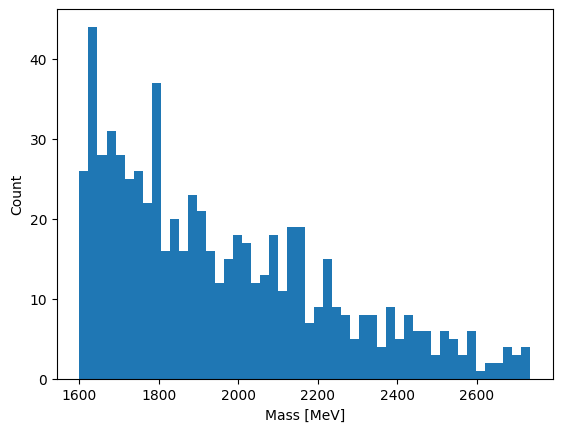

In [ ]:
i = np.where(best_d2 < 2.5)[0]
plt.hist(d_m[i], bins=50)
plt.xlabel('Mass [MeV]')
plt.ylabel('Count')
plt.show()

In [ ]:
deuteron_clusters = col[col['particle_type'] == 'deuteron']

In [ ]:
deuteron_clusters

,run,subrun,event,cluster_idx_ind,cluster_idx_col,d_min_c,d_max_c,d_min_r,d_max_r,d_h,...,aspect_ratio,compactness,image_intensity,matrix_transformed,column_maxes,p,m,beamline_mass,maxdiff,thetas
0,8557,4,473,0,0,41,68,12,15,3,...,20.750000,0.463102,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, -0.0, -0.0, 0.0, -0.0, -0.0, 16.0, 0.0]...","[23.0, 158.0, 295.0, 410.0, 353.0, 403.0, 411....",0,1,2734.40,0.333333,-85.683972
18,8557,90,4333,0,0,30,65,-4,0,4,...,5.384615,0.236745,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0....","[22.0, 78.0, 104.0, 175.0, 171.0, 156.0, 168.0...",0,1,1738.95,0.138132,77.471192
21,8557,97,4665,0,1,27,76,16,13,-3,...,4.000000,0.182253,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[16.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0...","[192.0, 162.0, 150.0, 158.0, 187.0, 204.0, 178...",0,1,2062.70,0.231203,71.754145
30,8557,128,5986,4,4,35,77,-8,-7,1,...,17.000000,0.474265,"[[0.0, 0.0, 0.0, -0.0, 0.0, -0.0, -0.0, -0.0, ...","[[16.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0....","[70.0, 164.0, 254.0, 315.0, 351.0, 443.0, 486....",0,0,1656.84,0.193416,84.359451
31,8557,128,6010,0,0,14,47,-7,-7,0,...,3.214286,0.325298,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0...","[42.0, 97.0, 106.0, 96.0, 133.0, 109.0, 108.0,...",0,1,2146.39,0.375000,68.338849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9184,9788,258,22697,2,0,14,73,-6,-6,0,...,2.662791,0.232863,"[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0...","[[16.0, 0.0, -0.0, -0.0, -0.0, 0.0, 0.0, 0.0, ...","[69.0, 107.0, 69.0, 83.0, 74.0, 73.0, 71.0, 74...",0,0,2118.56,0.465649,60.819194
9185,9788,266,23333,0,0,18,71,-3,-2,1,...,18.500000,0.563063,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, -0.0, -0.0, 0.0, -0.0, 0.0], [17.0, -0...","[78.0, 139.0, 191.0, 259.0, 223.0, 21.0]",0,0,2031.27,0.262548,82.405357
9187,9788,268,23513,5,0,11,105,-7,-11,-4,...,4.333333,0.163097,"[[0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0....","[[16.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0...","[54.0, 83.0, 117.0, 77.0, 107.0, 67.0, 73.0, 8...",0,0,1787.56,0.157143,71.131001
9192,9788,299,26200,0,1,10,59,0,-1,-1,...,3.791667,0.628205,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[16.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0...","[33.0, 121.0, 142.0, 126.0, 123.0, 148.0, 135....",0,0,1675.37,0.293333,57.724356


In [ ]:
counts = deuteron_clusters[['run', 'subrun', 'event']].value_counts().reset_index(name='frequency')

In [ ]:
counts = pd.merge(
    counts, 
    deuteron_clusters[['run', 'subrun', 'event', 'beamline_mass']],
    how='left',
    on=['run', 'subrun', 'event']
)

In [ ]:
counts

,run,subrun,event,frequency,beamline_mass
0,9509,245,23164,2,2705.48
1,9509,245,23164,2,2705.48
2,9488,137,11142,2,1636.41
3,9488,137,11142,2,1636.41
4,8684,246,26676,2,1639.39
...,...,...,...,...,...
2416,8689,123,11219,1,2191.90
2417,8689,147,13479,1,2575.43
2418,8689,151,13856,1,1906.81
2419,8689,184,17024,1,1808.71


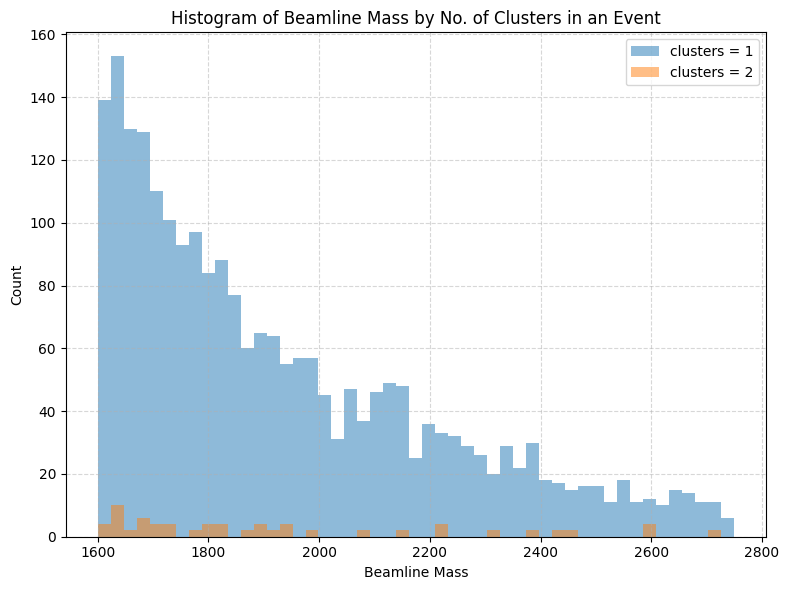

In [ ]:
bins = np.linspace(1600, 2750, 50)

frequencies = sorted(counts['frequency'].unique())

plt.figure(figsize=(8, 6))

for freq in frequencies:
    subset = counts[counts['frequency'] == freq]
    plt.hist(subset['beamline_mass'], bins=bins, alpha=0.5, label=f'clusters = {freq}')

plt.xlabel('Beamline Mass')
plt.ylabel('Count')
plt.title('Histogram of Beamline Mass by No. of Clusters in an Event')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


<Axes: >

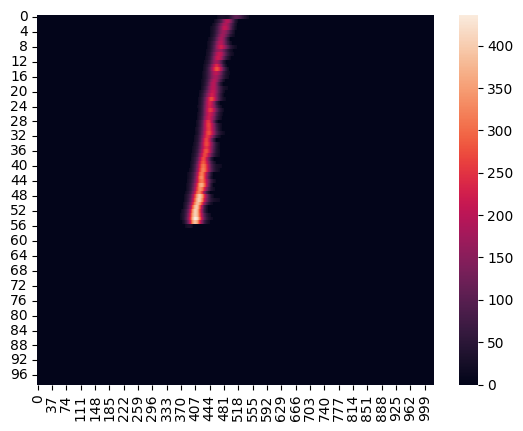

In [ ]:
sns.heatmap(protimages[0][0])